In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
from dna_features_viewer import GraphicFeature, GraphicRecord

from scripts.variant_selection_utils import *

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')
df_trust_patients['Paired_Sample_Num'] = df_trust_patients.sort_values(['pid', 'Sampling_Week']).groupby('pid')['SampleID'].cumcount() + 1

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

mixed_samples = df_trust_patients.query("F2 > 0.03").SampleID.unique()

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

SNP_dist_matrix = pd.read_csv("~/MtbLongitudinalDiversity/data/TRUST_TOTAL.SNP.distance.matrix.V3.csv", header=None, names=['Sample1', 'Sample2', 'Dist'])

rrs
rrl
rrf


In [24]:
df_trust_patients.pid.nunique()

424

In [36]:
df_trust_patients_all = pd.read_csv("~/TRUST_data_processing/raw_data/TRUST_DATA_2025-05-12_1129.cleaned.wide.csv")
len(df_trust_patients_all), df_trust_patients_all.pid.nunique()

(458, 458)

In [37]:
df_trust_patients_all['screen_date'].min(), df_trust_patients_all['screen_date'].max()

('2017-05-16', '2024-03-19')

In [32]:
df_trust_patients['screen_date'].min(), df_trust_patients['screen_date'].max()

('2017-05-16', '2024-03-19')

# Read in Low AF SNPs: Filtered, then predicted to be Real or Not by a Linear Mixed Model

In [2]:
df_baseline_samples = df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
print(f"{df_baseline_samples.pid.nunique()} pids with baseline samples with F2 ≤ {F2_max}")

395 pids with baseline samples with F2 ≤ 0.03


In [3]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids with longitudinal sequencing")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

325 pids with longitudinal sequencing
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.483076923076923


In [4]:
df_trust_patients.query("Sampling_Week <= 2").pid.nunique(), df_trust_patients.query("F2 <= @F2_max & Sampling_Week <= 2").pid.nunique()

(418, 395)

In [5]:
# samples_lst = os.listdir(H37Rv_ref_dir)

# for sample in df_baseline_samples.SampleID.values:
#     if sample not in samples_lst:
#         print(sample)

In [6]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{os.path.dirname(model_dir)}/fixed_variants.csv.gz", compression='gzip')
    
    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # keep all unfixed variants outside of the positional bounds in the training set
    # This is because the circular genome has been linearized for variant calling, so there are lots of discordantly paired reads at the ends
    # but they're not real. If the genome had been circular during alignment, they wouldn't be discordant. So these positions are usually real unfixed SNVs
    df_val_variants.loc[(df_val_variants['POS'] < first_pos) | df_val_variants['POS'] > last_pos, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0").POS.values

        if len(false_lowAF_variant_sites) > 0:
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites)")
            
    # keep only those predicted to be real
    df_val_variants = df_val_variants.query("pred_class == 1")

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    problem_sites = df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").POS.unique()
    print(f"Excluded positions: {problem_sites}")
    print(df_val_variants.query("False_in_all_Ground_Truth_Samples==1 & pred_class==1").GENE.value_counts())
    
    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    
    # combine train and validation. For validation, keep only those where False_in_all_Ground_Truth_Samples = 0
    df_variants = pd.concat([df_train_variants, df_val_variants.query("False_in_all_Ground_Truth_Samples==0")]).reset_index(drop=True)
            
    # combine fixed and unfixed
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Sampling_Week']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Intergenic'
    df_variants.loc[(df_variants['Region'].str.contains('NC')) & (~df_variants['GENE'].str.contains('-')), 'Variant_Type'] = 'Noncoding'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # fake variants that pass through the Elastic Net model. Just exclude them manually. They're all caused by proximity to an indel.
    # the SNVs are found at the very edge of reads. Not sure why they are not predicted False
    # df_variants = df_variants.query("POS not in [3501679, 3501681]")
    
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [7]:
# # model_dir = "./variantDetector/unmixed_only/penalty_elasticnet"
# model_dir = "./variantDetector/unmixed_only/penalty_none"

# df_variants, df_lowAF_variants = read_in_process_variants(model_dir, df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"))

# df_variants = df_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants = df_lowAF_variants.merge(df_longitudinal_pids[['SampleID', 'Paired_Sample_Num']])

# df_variants[['GENE1', 'GENE2']] = df_variants['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
# os.makedirs(output_dir, exist_ok=True)
# df_variants.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants), len(df_lowAF_variants)

Excluded positions: [  33207 2873110 1753519]
GENE
Rv2553c          4
Rv0029-Rv0030    3
fadD11.1         1
Name: count, dtype: int64


(562582, 1210)

In [8]:
# df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants(model_dir, df_baseline_samples)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_baseline.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_baseline.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# len(df_variants_baseline), len(df_lowAF_variants_baseline)

Excluded positions: [  33207 2873110 1753519]
GENE
Rv2553c          4
Rv0029-Rv0030    3
fadD11.1         1
Name: count, dtype: int64


(388522, 781)

In [9]:
# df_variants_full, df_lowAF_variants_full = read_in_process_variants(model_dir, df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max"))

# df_variants_full = df_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])
# df_lowAF_variants_full = df_lowAF_variants_full.merge(df_trust_patients[['SampleID', 'Paired_Sample_Num']])

# df_lowAF_variants_full[['GENE1', 'GENE2']] = df_lowAF_variants_full['GENE'].str.split('-', expand=True)

# output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/full"
# os.makedirs(output_dir, exist_ok=True)
# df_variants_full.to_csv(f"{output_dir}/variants.csv", index=False)
# df_lowAF_variants_full.to_csv(f"{output_dir}/lowAF_variants.csv", index=False)

# print(len(df_lowAF_variants_full))

Excluded positions: [  33207 2873110 1753519]
GENE
Rv2553c          4
Rv0029-Rv0030    3
fadD11.1         1
Name: count, dtype: int64
1600


In [20]:
output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/longitudinal"
df_variants = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
df_variants_baseline = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_baseline = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

output_dir = "/home/sak0914/MtbLongitudinalDiversity/data/baseline"
df_variants_full = pd.read_csv(f"{output_dir}/variants.csv")
df_lowAF_variants_full = pd.read_csv(f"{output_dir}/lowAF_variants.csv")

In [9]:
# df_coding = df_lowAF_variants_full_for_enrichment_test.query("~Region.str.contains('NC')")

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'NonSyn'] = 0
# df_coding['NonSyn'] = df_coding['NonSyn'].fillna(1).astype(int)

# df_coding.loc[df_coding['Variant_Type']=='Silent', 'Syn'] = 1
# df_coding['Syn'] = df_coding['Syn'].fillna(0).astype(int)

# df_dN_dS = pd.DataFrame(df_coding.groupby('Region')[['NonSyn', 'Syn']].sum()).reset_index()
# df_dN_dS['dN_dS'] = df_dN_dS['NonSyn'] / df_dN_dS['Syn']

# df_coding = df_coding.merge(df_dN_dS, on='Region', how='left')

In [11]:
# df_samples_save = df_trust_patients.dropna(subset='Lineage').query("F2 <= @F2_max").query("Sampling_Week <= 12").sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')[['pid', 'SampleID', 'Lineage', 'Coll2014']]

# df_samples_save = pd.concat([df_trust_patients.query("SampleID in @df_lowAF_variants_full_for_enrichment_test.SampleID & SampleID not in @df_samples_save.SampleID")[['pid', 'SampleID', 'Lineage', 'Coll2014']]
#                              df_samples_save
#                             ]).reset_index(drop=True)

# df_samples_save['Lineage'] = df_samples_save['Lineage'].astype(int)

# print(df_samples_save.Lineage.unique())

# out_dir = "/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_for_enrichment"
# print(len(df_samples_save))

# os.makedirs(out_dir, exist_ok=True)
# df_samples_save.to_csv(f"{out_dir}/samples.csv", header=None, index=False)

In [49]:
# pilon_VCF = []

# for sample in df_samples_save.SampleID.values:
    
#     fName = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf"
#     assert os.path.isfile(fName)
#     pilon_VCF.append(fName)
    
# pd.Series(pilon_VCF).to_csv(f"{out_dir}/pilon_VCFs.txt", header=None, index=False, sep='\t')

In [21]:
df_lowAF_variants_full_for_enrichment_test.drop_duplicates(subset=['pid', 'POS', 'REF', 'ALT']).Lineage.value_counts()

NameError: name 'df_lowAF_variants_full_for_enrichment_test' is not defined

In [17]:
df_lowAF_variants_full_for_enrichment_test.pid.nunique(), df_lowAF_variants_full_for_enrichment_test.SampleID.nunique()

(335, 335)

In [18]:
len(df_lowAF_variants_full_for_enrichment_test.query("Variant_Type != 'Silent'"))

751

In [20]:
df_lowAF_variants_full_for_enrichment_test.Sampling_Week.value_counts()

Sampling_Week
1     746
6      63
8      38
2      37
7      33
4      27
5      20
9       9
3       5
11      3
Name: count, dtype: int64

# Read in Unfixed Indels

In [10]:
AF_min = 0.05
AF_max = 0.95

df_indels = pd.concat([pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min"),
                     pd.read_csv("variantDetector/fixed_indels.csv").query("AF >= @AF_min")
                    ]).drop_duplicates(subset=['SampleID', 'POS'])

df_indels['AF_Adj'] = df_indels['AF_Adj'].fillna(df_indels['AF'])
del df_indels['AF']
df_indels.rename(columns={'AF_Adj': 'AF'}, inplace=True)

df_indels['Indel'] = df_indels['POS'].astype(str) + '_' + df_indels['REF'] + '_' + df_indels['ALT']

df_indels = df_indels.merge(df_trust_patients[['SampleID', 'Sampling_Week', 'Paired_Sample_Num']])

df_unfixed_indels = pd.read_csv("variantDetector/unfixed_indels.csv").query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")
print(len(df_unfixed_indels.query("AF > @AF_max")))

# then if there are any where the original AF is greater than 0.95, exclude those. Those are weird alignments where the revised AF_Adj is lower and not accurate. SR problems
# examples: 2881582 and 2881597 in MFS-310 and MFS-311
# liftoff doesn't transfer over the region well. Two homopolymeric tracts in close proximity. Maybe problematic overall. Don't consider these as unfixed indels
df_unfixed_indels = df_unfixed_indels.query("AF <= @AF_max")

# don't double count indels at the same site. This occurs if the site is more than bi-allelic. But want to consider it a single unfixed indel
df_unfixed_indels = df_unfixed_indels.drop_duplicates(subset=['SampleID', 'POS']).reset_index(drop=True)

print(len(df_unfixed_indels))

df_unfixed_indels = df_unfixed_indels.merge(df_trust_patients[['SampleID', 'Coll2014', 'F2', 'Lineage', 'Sampling_Week', 'Paired_Sample_Num']])
df_unfixed_indels['Region'] = df_unfixed_indels['POS'].map(h37Rv_coords_dict)
df_unfixed_indels['Lineage'] = df_unfixed_indels['Lineage'].astype(int)

df_indels['Region'] = df_indels['POS'].map(h37Rv_coords_dict)

0
258


In [11]:
HT_len = 7
HT_regions = pd.read_csv("~/MtbLongitudinalDiversity/data/nucleotide_runs_all_lengths.csv").query("Length >= @HT_len")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    # subtract 1 from start because many indels will be listd at the previous position and ins something
    HT_pos += list(np.arange(row['POS'] - 1, row['POS'] + row['Length']))

if 'HT_Region' in df_indels.columns:
    del df_indels['HT_Region']
    
if 'phase_variant' in df_indels.columns:
    del df_indels['phase_variant']
    
df_indels['HT_Region'] = df_indels['POS'].isin(HT_pos).astype(int)

# the HT pos could be one after the insertion because the insertion site will be right before it
df_indels.loc[(df_indels['REF'].str.len() < df_indels['ALT'].str.len()) & (df_indels['POS'].isin(np.array(HT_pos) - 1)), 'HT_Region'] = 1

df_indels = df_indels.reset_index(drop=True)

for i, row in df_indels.query("HT_Region==1").iterrows():
    
    if len(row['REF']) > len(row['ALT']):
        diff_nucs = row['REF'][1:]
    else:
        diff_nucs = row['ALT'][1:]
        
    # print(row['REF'], row['ALT'], diff_nucs)
                
    if len(np.unique(list(diff_nucs))) == 1:
        df_indels.loc[i, 'phase_variant'] = 1
 
df_indels['phase_variant'] = df_indels['phase_variant'].fillna(0).astype(int)

assert len(df_indels.query("HT_Region==0 & phase_variant==1")) == 0

assert sum(pd.isnull(df_indels['HT_Region'])) == 0
assert sum(pd.isnull(df_indels['phase_variant'])) == 0

Min HT length: 7
Max HT length: 9


In [12]:
df_indels.query("AF >= 0.05 & AF <= 0.95").phase_variant.value_counts()

phase_variant
0    230
1     28
Name: count, dtype: int64

In [13]:
df_indels.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1").Region.value_counts()

Region
NC_597       11
Rv1190        6
NC_2971       2
PE_PGRS14     1
glpK          1
Rv0954        1
espK          1
mce2D         1
NC_1549       1
aspB          1
frdB          1
Rv1894c       1
Name: count, dtype: int64

In [301]:
df_trust_patients.query("pid=='T0020'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week,Paired_Sample_Num
83,T0020,S0020-05,MFS-718,MFS-718_lib72881,NaN,NaN,1.0,320.76,1.0,0.9865,...,2.0,0.010731,3.1.1,3.1.1.i1,3.0,0.35,316.0,99.132025,5,2
84,T0020,S0020-01,MFS-523,MFS-523_lib64075,NaN,NaN,1.0,274.57,1.0,0.9890,...,2.0,0.011871,3.1.1,3.1.1.i1,3.0,0.51,269.0,99.076919,1,1


In [305]:
df_indels.query("AF >= 0.05 & AF <= 0.95 & phase_variant==1 & Region=='phoT'")

,POS,REF,ALT,AO,DP,Indel_Support,Total_Reads,AF,SampleID,pid,REF_len,ALT_len,Indel,Sampling_Week,Paired_Sample_Num,Region,HT_Region,phase_variant
36050,913175,T,TG,18,275,16.0,235.0,0.068085,MFS-454,T0366,1.0,2.0,913175_T_TG,1,1,phoT,1,1
36584,913175,TG,T,131,238,119.0,204.0,0.583333,MFS-389,T0324,2.0,1.0,913175_TG_T,7,2,phoT,1,1
48289,913175,T,TG,160,264,168.0,257.0,0.653696,MFS-162,T0249,1.0,2.0,913175_T_TG,1,1,phoT,1,1


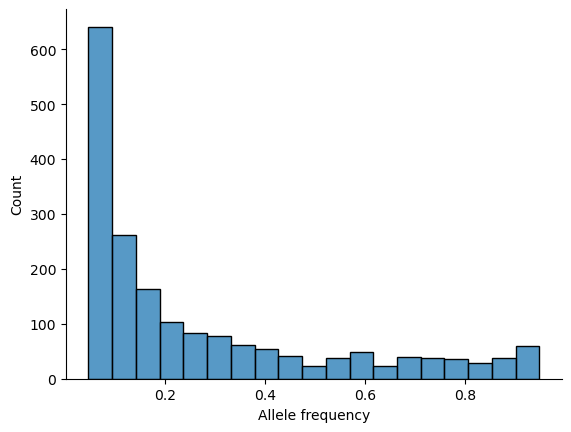

In [21]:
df_SFS = pd.concat([df_lowAF_variants_full, df_unfixed_indels])

# check that there aren't indels and SNVs at the same site. That would be a bioinformatics problem
assert len(df_SFS.drop_duplicates(subset=['SampleID', 'POS'], keep='first')) == len(df_SFS)

sns.histplot(data=df_SFS,
             x='AF'
            )

plt.xlabel('Allele frequency')
sns.despine()
plt.savefig("../results/figures/SFS_indels_SNVs.svg", bbox_inches='tight')

In [22]:
df_SFS.pid.nunique(), df_SFS.SampleID.nunique()

(352, 543)

In [23]:
df_SFS.AF.mean()

0.2689544409056262

In [24]:
df_combined_counts = pd.DataFrame(pd.DataFrame(df_SFS.groupby('SampleID')['POS'].count())).reset_index()

df_combined_counts = pd.concat([df_combined_counts,
                                pd.DataFrame({'SampleID': list(set(df_trust_patients.query("F2 <= @F2_max").SampleID) - set(df_combined_counts.SampleID)),
                                              'POS': 0
                                             })
                               ])

df_combined_counts = df_combined_counts.merge(df_trust_patients[['SampleID', 'Lineage']])
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

In [ ]:
def exponential_LRT(df, test_var, group_var='Lineage', min_count=5):
    
    # only keep groups with at least min_count observations
    keep_groups = pd.DataFrame(df.groupby(group_var)[test_var].count()).query(f"{test_var} >= @min_count").index.values
    
    df = df.query(f"{group_var} in @keep_groups")
        
    # Null model: single lambda
    lambda_null = 1 / df[test_var].mean()
    ll_null = np.sum(np.log(lambda_null) - lambda_null * df[test_var])
    
    params_dict = {'Full': lambda_null}

    # Full model: separate lambda per group
    ll_full = 0
    for g, group_df in df.groupby(group_var):
        lambda_g = 1 / group_df[test_var].mean()
        print(f"λ for lineage {g} = {lambda_g}")
        ll_full += np.sum(np.log(lambda_g) - lambda_g * group_df[test_var])
        params_dict[g] = lambda_g

    # Likelihood ratio test
    LR = 2 * (ll_full - ll_null)
    p_value = st.chi2.sf(LR, df=df[group_var].nunique() - 1)
    
    print(f"λ for full = {lambda_null}")

    print(f"\nLikelihood ratio test statistic: {LR:.3f}")
    print(f"P-value: {p_value:.4g}")
    
    return params_dict

In [ ]:
def exponential_distribution(lambda_param, x_min, x_max):
    
    x_vals = np.linspace(x_min, x_max, 100)
    
    return  x_vals, st.expon.pdf(x_vals, scale=1/lambda_param)#[lambda_param * np.exp(-lambda_param * x) for x in x_vals]

# Are unfixed SNVs enriched in certain genes?

In [36]:
# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     assert (row['End'] - row['Start'] + 1) % 3 == 0

In [131]:
def process_unfixed_variants_for_enrichment_test(df_variants):
    '''
    To avoid biases in the enrichment test, we need to do things:
    
    1. For variants that occur in multiple genes (because the coding sequences are overlapping, like Rv3861 and whiB6), each variant needs to be given N rows, where N is the 
        number of genes it occurs in. The variant effect needs to be separately extracted for each case, so that the nonsynonymous and synonymous counts are accurate. The variant
        may be silent in one gene and non-silent in another.
        
    2. Variants that occur on the same haplotype and the same codon need to be deduplicated. If two SNVs occur on the same codon and result in a missense variant, that's not 
        two missense variants; it's only 1. 
    '''
    
    df_lowAF_variants_overlapping_genes = df_variants.query("Region.str.contains(',')").reset_index(drop=True)

    df_lowAF_variants_overlapping_genes_fixed = []

    for i, row in df_lowAF_variants_overlapping_genes.iterrows():

        # split the annotations for the different genes
        split_annot = row['ANN'].split(',')

        for annot in split_annot:

            new_row = row.copy()

            annot_components = annot.split('|')

            variant_type = annot_components[1]
            gene = annot_components[3]
            hgvs_c = annot_components[9]
            hgvs_p = annot_components[10]

            new_row['GENE'] = gene
            new_row['Region'] = gene # also replace this one
            new_row['HGVS_C'] = hgvs_c
            new_row['HGVS_P'] = hgvs_p

            if 'synonymous' in variant_type:
                new_row['Variant_Type'] = 'Silent'
            elif 'missense' in variant_type:
                new_row['Variant_Type'] = 'Missense'
            elif 'stop_lost' in variant_type:
                new_row['Variant_Type'] = 'Stop_Lost'
            elif 'start_lost' in variant_type:
                new_row['Variant_Type'] = 'Start_Lost'
            elif 'stop_gained' in variant_type:
                new_row['Variant_Type'] = 'Nonsense'
            else:
                raise ValueError(f"Couldn't find variant type of {variant_type}")

            df_lowAF_variants_overlapping_genes_fixed.append(pd.DataFrame(new_row).T)

    df_lowAF_variants_overlapping_genes_fixed = pd.concat(df_lowAF_variants_overlapping_genes_fixed)
    
    print(f"Split {len(df_lowAF_variants_overlapping_genes)} variants in overlapping regions into {len(df_lowAF_variants_overlapping_genes_fixed)} variants")
    
    df_recombined_variants = pd.concat([df_variants.query("~Region.str.contains(',')").reset_index(drop=True),
                                        df_lowAF_variants_overlapping_genes_fixed
                                       ])
    
    return df_recombined_variants

In [132]:
longitudinal_WGS_samples = df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2").SampleID.values

# df_lowAF_variants_baseline = df_lowAF_variants_full.query("Sampling_Week <= 2 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)
df_lowAF_variants_followup = df_lowAF_variants_full.query("Sampling_Week > 2 & Sampling_Week <= 12 & SampleID in @longitudinal_WGS_samples").reset_index(drop=True)

df_lowAF_variants_baseline_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_baseline)
df_lowAF_variants_followup_for_enrichment_test = process_unfixed_variants_for_enrichment_test(df_lowAF_variants_followup)

print(f"{len(df_lowAF_variants_baseline_for_enrichment_test)} baseline unfixed SNVs")
print(f"{len(df_lowAF_variants_followup_for_enrichment_test)} follow-up unfixed SNVs")

Split 5 variants in overlapping regions into 10 variants
Split 3 variants in overlapping regions into 6 variants
786 baseline unfixed SNVs
654 follow-up unfixed SNVs


In [206]:
def run_full_SNV_enrichment_analysis(df_variants):
    
    print(f"Running enrichment analysis on {len(df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT', ]))} variants in {df_variants.pid.nunique()} pids")
    
    neutral_bg_only = False
    df_enrichment_results = []

    # results on full dataset
    poisson_results, mu = perform_codon_aware_enrichment_test(df_variants, keep_lineages=None, neutral_bg_only=neutral_bg_only)
    poisson_results['Lineage'] = 'Full'
    df_enrichment_results.append(poisson_results)

    # lineage-specific enrichment
    for lineage in np.sort(df_variants['Lineage'].unique()):

        num_samples = df_variants.query("Lineage in [@lineage]").SampleID.nunique()
        print(f"L{str(int(lineage))}, N = {num_samples}")

        if num_samples >= 10:
            poisson_results, _ = perform_codon_aware_enrichment_test(df_variants, keep_lineages=[lineage], neutral_bg_only=neutral_bg_only)
            poisson_results['Lineage'] = str(int(lineage))
            df_enrichment_results.append(poisson_results)

        # perm_results = permutation_test(df_variants, observed, genes_lst, h37Rv_seq, n_perm=1000)

        # final = poisson_results.join(perm_results)

    df_enrichment_results = pd.concat(df_enrichment_results).reset_index().rename(columns={'index': 'Region'})

    # determine flanking gene annotations for the intergenic regions
    noncoding_regions = df_enrichment_results.query("Region.str.contains('NC')").Region.unique()
    noncoding_regions_flanking_genes = {}

    for region in noncoding_regions:

        # increment and decrement by 1 to get the positions at which the flanking genes start and end
        start = h37Rv_coords.query("region==@region").pos.min() - 1
        end = h37Rv_coords.query("region==@region").pos.max() + 1

        upstream_gene = h37Rv_genes.query("End==@start").Symbol.values[0]
        downstream_gene = h37Rv_genes.query("Start==@end").Symbol.values[0]

        noncoding_regions_flanking_genes[region] = f"{upstream_gene},{downstream_gene}"

    df_enrichment_results[['Gene1', 'Gene2']] = df_enrichment_results['Region'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

    # add lineages and participant counts
    df_enrichment_results['Num_pids'] = np.nan
    df_enrichment_results['Lineages_Found_In'] = np.nan

    for i, row in df_enrichment_results.query("Lineage=='Full'").iterrows():
        gene = row['Region']
        
        df_enrichment_results.loc[i, ['Num_pids', 'Lineages_Found_In']] = [df_variants.query("Region==@gene").pid.nunique(),
                                                                           ','.join(np.sort(df_variants.query("Region==@gene").Lineage.unique().astype(int).astype(str)))
                                                                          ]

    df_mut_rate = pd.DataFrame(mu, index=[0]).T.reset_index()

    df_mut_rate.columns = ['REF', 'ALT', 'MutRate']

    df_mut_rate['Type'] = np.nan

    df_mut_rate.loc[(df_mut_rate['REF'].isin(['A', 'G'])) & (df_mut_rate['ALT'].isin(['A', 'G'])), 'Type'] = 'Transition'
    df_mut_rate.loc[(df_mut_rate['REF'].isin(['C', 'T'])) & (df_mut_rate['ALT'].isin(['C', 'T'])), 'Type'] = 'Transition'

    df_mut_rate['Type'] = df_mut_rate['Type'].fillna('Transversion')

    return df_enrichment_results, df_mut_rate.sort_values('MutRate', ascending=False).reset_index(drop=True)

In [207]:
df_baseline_SNV_enrichment, df_mut_rate_baseline = run_full_SNV_enrichment_analysis(df_lowAF_variants_baseline_for_enrichment_test)

Running enrichment analysis on 781 variants in 261 pids
L1, N = 1
L2, N = 126
L3, N = 22
L4, N = 112


In [232]:
df_mut_rate_baseline.MutRate.values

array([1.16551885e-04, 1.14692203e-04, 1.10756230e-04, 1.06808304e-04,
       5.93235533e-05, 4.41379919e-05, 4.21958732e-05, 3.53035482e-05,
       3.10345256e-05, 2.28434724e-05, 1.18647107e-05, 6.59310519e-06])

In [233]:
df_mut_rate_baseline.query("Type=='Transition'").MutRate.mean() / df_mut_rate_baseline.query("Type=='Transversion'").MutRate.mean()

3.5437372789460273

In [234]:
df_followup_SNV_enrichment, df_mut_rate_followup = run_full_SNV_enrichment_analysis(df_lowAF_variants_followup_for_enrichment_test)

Running enrichment analysis on 651 variants in 206 pids
L2, N = 105
L3, N = 11
L4, N = 90


In [237]:
df_mut_rate_followup

,REF,ALT,MutRate,Type
0,T,C,0.000107,Transition
1,C,T,0.000104,Transition
2,A,G,0.000095,Transition
3,G,A,0.000091,Transition
4,A,C,0.000041,Transversion
5,T,G,0.000034,Transversion
6,G,T,0.000030,Transversion
7,C,A,0.000030,Transversion
8,C,G,0.000023,Transversion
9,G,C,0.000020,Transversion


In [239]:
df_mut_rate_followup.query("Type=='Transition'").MutRate.mean() / df_mut_rate_followup.query("Type=='Transversion'").MutRate.mean()

4.196140754022506

In [202]:
# h37Rv_codons = []

# for i, row in h37Rv_genes.query("~Product.str.contains('pseudogene', case=False)").iterrows():
#     start, end, sense = row.Start, row.End, row.Strand
    
#     seq = str(h37Rv_seq.seq[start-1:end])

#     if sense != '+':
#         seq = str(Seq.Seq(seq).reverse_complement())

#     for k in range(0, len(seq), 3):
#         codon = seq[k:k+3]
        
#         if len(codon) != 3:
#             print(row['Symbol'])
#         else:
#             h37Rv_codons.append(codon)
        
# print(f"{len(h37Rv_codons)} codons")

# df_codon_usage_H37Rv = pd.DataFrame(pd.DataFrame(h37Rv_codons)[0].value_counts()).reset_index()
# df_codon_usage_H37Rv.columns = ['Codon', 'Count']

1344117 codons


In [341]:
# df_codon_usage_H37Rv.head()

,Codon,Count
0,GCC,80439
1,GGC,68975
2,CTG,67619
3,GCG,65135
4,GAC,56646


In [240]:
def qq_plot_with_labels(df, pval_col="nonsyn_pval", gene_col="Region", p_label_thresh=1e-5, title=None, saveName=None):
    """
    QQ plot of gene-level p-values with labels for extreme points.
    
    df: DataFrame with gene names and p-values
    pval_col: column containing p-values
    gene_col: column containing gene names
    p_label_thresh: threshold below which genes are labeled
    """
    # Extract p-values and sort
    pvals = df[pval_col].values
    genes = df[gene_col].values
    
    mask = np.isfinite(pvals) & (pvals > 0)
    pvals = pvals[mask]
    genes = genes[mask]
    
    pvals_sorted_idx = np.argsort(pvals)
    pvals_sorted = pvals[pvals_sorted_idx]
    genes_sorted = genes[pvals_sorted_idx]

    n = len(pvals_sorted)
    expected = -np.log10((np.arange(1, n+1) - 0.5) / n)
    observed = -np.log10(pvals_sorted)

    plt.figure(figsize=(6,6))
    plt.scatter(expected, observed, s=20)

    # Diagonal line
    plt.plot(expected, expected, color="black", linestyle="--", linewidth=1)

    # Label extreme points
    for obs, exp, gene, p in zip(observed, expected, genes_sorted, pvals_sorted):
        if p < p_label_thresh:
            
            if 'NC_' in gene:
                name = noncoding_regions_flanking_genes[gene].replace(',', '-')
            else:
                name = gene
                
            plt.text(exp+0.05, obs+0.05, name, fontsize=8, ha='left', va='bottom', rotation=0,  style='italic')

    plt.xlabel("Expected -log10(p)")
    plt.ylabel("Observed -log10(p)")
    
    if title is not None:
        plt.title(title)
    else:
        plt.title("QQ plot of Gene-level Poisson p-values")
        
    plt.tight_layout()
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')


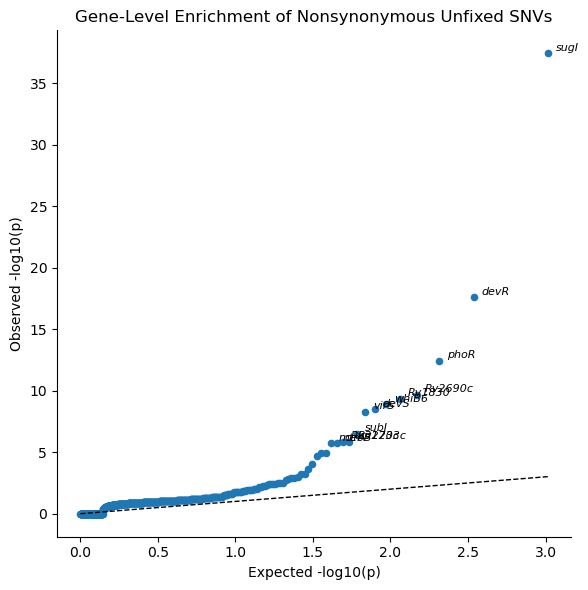

In [241]:
qq_plot_with_labels(df_baseline_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=1e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/baseline_QQ_plot.svg",
                   )


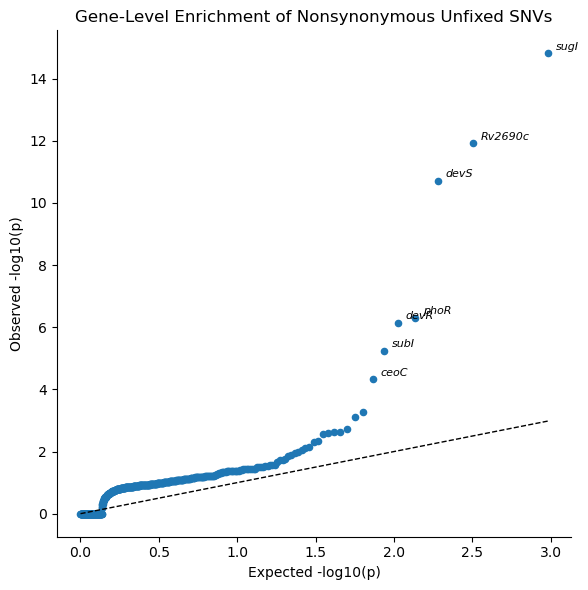

In [242]:
qq_plot_with_labels(df_followup_SNV_enrichment.query("Lineage=='Full'"), 
                    p_label_thresh=5e-5,
                    title="Gene-Level Enrichment of Nonsynonymous Unfixed SNVs",
                    saveName="../results/figures/followup_QQ_plot.svg",
                   )


In [243]:
sample_lineages = pd.read_csv("./data/trees/samples_lineage_annot.tsv", sep='\t')

LinToColor_Dict = {"1": "#DF83AC".lower(),
                   "2": "#7098CB".lower(),
                   "3": "#815D9F".lower(),
                   "4": "#E76956".lower(),
                   "4 DUP": "#E76956".lower(),
                   "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

sample_lineages['Color'] = sample_lineages['Lineage'].map(LinToColor_Dict)
sample_lineages['Type'] = 'label'

sample_lineages[['SampleID', 'Type', 'Color']].to_csv("./data/trees/samples_lineage_colors.txt", sep='\t', index=False)

In [97]:
"#DF83AC".lower()

'#df83ac'

In [110]:
sample_lineages.query("SampleID=='MFS-35'")

,SampleID,Lineage,Color,Type
49,MFS-35,4 DUP,#e76956,label


In [104]:
df_combined_results.query("Gene1=='Rv0010c'")

,Gene,Observed,Expected,Fold_Enrichment,Enrich_pval,Deplete_pval,Twosided_pval,Start,End,Length,Lineage,Bonferroni_pval,Gene1,Gene2,Lineages_Found_In,Midpoint,Neg_Log_Enrich_pval,Significant
16,NC_9,3,0.034483,87.000572,0.000007,1.0,0.000013,13559,13713,155,Full,0.004788,Rv0010c,Rv0011c,2,13636.0,5.176576,0.0
726,NC_9,3,0.019541,153.524763,0.000001,1.0,0.000002,13559,13713,155,2,0.000533,Rv0010c,Rv0011c,NaN,13636.0,5.911685,1.0


In [189]:
def plot_SNV_enrichment_results(df_combined_results, significance_thresh=1e-2, saveName=None):

    df_enriched_plot = df_combined_results.query("Lineage=='Full'").reset_index(drop=True)

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Enrich_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval']

    df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[df_enriched_plot['Region'].str.startswith('NC_')]['total_pval_Bonferroni']
    df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_'), 'Bonferroni_pval'] = df_enriched_plot.loc[~df_enriched_plot['Region'].str.startswith('NC_')]['nonsyn_pval_Bonferroni']

    df_enriched_plot['Midpoint'] = np.mean([df_enriched_plot['Start'], df_enriched_plot['End']], axis=0)

    y_axis_var = 'Neg_Log_Enrich_pval'

    df_enriched_plot['Neg_Log_Enrich_pval'] = -np.log10(df_enriched_plot['Enrich_pval'])

    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] <= significance_thresh, 'Significant'] = 1
    df_enriched_plot.loc[df_enriched_plot['Bonferroni_pval'] > significance_thresh, 'Significant'] = 0

    font_size = 15

    fig, ax = plt.subplots(figsize=(20, 8))

    sns.scatterplot(data=df_enriched_plot.sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
                    x='Midpoint',
                    y=y_axis_var,
                    hue='Significant',
                    palette={1: 'red', 0: 'lightgray'},
                    legend=False,
                    ax=ax,
                    s=100,
                    linewidth=0.5,
                   )

    for i, row in df_enriched_plot.query("Significant==1").iterrows():

        if 'NC' in row['Region']:
            name = f"{row['Gene1']}-{row['Gene2']}"
        else:
            name = row['Region']

        plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic')

    # ax.ticklabel_format(style='plain', axis='x')
    from matplotlib.ticker import StrMethodFormatter

    ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

    sns.despine()

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

    plt.xlabel('Genomic Coordinate', fontsize=font_size)
    plt.ylabel('-log10(p)', fontsize=font_size)

    if saveName is None:
        plt.show()
    else:
        plt.savefig(saveName, bbox_inches='tight')
        
    return df_enriched_plot

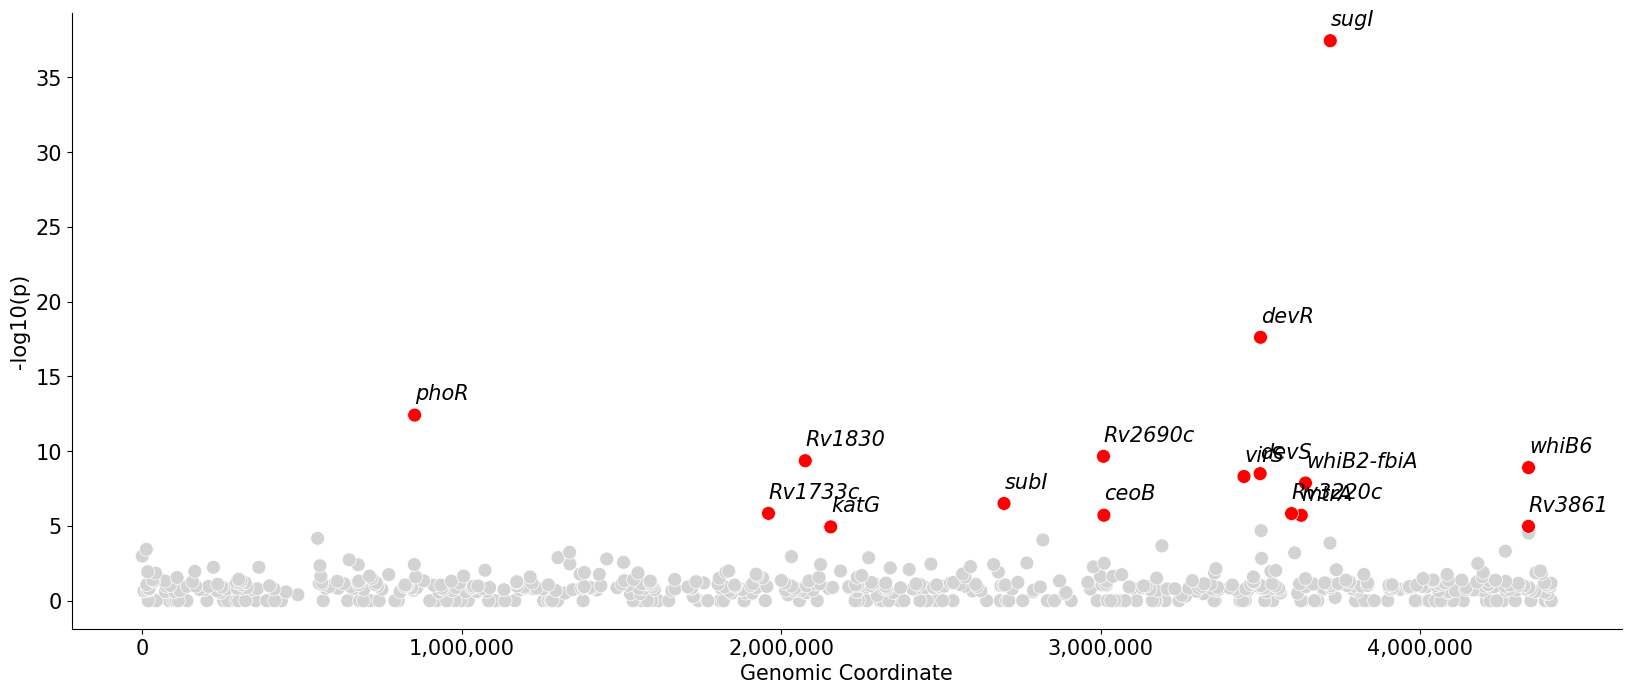

In [210]:
df_baseline_enrichment_final = plot_SNV_enrichment_results(df_baseline_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_baseline.svg")

In [196]:
enriched_regions = df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval').Region.values
print(len(enriched_regions))

16


In [198]:
enriched_regions

array(['sugI', 'devR', 'phoR', 'Rv2690c', 'Rv1830', 'whiB6', 'devS',
       'virS', 'NC_2516', 'subI', 'Rv1733c', 'Rv3220c', 'ceoB', 'mtrA',
       'Rv3861', 'katG'], dtype=object)

In [211]:
df_baseline_enrichment_final.query("Bonferroni_pval <= 0.01").sort_values('Enrich_pval')[['Region', 'Num_pids']]

,Region,Num_pids
62,sugI,25.0
77,devR,7.0
78,phoR,5.0
61,Rv2690c,9.0
82,Rv1830,6.0
250,whiB6,3.0
196,devS,7.0
268,virS,6.0
525,NC_2516,4.0
260,subI,4.0


In [197]:
df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_enrichment_test.copy()

df_lowAF_variants_baseline_for_tree['Present'] = 1

df_lowAF_variants_baseline_for_tree = pd.DataFrame(df_lowAF_variants_baseline_for_tree.query("Region in @enriched_regions").groupby(['SampleID', 'Region'])['Present'].max()).reset_index()

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.pivot(index='SampleID', columns='Region', values='Present')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.reset_index()

df_lowAF_variants_baseline_for_tree = pd.concat([df_lowAF_variants_baseline_for_tree,
                                                 pd.DataFrame({'SampleID': list(set(df_baseline_samples.SampleID) - set(df_lowAF_variants_baseline_for_tree.SampleID))})
                                                ])

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.set_index('SampleID')

df_lowAF_variants_baseline_for_tree = df_lowAF_variants_baseline_for_tree.fillna(0).astype(int)

assert len(set(enriched_regions) - set(df_lowAF_variants_baseline_for_tree.columns)) == 0

df_lowAF_variants_baseline_for_tree.to_csv(f"../results/{len(enriched_regions)}_enriched_baseline_regions.csv")

In [119]:
df_baseline_SNV_enrichment.query("Region in ['Rv3861', 'whiB6'] & Lineage=='Full'")

,Region,syn_pval,syn_fold,nonsyn_pval,nonsyn_fold,total_pval,total_fold,O_syn,O_nonsyn,O_total,...,syn_pval_Bonferroni,nonsyn_pval_Bonferroni,total_pval_Bonferroni,Start,End,Length,Lineage,Gene1,Gene2,Lineages_Found_In
249,Rv3861,0.017565,56.430089,1.057378e-05,74.465950,4.504050e-07,68.956099,1.0,3.0,4.0,...,1.0,5.466645e-03,2.634869e-04,4337946,4338272,327,Full,NaN,NaN,2
250,whiB6,0.018299,54.145725,1.235977e-09,115.237198,7.379138e-11,96.997199,1.0,5.0,6.0,...,1.0,6.390003e-07,4.316795e-08,4338171,4338521,351,Full,NaN,NaN,2


In [42]:
sample = 'MFS-274'
pos = 4338242
df_single_sample_variants = pd.read_csv(f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/freebayes/lowAF_SNPs.csv")

In [43]:
df_single_sample_variants.query("POS==@pos")['ANN'].values[0]

'A|stop_gained|HIGH|whiB6|Rv3862c|transcript|CCP46691|protein_coding|1/1|c.280C>T|p.Gln94*|280/351|280/351|94/116||,A|synonymous_variant|LOW|Rv3861|Rv3861|transcript|CCP46690|protein_coding|1/1|c.297G>A|p.Leu99Leu|297/327|297/327|99/108||WARNING_TRANSCRIPT_NO_START_CODON'

In [45]:
df_lowAF_variants_full.query("Region.str.contains(',')").Region.unique()

array(['Rv3861,whiB6', 'Rv1413,Rv1414', 'Rv1954A,Rv1954c', 'Rv1152,omt',
       'Rv2067c,cobI', 'cyp139,pks11', 'Rv2191,trpD'], dtype=object)

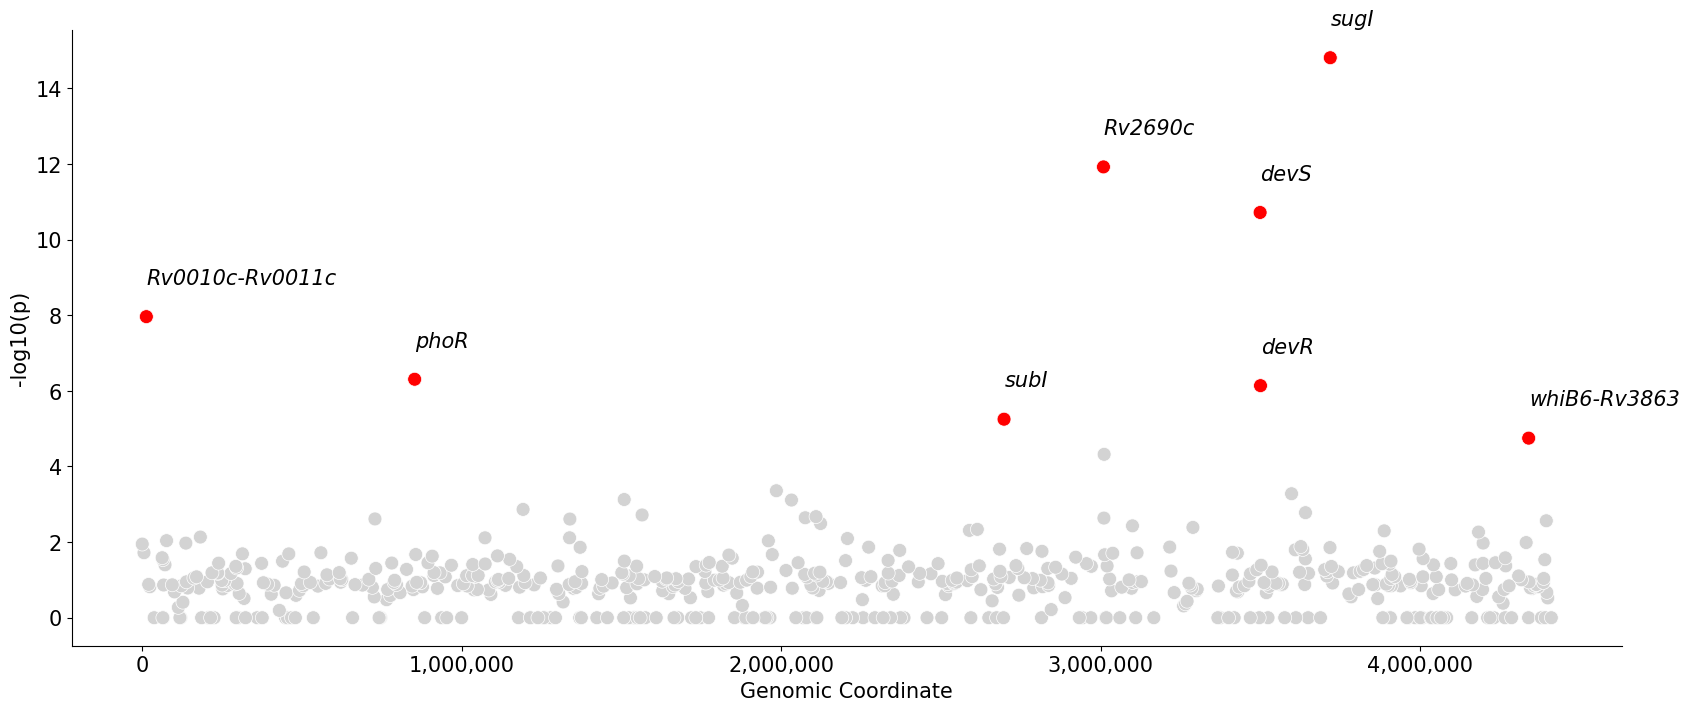

In [246]:
plot_SNV_enrichment_results(df_followup_SNV_enrichment, significance_thresh=1e-2, saveName="../results/figures/Manhattan_plot_SNVs_followup.svg")

In [46]:
# gene_groups = {'sugI': 'Transport',
#                'devR': 'Two-component system',
#                'phoR': 'Two-component system',
#                'devS': 'Two-component system',
#                'Rv1830': 'Transcription factor',
#                'subI': 'Transport',
#                'ceoC': 'Transport',
#                'Rv2690c': 'Transport',
#                'NC_2516': 'Transcription factor',
#                'virS': 'Transcription factor',
#                'NC_2982': 'Transcription factor',
#                'NC_2568': 'Transport',
#                'NC_9': 'Other',
#                'Rv1733c': 'Other'
#               }

# df_combined_results['Midpoint'] = np.mean([df_combined_results['Start'], df_combined_results['End']], axis=0)
# df_combined_results['Group'] = df_combined_results['Gene'].map(gene_groups).fillna('NotSignificant')

# y_axis_var = 'Neg_Log_Enrich_pval'
# # y_axis_var = 'Fold_Enrichment'
# hue_thresh = 1e-2

# df_combined_results['Neg_Log_Enrich_pval'] = -np.log10(df_combined_results['Enrich_pval'])

# df_combined_results.loc[df_combined_results['Bonferroni_pval'] <= hue_thresh, 'Significant'] = 1
# df_combined_results.loc[df_combined_results['Bonferroni_pval'] > hue_thresh, 'Significant'] = 0

# font_size = 15

# fig, ax = plt.subplots(figsize=(20, 8))

# point_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'darkgray', 
#                          'NotSignificant': 'whitesmoke'}

# text_palette = {'Transcription factor': '#215F9A',
#                          'Two-component system': '#78206E', 
#                          'Transport': '#3B7D23',
#                          'Other': 'black', 
#                          'NotSignificant': 'whitesmoke'}

# sns.scatterplot(data=df_combined_results.query("Lineage=='Full'").sort_values('Neg_Log_Enrich_pval', ascending=True), # plot gray points lower in case they are overlain so that you can see the red ones
#                 x='Midpoint',
#                 y=y_axis_var,
#                 hue='Group',
#                 palette=point_palette,
#                 legend=False,
#                 ax=ax,
#                 s=100
#                )

# for i, row in df_combined_results.query("Lineage=='Full'").query("Significant==1").iterrows():
    
#     if 'NC' in row['Gene']:
#         name = f"{row['Gene1']}-{row['Gene2']}"
#     else:
#         name = row['Gene']
    
#     plt.text(row['Midpoint']+1000, row[y_axis_var]+0.75, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic', color=text_palette[row['Group']])

# # ax.ticklabel_format(style='plain', axis='x')
# from matplotlib.ticker import StrMethodFormatter

# ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# sns.despine()

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
# ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

# plt.xlabel('Genomic Coordinate', fontsize=font_size)
# plt.ylabel('-log10(p)', fontsize=font_size)

# plt.savefig("../results/figures/Manhattan_plot_SNVs_for_defense.svg", bbox_inches='tight')

# Unfixed Resistance-Associated Mutations (Indels and LoFs too)

In [173]:
cc_df.query("Drug=='Isoniazid' & Medium in ['MGIT', '7H10']")

,Medium,Value,Drug
47,MGIT,0.1,Isoniazid
48,7H10,0.2,Isoniazid


In [174]:
df_lowAF_variants['variant'] = df_lowAF_variants['GENE'] + '_' + df_lowAF_variants['HGVS_P']

df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent'), 'variant'] = df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent')]['GENE'] + '_' + df_lowAF_variants.loc[(df_lowAF_variants['Variant_Type'] == 'Silent')]['HGVS_C']

In [175]:
INH_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("(s_inhmic_sputum_specimen_1 > 3 & s_inhmicmeth_sputum_specimen_1==2) | (s_inhmic_sputum_specimen_1 > 4 & s_inhmicmeth_sputum_specimen_1==3)").pid.unique()

len(INH_R_samples)

28

In [176]:
EMB_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("s_embmic_sputum_specimen_1 >= 5").pid.unique()

len(EMB_R_samples)

2

In [177]:
PZA_R_samples = df_trust_patients.drop_duplicates(subset='pid').query("s_pzamic_sputum_specimen_1 >= 5").pid.unique()

len(PZA_R_samples)

2

In [184]:
isolate_variants.query("AF > 0 & AF < 0.75").AF.min()

0.09

In [51]:
missing_INH = list(set(INH_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Isoniazid'").pid))
len(missing_INH)

12

In [52]:
missing_EMB = list(set(EMB_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Ethambutol'").pid))
len(missing_EMB)

1

In [53]:
missing_PZA = list(set(PZA_R_samples) - set(isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Pyrazinamide'").pid))
len(missing_PZA)

2

In [28]:
def get_unfixed_resistance_associated_mutations(sample):
    
    fName = f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv"

    silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant', 'intergenic_region']
    LoF_lst = ['frameshift', 'ablation', 'start_lost', 'stop_gained']
    drugs_lst = ['Rifampicin', 'Isoniazid', 'Ethambutol', 'Pyrazinamide']
    
    promoter_sites = df_who_variants.query("effect=='upstream_gene_variant'")['genomic position'].unique().astype(int)

    df_single_sample_variants = pd.read_csv(fName, sep='\t', on_bad_lines='skip')
    df_single_sample_variants['AF'] = df_single_sample_variants['AO'] / df_single_sample_variants['DP']

    for col in df_single_sample_variants.columns:
        if 'ANN' in col:
            df_single_sample_variants.rename(columns={col: col.split('.')[-1]}, inplace=True)

    df_single_sample_variants['variant'] = df_single_sample_variants['GENE'] + '_' + df_single_sample_variants['HGVS_P']

    df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst)), 'variant'] = df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst))]['GENE'] + '_' + df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(silent_lst))]['HGVS_C']

    df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(LoF_lst)), 'variant'] = df_single_sample_variants.loc[df_single_sample_variants['ANN'].str.contains('|'.join(LoF_lst))]['GENE'] + '_' + 'LoF'

    df_single_sample_variants = df_single_sample_variants.merge(df_who_variants[['variant', 'drug', 'FINAL CONFIDENCE GRADING', 'Present_SOLO_S', 'Present_SOLO_R', 'OR_SOLO', 'Present_S', 'Present_R']], on='variant', how='left').rename(columns={'FINAL CONFIDENCE GRADING': 'confidence'})

    df_single_sample_variants['SampleID'] = sample
    
    return df_single_sample_variants.query("AF >= 0.05 & AF <= 0.95") #.query("OR_SOLO > 1 | POS in @promoter_sites").query("AF >= 0.05 & AF <= 0.95 & drug in @drugs_lst")

In [61]:
WHO_regions = df_who_variants.gene.unique()
WHO_resistance_regions = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

df_lowAF_variants_WHO_annot = df_lowAF_variants.query("Variant_Type != 'Silent'").merge(df_who_variants, how='left', on='variant')

In [72]:
df_lowAF_variants_WHO_annot.query("Region=='katG'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
308,2155174,A,G,8.700000e-14,katG,c.938T>C,p.Ile313Thr,1,345,345.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,2153995,G,T,0.000000e+00,katG,c.2117C>A,p.Ala706Glu,1,281,281.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,2154800,A,G,6.300000e-14,katG,c.1312T>C,p.Trp438Arg,1,317,317.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,2155667,A,G,2.400000e-14,katG,c.445T>C,p.Trp149Arg,1,269,269.0,...,NaN,3) Uncertain significance,NaN,No change,AwRI by relaxed thresholds (not endorsed),NaN,yes,NaN,O,1.0
366,2155819,T,C,0.000000e+00,katG,c.293A>G,p.Tyr98Cys,1,257,257.0,...,NaN,3) Uncertain significance,NaN,No change,AwRI by relaxed thresholds (not endorsed),NaN,yes,NaN,O,1.0


In [68]:
df_lowAF_variants_WHO_annot.query("Region=='pncA'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
259,2288760,G,A,2.000000e-14,pncA,c.482C>T,p.Ala161Val,1,313,313.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
df_lowAF_variants.query("Region=='katG'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,variant
401,2155174,A,G,8.700000e-14,katG,c.938T>C,p.Ile313Thr,1,345,345.0,...,0.0,0.998321,1.0,1,2155174_A_G,katG,Missense,Ile,Thr,katG_p.Ile313Thr
474,2153995,G,T,0.000000e+00,katG,c.2117C>A,p.Ala706Glu,1,281,281.0,...,0.0,0.999482,1.0,1,2153995_G_T,katG,Missense,Ala,Glu,katG_p.Ala706Glu
475,2154800,A,G,6.300000e-14,katG,c.1312T>C,p.Trp438Arg,1,317,317.0,...,0.0,0.996060,1.0,1,2154800_A_G,katG,Missense,Trp,Arg,katG_p.Trp438Arg
476,2155667,A,G,2.400000e-14,katG,c.445T>C,p.Trp149Arg,1,269,269.0,...,0.0,0.999864,1.0,1,2155667_A_G,katG,Missense,Trp,Arg,katG_p.Trp149Arg
477,2155819,T,C,0.000000e+00,katG,c.293A>G,p.Tyr98Cys,1,257,257.0,...,0.0,0.998626,1.0,1,2155819_T_C,katG,Missense,Tyr,Cys,katG_p.Tyr98Cys


In [45]:
df_lowAF_variants.query("Region in @WHO_resistance_regions").query("Region in ['gyrB', 'gyrA']")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,False_in_all_Ground_Truth_Samples,predicted,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,variant
709,6923,T,G,0.0,gyrB,c.1684T>G,p.Phe562Val,1,350,350.000,...,0.0,0.999208,1.0,1,6923_T_G,gyrB,Missense,Phe,Val,gyrB_p.Phe562Val
712,6923,T,G,0.0,gyrB,c.1684T>G,p.Phe562Val,1,347,347.000,...,0.0,0.999586,1.0,9,6923_T_G,gyrB,Missense,Phe,Val,gyrB_p.Phe562Val
853,6078,G,T,0.0,gyrB,c.839G>T,p.Gly280Val,1,388,388.000,...,0.0,0.995078,1.0,6,6078_G_T,gyrB,Missense,Gly,Val,gyrB_p.Gly280Val
1242,6608,G,C,13022.0,gyrB,c.1369G>C,p.Val457Leu,1,387,392.667,...,0.0,0.999749,1.0,1,6608_G_C,gyrB,Missense,Val,Leu,gyrB_p.Val457Leu
1250,6608,G,C,14237.2,gyrB,c.1369G>C,p.Val457Leu,1,448,454.333,...,0.0,0.999818,1.0,5,6608_G_C,gyrB,Missense,Val,Leu,gyrB_p.Val457Leu


In [46]:
df_who_variants.query("variant in ['gyrB_p.Phe562Val', 'gyrB_p.Gly280Val', 'gyrB_p.Val457Leu']")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
30280,Levofloxacin,gyrB,p.Val457Leu,gyrB_p.Val457Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,19.0,1.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1
34083,Moxifloxacin,gyrB,p.Val457Leu,gyrB_p.Val457Leu,1,missense_variant,"(see ""Genomic_coordinates"" sheet)",1.0,8.0,1.0,...,NaN,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1


In [19]:
# INH_unfixed_muts = []
# INH_genes = df_who_variants.query("drug=='Isoniazid'").gene.unique()

# for pid in missing_INH:
    
#     for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
#         INH_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
# INH_unfixed_muts = pd.concat(INH_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

# INH_unfixed_muts.query("GENE.str.contains('|'.join(@INH_genes))")

In [55]:
EMB_unfixed_muts = []
EMB_genes = df_who_variants.query("drug=='Ethambutol'").gene.unique()

for pid in missing_EMB:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        EMB_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
EMB_unfixed_muts = pd.concat(EMB_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

EMB_unfixed_muts.query("GENE.str.contains('|'.join(@EMB_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,Present_S,Present_R,SampleID,pid


In [238]:
PZA_unfixed_muts = []
PZA_genes = df_who_variants.query("drug=='Pyrazinamide'").gene.unique()

for pid in missing_PZA:
    
    for sample in df_trust_patients.query("pid==@pid").SampleID.unique():
        PZA_unfixed_muts.append(get_unfixed_resistance_associated_mutations(sample))
        
PZA_unfixed_muts = pd.concat(PZA_unfixed_muts).merge(df_trust_patients[['pid', 'SampleID']])

PZA_unfixed_muts.query("GENE.str.contains('|'.join(@PZA_genes))")

,POS,REF,ALT,QUAL,FILTER,GENE,HGVS_C,HGVS_P,NS,DP,...,variant,drug,confidence,Present_SOLO_S,Present_SOLO_R,OR_SOLO,OR_SOLO_exact_lb,OR_SOLO_exact_ub,SampleID,pid


In [70]:
isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID & drug=='Isoniazid'").AF.min()

np.float64(0.56)

In [23]:
isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & SampleID in @df_trust_patients.SampleID").drop_duplicates(subset=['SampleID', 'variant']).query("drug in ['Ethambutol', 'Pyrazinamide']")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
18389,MFS-533,4247429,A,G,PASS,8303.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,embB,c.916A>G,p.Met306Val,embB_p.Met306Val,Ethambutol,1) Assoc w R
18448,MFS-534,4247429,A,G,PASS,8045.0,False,1.0,238.0,34.0,60.0,0.0,0.0,missense_variant,embB,c.916A>G,p.Met306Val,embB_p.Met306Val,Ethambutol,1) Assoc w R
23288,MFS-637,2289202,A,G,PASS,8287.0,False,1.0,246.0,34.0,60.0,0.0,0.0,missense_variant,pncA,c.40T>C,p.Cys14Arg,pncA_p.Cys14Arg,Pyrazinamide,1) Assoc w R


In [ ]:
# 4 = 0.125-0.25 
df_trust_patients.query("pid in ['T0186']")[['pid', 's_rifmic_sputum_specimen_1', 's_rifmic_sputum_specimen_2']]

,pid,s_rifmic_sputum_specimen_1,s_rifmic_sputum_specimen_2
582,T0186,4.0,NaN
583,T0186,4.0,NaN


In [335]:
df_trust_patients.query("pid=='T0186'")[['pid', 's_rifmic_sputum_specimen_1']]

,pid,s_rifmic_sputum_specimen_1
582,T0186,4.0
583,T0186,4.0


In [193]:
# 2 = 0.6-1.25
df_trust_patients.query("pid in ['T0352', 'T0278']")[['pid', 's_embmic_sputum_specimen_1', 's_embmic_sputum_specimen_2']]

,pid,s_embmic_sputum_specimen_1,s_embmic_sputum_specimen_2
540,T0352,2.0,NaN
541,T0352,2.0,NaN
783,T0278,2.0,NaN
784,T0278,2.0,NaN


In [173]:
df_lowAF_variants_WHO = df_lowAF_variants[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'GENE', 'HGVS_C', 'HGVS_P', 'variant']].merge(df_who_variants.query("tier==1")[['variant', 'drug', 'FINAL CONFIDENCE GRADING']], on='variant', how='left')

df_lowAF_variants_WHO['FINAL CONFIDENCE GRADING'].value_counts()

FINAL CONFIDENCE GRADING
3) Uncertain significance     7
4) Not assoc w R - Interim    1
Name: count, dtype: int64

In [196]:
df_lowAF_variants_WHO.query("GENE=='embA'")#.dropna(subset='FINAL CONFIDENCE GRADING')

,pid,SampleID,POS,REF,ALT,AF,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
438,T0278,MFS-296,4246040,C,T,0.120805,embA,c.2808C>T,p.Ala936Ala,embA_c.2808C>T,NaN,NaN
613,T0352,MFS-433,4244674,A,G,0.176030,embA,c.1442A>G,p.Glu481Gly,embA_p.Glu481Gly,NaN,NaN


In [176]:
df_who_variants.query("variant=='gyrB_p.Val457Leu'")[['drug', 'Present_SOLO_S', 'Present_SOLO_R']]

,drug,Present_SOLO_S,Present_SOLO_R
30280,Levofloxacin,18.0,1.0
34083,Moxifloxacin,7.0,1.0


# Changes in Unfixed Variants

In [13]:
def convert_variants_to_matrices(df_variants, variant_col, baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only:
        df_variants['Paired_Sample_Num'] = 1
    else:
        assert sum(pd.isnull(df_variants['Paired_Sample_Num'])) == 0

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values='AF')
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [14]:
df_combined_variants = pd.concat([df_variants_full, df_indels.query("pid in @df_variants.pid")]).reset_index(drop=True)
df_combined_variants['Variant'] = df_combined_variants['SNP']
df_combined_variants['Variant'] = df_combined_variants['Variant'].fillna(df_combined_variants['Indel'])

In [15]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants, sample_2_variants, variant_differences = convert_variants_to_matrices(df_combined_variants.query("pid in @pids_with_same_lineage_and_low_F2"), 'Variant')

(285, 12741)


In [16]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
# sample_1_SNVs, sample_2_SNVs, SNV_differences = convert_variants_to_matrices(df_variants, 'SNP')

In [17]:
df_combined_variants_baseline = pd.concat([df_variants_baseline, df_indels.query("SampleID in @df_variants_baseline.SampleID")]).reset_index(drop=True)
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['SNP']
df_combined_variants_baseline['Variant'] = df_combined_variants_baseline['Variant'].fillna(df_combined_variants_baseline['Indel'])

In [18]:
# for analyzing variant changes because unfixed --> fixed and vice versa are important to see
sample_1_variants_baseline = convert_variants_to_matrices(df_combined_variants_baseline, 'Variant', baseline_only=True)

(395, 14677)


In [68]:
drug_R_genes = isolate_variants.query("confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").GENE.unique()
drug_R_genes

array(['Rv1482c-fabG1', 'rpsL', 'katG', 'gid', 'inhA', 'embB', 'ethA',
       'fabG1', 'pncA', 'fbiC'], dtype=object)

In [69]:
sample_1_R_SNVs, sample_2_R_SNVs, R_SNV_differences = convert_variants_to_matrices(df_variants.query("GENE in @drug_R_genes & Variant_Type != 'Silent'"), 'SNP')

(225, 27)


<Axes: xlabel='SNP'>

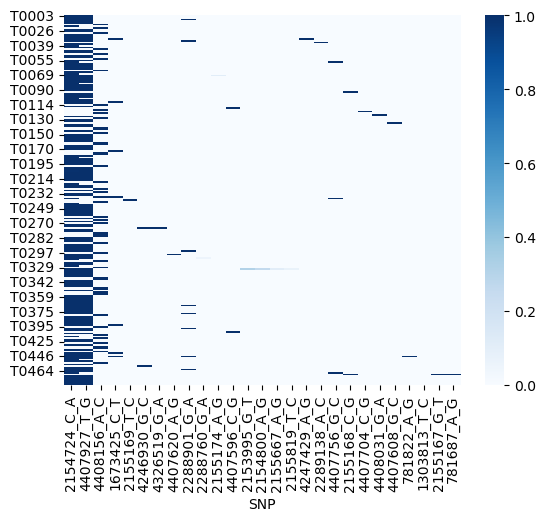

In [70]:
sns.heatmap(sample_1_R_SNVs,
            cmap='Blues'
           )

In [11]:
# Rv3132c and Rv3133c are dosS and dosR, repectively
dosR_regulon_genes = ['Rv0079', 'Rv0080', 'Rv0081', 'Rv0082', 'Rv0083', 
                      'Rv0569', 'nrdZ', 'Rv0571c', 'Rv0572c', 'Rv0574c',
                      'MT0639',
                      'Rv1733c', 'Rv1734c', 'Rv1736c', 'Rv1737c', 'Rv1738',
                      'Rv1812c', 'Rv1813c', 
                      'ctpF', 'Rv1997', 
                      'Rv2003c', 'Rv2004c', 'Rv2005c', 'Rv2006', 'Rv2007c', 
                      'Rv2028c', 'pfkB', 'Rv2030c', 'Rv2031c', 'Rv2032',
                      'Rv2623', 'Rv2624c', 'Rv2625c', 'Rv2626c', 'Rv2627c', 'Rv2628', 'Rv2629', 'Rv2630', 'Rv2631',
                      'Rv2830c',
                      'Rv3126c', 'Rv3127', 'Rv3128c', 'Rv3129', 'Rv3130c', 'Rv3131', 'Rv3132c', 'Rv3134c',
                      'bfrB'
                     ]

len(dosR_regulon_genes), len(np.unique(dosR_regulon_genes))

(49, 49)

In [12]:
df_lowAF_variants_full.query("Region in @dosR_regulon_genes")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,pred_class,Sampling_Week,SNP,Region,Variant_Type,REF_AA,ALT_AA,Paired_Sample_Num,GENE1,GENE2
63,1960078,C,A,9.450430e-14,Rv1733c,c.410G>T,p.Gly137Val,1.0,304,304.0,...,1.0,1,1960078_C_A,Rv1733c,Missense,Gly,Val,1,Rv1733c,None
79,1960057,A,C,0.000000e+00,Rv1733c,c.431T>G,p.Val144Gly,1.0,403,403.0,...,1.0,1,1960057_A_C,Rv1733c,Missense,Val,Gly,1,Rv1733c,None
353,2251423,A,G,3.149500e+03,Rv2005c,c.461T>C,p.Ile154Thr,1.0,241,241.0,...,1.0,6,2251423_A_G,Rv2005c,Missense,Ile,Thr,2,Rv2005c,None
366,88721,A,G,5.207390e-14,Rv0079,c.518A>G,p.Asp173Gly,1.0,253,253.0,...,1.0,1,88721_A_G,Rv0079,Missense,Asp,Gly,1,Rv0079,None
423,2955114,G,A,0.000000e+00,Rv2628,c.57G>A,p.Trp19*,1.0,266,266.0,...,1.0,8,2955114_G_A,Rv2628,Nonsense,Trp,19*,2,Rv2628,None
545,1960375,G,T,4.978340e-14,Rv1733c,c.113C>A,p.Thr38Lys,1.0,315,315.0,...,1.0,1,1960375_G_T,Rv1733c,Missense,Thr,Lys,1,Rv1733c,None
562,1960483,A,G,0.000000e+00,Rv1733c,c.5T>C,p.Ile2Thr,1.0,249,249.0,...,1.0,1,1960483_A_G,Rv1733c,Missense,Ile,Thr,1,Rv1733c,None
1206,2242705,G,A,0.000000e+00,ctpF,c.2547G>A,p.Ala849Ala,1.0,341,341.0,...,1.0,1,2242705_G_A,ctpF,Silent,Ala,Ala,1,ctpF,None
1370,2958771,G,A,1.988930e-14,Rv2631,c.1200G>A,p.Glu400Glu,1.0,324,324.0,...,1.0,8,2958771_G_A,Rv2631,Silent,Glu,Glu,1,Rv2631,None
1593,2248838,G,A,2.422920e-14,Rv2003c,c.583C>T,p.Pro195Ser,1.0,297,297.0,...,1.0,1,2248838_G_A,Rv2003c,Missense,Pro,Ser,1,Rv2003c,None


In [456]:
h37Rv_genes.query("Symbol in @dosR_regulon_genes | H37rv_GeneID in @dosR_regulon_genes").shape

(47, 32)

In [457]:
set(dosR_regulon_genes) - set(h37Rv_genes.query("Symbol in @dosR_regulon_genes | H37rv_GeneID in @dosR_regulon_genes").H37rv_GeneID) - set(h37Rv_genes.query("Symbol in @dosR_regulon_genes | H37rv_GeneID in @dosR_regulon_genes").Symbol)

{'MT0639'}

In [458]:
dosR_regulon_gene_names = h37Rv_genes.query("Symbol in @dosR_regulon_genes | H37rv_GeneID in @dosR_regulon_genes").Symbol.values
len(dosR_regulon_gene_names)

47

In [459]:
df_corrs.query("Region1=='devR' | Region2=='devR'").query("Region1 in @dosR_regulon_gene_names | Region2 in @dosR_regulon_gene_names")

,Mut1,Mut2,rho,pval,Region1,Region2,Bonferroni_pval


In [461]:
df_corrs.query("Region1=='Rv1733c' | Region2=='Rv1733c'")

,Mut1,Mut2,rho,pval,Region1,Region2,Bonferroni_pval


In [465]:
df_lowAF_variants_full.query("Region=='Rv1733c'")[['pid', 'SampleID', 'SNP']]

,pid,SampleID,SNP
63,T0219,MFS-127,1960078_C_A
79,T0222,MFS-131,1960057_A_C
545,T0324,MFS-388,1960375_G_T
562,T0328,MFS-391,1960483_A_G


In [334]:
sample_1_variants.shape, sample_2_variants.shape

((285, 12728), (285, 12728))

In [100]:
nonzero_vals_1 = sample_1_variants.values.flatten()
nonzero_vals_1 = nonzero_vals_1[(nonzero_vals_1 >= 0.05) & (nonzero_vals_1 <= 0.95)]

nonzero_vals_2 = sample_2_variants.values.flatten()
nonzero_vals_2 = nonzero_vals_2[(nonzero_vals_2 >= 0.05) & (nonzero_vals_2 <= 0.95)]

len(nonzero_vals_1), len(nonzero_vals_2)

(659, 751)

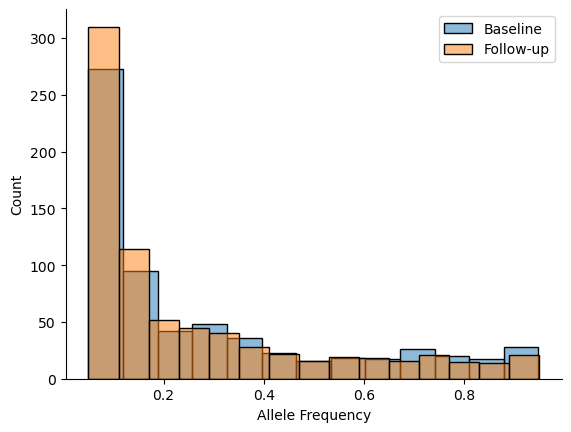

In [41]:
alpha = 0.5
plot_val = 'count'

fig, ax = plt.subplots()
sns.histplot(nonzero_vals_1, ax=ax, label='Baseline', alpha=alpha, stat=plot_val)
sns.histplot(nonzero_vals_2, ax=ax, label='Follow-up', alpha=alpha, stat=plot_val)
plt.xlabel('Allele Frequency')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.savefig("../results/figures/site_frequency_spectra.svg", bbox_inches='tight')

In [42]:
np.mean(nonzero_vals_1), np.mean(nonzero_vals_2)

(0.27991074502409363, 0.25662390570452426)

In [101]:
st.ks_2samp(nonzero_vals_1,
            nonzero_vals_2,
            alternative='two-sided'
           ).pvalue

0.4630973871929463

In [96]:
# # look for samples with a difference in an intermediate range, not absent to fixed because those are probably not real
# # 0.05 is within the rror rate of 
# diff_min = 0.05
# diff_max = 1 - diff_min

# SNV_differences_long = SNV_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid'})

# SNV_large_differences_long = SNV_differences_long.query("(value > @diff_min & value < @diff_max) | (-@diff_max < value < -@diff_min)").merge(df_variants[['POS', 'SNP', 'GENE', 'Variant_Type', 'HGVS_P', 'Region', 'GENE1', 'GENE2']].drop_duplicates())
# SNV_large_differences_long['Variant'] = SNV_large_differences_long['GENE'] + '_' + SNV_large_differences_long['HGVS_P']

# SNV_large_differences_long = SNV_large_differences_long.merge(h37Rv_regions.query("Feature=='CDS'")[['Name', 'Functional_Category']], left_on='GENE', right_on='Name', how='left')

# for i, row in SNV_large_differences_long.iterrows():
#     SNV_large_differences_long.loc[i, 'Plot_SNP'] = row['SNP'].rsplit('_', 1)[0].replace('_', ' ') + '>' + row['SNP'].rsplit('_', 1)[-1]
    
# SNV_large_differences_long['GENE'].value_counts().head(20)

In [78]:
fixed_AF = 0.95

sample_1_SNVs_long = sample_1_SNVs.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'BL'})
sample_2_SNVs_long = sample_2_SNVs.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'FU'})

unfixed_SNVs_wide = sample_1_SNVs_long.merge(sample_2_SNVs_long)

# exclude variants absent or fixed at both timepoints
unfixed_SNVs_wide = unfixed_SNVs_wide.query("~(BL==0 & FU==0) & ~(BL > @fixed_AF & FU > @fixed_AF)")

unfixed_SNVs_wide = unfixed_SNVs_wide.merge(df_variants[['SNP', 'Variant_Type', 'Region', 'GENE1', 'GENE2']].drop_duplicates(), how='left')

unfixed_SNVs_long = unfixed_SNVs_wide.melt(id_vars=['pid', 'SNP', 'Variant_Type', 'Region', 'GENE1', 'GENE2'],
                                           value_vars=["BL", "FU"],
                                           var_name="Timepoint",
                                           value_name="Value"
                                          )

unfixed_SNVs_wide['Diff'] = unfixed_SNVs_wide['FU'] - unfixed_SNVs_wide['BL']
unfixed_SNVs_wide['Abs_Diff'] = np.abs(unfixed_SNVs_wide['Diff'])

In [ ]:
sns.heatmap(unfixed_SNVs_wide.query("Region=='sugI'"),
            
           )

In [92]:
df_trust_patients.query("pid=='T0359'").sort_values('Sampling_Week')

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week
514,T0359,S0359-01,MFS-444,MFS-444_lib59643,NaN,NaN,1.0,251.14,0.99,0.9905,...,0.133087,NaN,0.010738,2.2.1.1,2.2.1.1.1,2,0.41,251.0,98.056503,1
513,T0359,S0359-07,MFS-445,MFS-445_lib59644,NaN,NaN,1.0,279.13,0.99,0.9825,...,0.133087,NaN,0.010719,2.2.1.1,2.2.1.1.1,2,1.06,279.0,98.078763,7


In [88]:
unfixed_SNVs_wide.query("Region=='sugI'").query("SNP.str.contains('3717108')")

,pid,SNP,BL,FU,Variant_Type,Region,GENE1,GENE2,Diff,Abs_Diff
129,T0200,3717108_C_A,0.718147,0.000000,Missense,sugI,sugI,None,-0.718147,0.718147
130,T0220,3717108_C_A,0.702341,0.000000,Missense,sugI,sugI,None,-0.702341,0.702341
131,T0251,3717108_C_A,0.000000,0.100592,Missense,sugI,sugI,None,0.100592,0.100592
132,T0264,3717108_C_A,0.000000,0.501754,Missense,sugI,sugI,None,0.501754,0.501754
133,T0359,3717108_C_A,0.207048,0.000000,Missense,sugI,sugI,None,-0.207048,0.207048


In [94]:
unfixed_SNVs_wide.query("Region=='sugI'").query("BL != 0 & FU != 0")

,pid,SNP,BL,FU,Variant_Type,Region,GENE1,GENE2,Diff,Abs_Diff
185,T0254,3717105_C_T,0.306283,0.620155,Nonsense,sugI,sugI,None,0.313872,0.313872
192,T0396,3717105_C_T,0.126844,0.762533,Nonsense,sugI,sugI,None,0.635689,0.635689


<Axes: xlabel='BL', ylabel='Diff'>

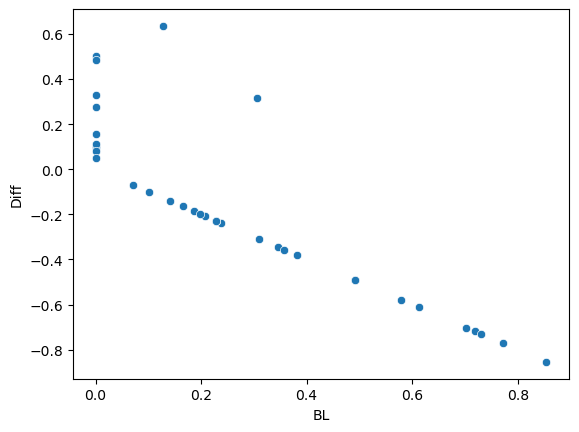

In [84]:
sns.scatterplot(data=unfixed_SNVs_wide.query("Region=='sugI'"),
                x='BL',
                y='Diff'
               )

In [129]:
# unfixed_SNVs_wide.query("Region=='sugI'").pivot(index='pid', columns='BL', values='Diff')

In [79]:
unfixed_SNVs_wide.query("Region=='sugI'")

,pid,SNP,BL,FU,Variant_Type,Region,GENE1,GENE2,Diff,Abs_Diff
129,T0200,3717108_C_A,0.718147,0.000000,Missense,sugI,sugI,None,-0.718147,0.718147
130,T0220,3717108_C_A,0.702341,0.000000,Missense,sugI,sugI,None,-0.702341,0.702341
131,T0251,3717108_C_A,0.000000,0.100592,Missense,sugI,sugI,None,0.100592,0.100592
132,T0264,3717108_C_A,0.000000,0.501754,Missense,sugI,sugI,None,0.501754,0.501754
133,T0359,3717108_C_A,0.207048,0.000000,Missense,sugI,sugI,None,-0.207048,0.207048
163,T0209,3717219_C_T,0.345304,0.000000,Silent,sugI,sugI,None,-0.345304,0.345304
164,T0249,3717219_C_T,0.771357,0.000000,Silent,sugI,sugI,None,-0.771357,0.771357
165,T0328,3717219_C_T,0.000000,0.113636,Silent,sugI,sugI,None,0.113636,0.113636
166,T0337,3717219_C_T,0.185682,0.000000,Silent,sugI,sugI,None,-0.185682,0.185682
167,T0428,3717219_C_T,0.854406,0.000000,Silent,sugI,sugI,None,-0.854406,0.854406


In [32]:
# diff_min = 0.05
# diff_max = 0.95

# enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.query("Region in @enriched_genes")#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='greater')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# plt.savefig("../results/figures/AF_changes_in_enriched_genes.svg")


In [94]:
# diff_min = 0.05
# diff_max = 0.95

# # enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# # enriched_genes = ['devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
# enriched_genes = df_combined_results.query("Lineage=='Full' & Bonferroni_pval <= 0.01").Gene.unique()

# # enriched genes if you include only samples with baseline WGS (Sampling_Week <= 2)
# # enriched_genes = ['sugI', 'devR', 'phoR', 'Rv1830', 'NC_2516', 'devS', 'virS', 'Rv2690c', 'subI', 'Rv1733c', 'ceoB', 'mtrA', 'Rv3220c']
    
# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# df = unfixed_SNVs_wide.copy()#.query("Variant_Type != 'Silent'")
# stat, pval = st.ttest_rel(df['BL'], df['FU'], alternative='less')
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df.iterrows():
#     plt.plot([0, 1], [row["BL"], row["FU"]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df["BL"].mean(), df["FU"].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df["BL"]) * st.t.ppf(0.975, len(df)-1)
# ci_fu = st.sem(df["FU"]) * st.t.ppf(0.975, len(df)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# # plt.savefig("../results/figures/nonsilent_enriched_genes.svg")


In [93]:
# def plot_unfixed_SNV_change_heatmap(gene, silent=False, width=5, height=5, saveName=None):
    
#     # include upstream regions???
    
#     if silent:
#         search_SNVs = np.sort(SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("GENE==@gene | Region.str.contains(@gene)").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     else:
#         search_SNVs = np.sort(SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").SNP.unique())
#         matrix_to_plot = SNV_large_differences_long.query("Variant_Type != 'Silent' & (GENE==@gene | Region.str.contains(@gene))").sort_values("POS").pivot(index='Plot_SNP', columns='pid', values='value').fillna(0)
#     # print(matrix_to_plot.shape)

#     # matrix_to_plot = matrix_to_plot.T
    
#     annot = matrix_to_plot.copy()

#     # have to preformat it yourself
#     annot = np.round(annot, 2).astype(str)
#     annot[matrix_to_plot == 0] = ""

#     fig, ax = plt.subplots(figsize=(width, height))

#     sns.heatmap(matrix_to_plot,
#                 cmap='vlag',
#                 vmin=-1,
#                 center=0,
#                 vmax=1,
#                 ax=ax,
#                 annot=annot,
#                 annot_kws={'fontsize': 10},
#                 fmt='s',
#                )
    
#     x_label = f'Participants (N = {matrix_to_plot.shape[1]})'
#     y_label = 'SNV'
#     ax.set_xticks([]) 
    
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
    
#     if saveName is None:
#         plt.show()
#     else:
#         plt.savefig(saveName, bbox_inches='tight')

In [71]:
# gene = 'sugI'

# plot_unfixed_SNV_change_heatmap(gene, width=20, height=5, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [72]:
# gene = 'katG'

# plot_unfixed_SNV_change_heatmap(gene, width=2, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [73]:
# gene = 'Rv1733c'

# plot_unfixed_SNV_change_heatmap(gene, width=4, height=3, saveName=f"/home/sak0914/MtbLongitudinalDiversity/results/figures/{gene}_nonsilent_changes.svg")

In [157]:
# # lower because of variants at 163705 and 163706, which are often in the range 0.9-0.95 and is why we're doing this exclusion in the first place
# fixed_thresh = 0.9

# mask = (SNV_differences.abs() > fixed_thresh) & ((sample_1_SNVs == 0) | (sample_2_SNVs == 0))

# # Get coordinates (row, col) of matches
# matches = mask.stack()  # converts to Series with MultiIndex
# matches = matches[matches]  # filter True values

# exclude_SNPs = matches.reset_index().iloc[:, :2]
# exclude_SNPs.columns = ['pid', 'SNP']

# print(f"Excluding {len(exclude_SNPs)} (pid, SNP) pairs that are suspicious")

# # replace the values. Make the SNPs fixed in both, and the difference 0
# sample_1_SNVs.mask(mask, other=1, inplace=True)
# sample_2_SNVs.mask(mask, other=1, inplace=True)
# SNV_differences.mask(mask, other=0, inplace=True)

# # Convert to tuples for comparison
# to_exclude = set(exclude_SNPs.itertuples(index=False, name=None))

# # # remove the SNPs from df_variants and df_lowAF_variants
# # df_variants = df_variants[~df_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]
# # df_lowAF_variants = df_lowAF_variants[~df_lowAF_variants[['pid', 'SNP']].apply(tuple, axis=1).isin(to_exclude)]

# # do the same for the baseline ones?
# # df_variants_baseline, df_lowAF_variants_baseline

# Selecting a Diversity Metric

In [14]:
AF_lst = np.linspace(0.005, 0.995, 101)

df_test = pd.DataFrame({'AF': AF_lst})
# df_test['Product'] = df_test['AF'] * (1 - df_test['AF'])
# df_test['Gini_Impurity'] = 1 - df_test['AF']**2 - (1 - df_test['AF'])**2
df_test['Shannon_Entropy'] = - df_test['AF'] * np.log2(df_test['AF']) - (1 - df_test['AF']) * np.log2(1 - df_test['AF'])

df_test = df_test.melt(id_vars='AF')

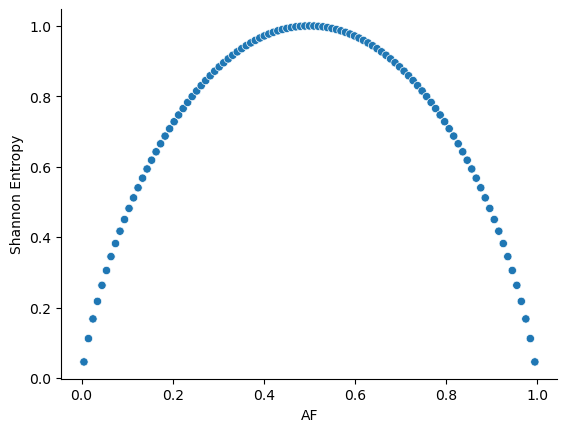

In [15]:
sns.scatterplot(data=df_test,
                x='AF',
                y='value',
                hue='variable',
                legend=False
               )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Product',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Gini_Impurity',
#                 # legend=False
#                )

# sns.scatterplot(data=df_test,
#                 x='AF',
#                 y='Shannon_Entropy',
#                 # legend=False
#                )

# plt.legend(title='')

plt.xlabel('AF')
plt.ylabel('Shannon Entropy')
# plt.title(f"Product of AF and (1 - AF)")
sns.despine()
plt.savefig("../results/figures/Shannon_Entropy_example.svg")

In [19]:
def LAF_metric(AF_series, AF_min=0.05, AF_max=0.95):
    
    # the series has the SNP names as the indexes
    AF_array = AF_series.values
    
    # exclude absent or fixed variants from the count of low frequency variants
    keep_idx = np.argwhere((AF_array >= AF_min) & (AF_array <= AF_max)).flatten()
    keep_variants = AF_series.iloc[keep_idx].index.values

    # exclude 0s because those are no variants. It's because it's from a matrix, all positions that have a variant anywhere are there
    # any zeroes or ones (zeroes because 1 - AF) will zero out the Shannon entropy
    AF_array = AF_array[(AF_array >= AF_min) & (AF_array <= AF_max)]
    
    if len(AF_array) == 0:
        return [], 0, 0

    LAF = 0

    for i, AF in enumerate(AF_array):        
        # shannon entropy
        LAF += - AF * np.log2(AF) - (1 - AF) * np.log2(1 - AF)

    # return mean Shannon entropy. Also return the number of variable sites
    return keep_variants, LAF, LAF / len(AF_array)


def compute_proportion_variable_sites_shared_2samples(pid, df):
    
    df_sample_1 = df.query("pid == @pid & Paired_Sample_Num == 1")
    df_sample_2 = df.query("pid == @pid & Paired_Sample_Num == 2")
    
    sites_variable_intersect = list(set(df_sample_1.POS).intersection(df_sample_2.POS))
    sites_variable_union = list(set(df_sample_1.POS).union(df_sample_2.POS))
    
    if len(sites_variable_union) == 0:
        return 0
    
    # return proportion of all variable sites that are common between the two samples
    return len(sites_variable_intersect) / len(sites_variable_union)

In [20]:
def compute_diversity_metric_changes(sample_1_SNVs, sample_2_SNVs, SNV_differences, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SE2', 'SASE1', 'SASE2', 'NumVar1', 'NumVar2', 'NumVar', 'OverlapVarSites', 'ChangeSites'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=silent_SNPs)
        sample_2_SNVs = sample_2_SNVs.drop(columns=silent_SNPs)
        SNV_differences = SNV_differences.drop(columns=silent_SNPs)
        
    print(SNV_differences.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        # remove sites that are fixed (AF > AF_thresh) in both. Keep those that are fixed in one and not the other though
        single_pid_results = pd.DataFrame(SNV_differences.loc[pid]).query(f"{pid} != 0").merge(pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
        single_pid_results = single_pid_results.query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(single_pid_results['Sample1'], AF_min=0.05, AF_max=AF_thresh)
        sample_2_variable_sites, sample_2_SE, sample_2_SASE = LAF_metric(single_pid_results['Sample2'], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_2_SE, # Shannon entropy for sample 2
                            sample_1_SASE,
                            sample_2_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                            len(sample_2_variable_sites), # number of variable sites for sample 2
                            len(list(set(sample_1_variable_sites).union(sample_2_variable_sites))), # union of variable sites in samples 1 and 2
                            len(list(set(sample_1_variable_sites).intersection(sample_2_variable_sites))),
                            len(list(set(sample_1_variable_sites).symmetric_difference(sample_2_variable_sites))), # non-overlapping set of sites from samples 1 and 2 
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF['SE_Diff'] = df_LAF['SE2'] - df_LAF['SE1']
    df_LAF['SASE_Diff'] = df_LAF['SASE2'] - df_LAF['SASE1']
    df_LAF['Abs_SASE_Diff'] = np.abs(df_LAF['SASE_Diff'])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))
    # df_LAF['Lineage'] = df_LAF['Lineage'].astype(int)
    df_LAF['NumVarDiff'] = df_LAF['NumVar2'] - df_LAF['NumVar1']

    df_LAF.to_csv(f"../results/diversity_metrics_{df_LAF.pid.nunique()}pids.csv", index=False)

    df_lowAF_variants.to_csv(f"../results/lowAF_variants_{df_lowAF_variants.pid.nunique()}pids.csv", index=False)
    
    return df_LAF
    
    
    
    
def compute_diversity_metric_baseline(sample_1_SNVs, df_pids, silent_SNPs, AF_thresh=0.95, silent=True):

    # segregating sites is symmetric difference between sample 1 and sample 2. These are the sites that are different between them?
    df_LAF = pd.DataFrame(columns = ['pid', 'SE1', 'SASE1', 'NumVar1'])
    
    if not silent:
        sample_1_SNVs = sample_1_SNVs.drop(columns=list(set(silent_SNPs).intersection(sample_1_SNVs.columns)))
        
    print(sample_1_SNVs.shape)

    for i, pid in enumerate(sample_1_SNVs.index.values):

        sample_1_variable_sites, sample_1_SE, sample_1_SASE = LAF_metric(sample_1_SNVs.loc[pid, :], AF_min=0.05, AF_max=AF_thresh)

        df_LAF.loc[i, :] = [pid, 
                            sample_1_SE, # Shannon entropy for sample 1
                            sample_1_SASE,
                            len(sample_1_variable_sites), # number of variable sites for sample 1
                           ]

    # add in pids that are not in sample_1_unfixed_SNVs, which don't have a low frequency metric anywhere
    pids_no_LAF_variants = list(set(df_pids.pid) - set(df_LAF.pid))
    df_pids_no_LAF_variants = pd.DataFrame(columns = df_LAF.columns)
    df_pids_no_LAF_variants['pid'] = pids_no_LAF_variants

    for col in df_pids_no_LAF_variants.columns:
        if col != 'pid':
            df_pids_no_LAF_variants[col] = 0

    df_LAF = pd.concat([df_LAF, df_pids_no_LAF_variants])

    df_LAF = df_LAF.merge(df_pids[['pid', 'Coll2014', 'Freschi2020', 'Lineage', 'F2']].drop_duplicates(subset='pid'))

    return df_LAF

In [18]:
# df_LAF = compute_diversity_metric_changes(sample_1_SNVs, 
#                                           sample_2_SNVs, 
#                                           SNV_differences, 
#                                           df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
#                                           df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
#                                           # df_variants.SNP.unique(),
#                                           silent=True,
#                                           AF_thresh=0.95
#                                          )

# df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
# df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

# df_LAF_baseline = compute_diversity_metric_baseline(sample_1_SNVs_baseline, 
#                                                     df_baseline_samples, 
#                                                     df_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
#                                                     # df_variants_baseline.SNP.unique(), 
#                                                     silent=True,
#                                                     AF_thresh=0.95
#                                                    )

# df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

In [21]:
df_LAF = compute_diversity_metric_changes(sample_1_variants, 
                                          sample_2_variants, 
                                          variant_differences, 
                                          df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2"), 
                                          df_variants.query("Variant_Type == 'Silent'").SNP.unique(), 
                                          # df_variants.SNP.unique(),
                                          silent=True,
                                          AF_thresh=0.95
                                         )

df_LAF = df_LAF.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_LAF = df_LAF.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

# exclude T0245 because too many fixed SNPs gained, so they might not be from the same person
df_LAF = df_LAF.query("pid != 'T0245'")

df_LAF_baseline = compute_diversity_metric_baseline(sample_1_variants_baseline, 
                                                    df_baseline_samples, 
                                                    df_combined_variants_baseline.query("Variant_Type=='Silent'").SNP.unique(), 
                                                    # df_variants_baseline.SNP.unique(), 
                                                    silent=True,
                                                    AF_thresh=0.95
                                                   )

df_LAF_baseline = df_LAF_baseline.merge(df_trust_patients[['pid', 's_ttp_sputum_specimen_1']].drop_duplicates())

(285, 12741)
(395, 14677)


In [22]:
df_unfixed_indel_burden = pd.DataFrame(df_indels.query("AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_indel_burden.columns = ['pid', 'NumIndels']

df_unfixed_phase_variant_burden = pd.DataFrame(df_indels.query("phase_variant==1 & AF >= 0.05 & AF <= 0.95 & SampleID in @df_variants_baseline.SampleID").groupby('pid')['POS'].count()).reset_index()
df_unfixed_phase_variant_burden.columns = ['pid', 'NumPhaseVariants']

df_unfixed_SNV_burden = pd.DataFrame(df_variants_baseline.query("AF >= 0.05 & AF <= 0.95").groupby('pid')['POS'].count()).reset_index()
df_unfixed_SNV_burden.columns = ['pid', 'NumSNVs']

df_LAF_baseline = df_LAF_baseline.merge(df_unfixed_indel_burden, how='left').merge(df_unfixed_SNV_burden, how='left').merge(df_unfixed_phase_variant_burden, how='left')
df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']] = df_LAF_baseline[['NumIndels', 'NumSNVs', 'NumPhaseVariants']].fillna(0).astype(int)

# double check the sum
assert len(df_LAF_baseline.query("NumIndels + NumSNVs != NumVar1")) == 0

In [38]:
df_LAF_baseline.NumPhaseVariants.value_counts()

NumPhaseVariants
0    379
1     16
Name: count, dtype: int64

In [106]:
st.ttest_rel(df_LAF['NumVar1'],
             df_LAF['NumVar2'],
             alternative='less'
            )

TtestResult(statistic=-1.6685497574862076, pvalue=0.048156287911748606, df=283)

(array([  1.,   0.,   2.,   5.,  22., 187.,  48.,  16.,   1.,   2.]),
 array([-19. , -15.6, -12.2,  -8.8,  -5.4,  -2. ,   1.4,   4.8,   8.2,
         11.6,  15. ]),
 <BarContainer object of 10 artists>)

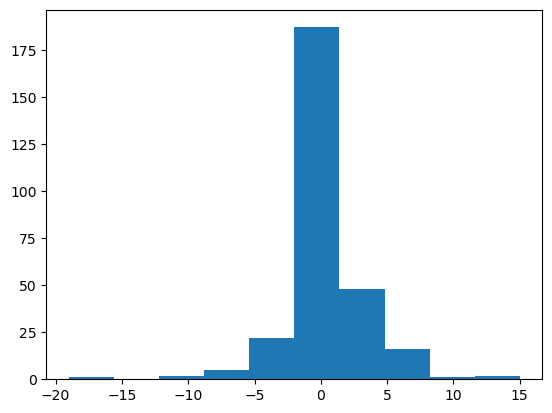

In [61]:
plt.hist(df_LAF['NumVar2'] - df_LAF['NumVar1'])

In [26]:
def convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, col_name):
    
    variant_differences_long = variant_differences.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Change'})

    variant_differences_long = variant_differences_long.merge(sample_1_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample1'}), on=['pid', col_name], how='left')

    variant_differences_long = variant_differences_long.merge(sample_2_variants.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample2'}), on=['pid', col_name], how='left')

    # remove variants that are absent at both timepoint 1 and 2. These are there because they are present in another sample
    variant_differences_long = variant_differences_long.query("~(Sample1==0 & Sample2==0)").reset_index(drop=True)

    # remove variants that are fixed everywhere
    variant_differences_long = variant_differences_long.query("~(Sample1 > @AF_max & Sample2 > @AF_max)").reset_index(drop=True)

    # I think these are suspicious also. Just problems with detection
    # variant_differences_long = variant_differences_long.query("Change >= -0.95 & Change <= 0.95").reset_index(drop=True)

    variant_differences_long['Abs_Change'] = np.abs(variant_differences_long['Change'])

    # variant_differences_long = variant_differences_long.query("Abs_Change >= 0.05").reset_index(drop=True)

    variant_differences_long[['POS', 'REF', 'ALT']] = variant_differences_long[col_name].str.split('_', n=3, expand=True)
    variant_differences_long['POS'] = variant_differences_long['POS'].astype(int)

    variant_differences_long['Region'] = variant_differences_long['POS'].map(h37Rv_coords_dict)

    # exclude it because it seems like the samples are not from the same person
    variant_differences_long = variant_differences_long.query("pid != 'T0245'").reset_index(drop=True)
    
    return variant_differences_long

In [27]:
variant_differences_long = convert_variant_differences_matrix_to_long(sample_1_variants, sample_2_variants, variant_differences, 'Variant')

len(variant_differences_long), variant_differences_long.Change.min(), variant_differences_long.Change.max()

(1830, -1.0, 1.0)

In [26]:
# SNV_differences_long = convert_variant_differences_matrix_to_long(sample_1_SNVs, sample_2_SNVs, SNV_differences, 'SNP')

# len(SNV_differences_long), SNV_differences_long.Change.min(), SNV_differences_long.Change.max()

7.80787212507815e-36


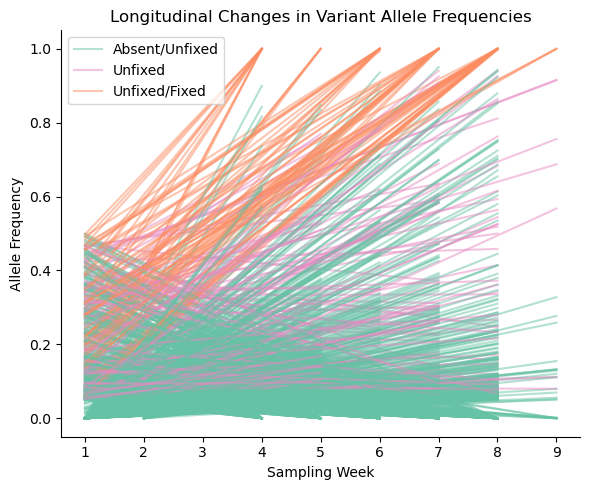

In [28]:
diff_min = 0.05
diff_max = 0.95

AF_min = 0.05

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

# enriched_genes = ['sugI', 'devR', 'phoR', 'devS', 'Rv1830', 'subI', 'ceoC', 'Rv2690c', 'virS', 'Rv1733c', 'NC_2516', 'NC_2982', 'NC_2568', 'NC_9']
df_plot = variant_differences_long.copy()#.query("Region in @enriched_genes") #variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 > @AF_max") #variant_differences_long.query("Sample1 != 0 & Sample2 != 0") #variant_differences_long.query("Sample1 != 0 & Sample2 != 0") # variant_differences_long.copy()#

df_plot = df_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_plot['Lineage'] = df_plot['Lineage'].astype(float).astype(int)

df_plot = df_plot.merge(df_longitudinal_pids[['pid', 'Sampling_Interval']].drop_duplicates())
df_plot = df_plot.merge(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: f"{min(x),max(x)}")), on='pid')
# df_plot = df_plot.query("Abs_Change >= @diff_min & Abs_Change <= @diff_max")

df_plot.loc[df_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_plot['Sample1']
df_plot.loc[df_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_plot.loc[df_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_plot['Sample2']
df_plot.loc[df_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_plot['Sample2']

df_plot['MinorAF_Change'] = df_plot['Sample2_MinorAF'] - df_plot['Sample1_MinorAF']

# df_plot.loc[df_plot[col_1] > df_plot[col_2], 'color'] = sns.color_palette("tab10").as_hex()[0]
# df_plot.loc[df_plot[col_2] > df_plot[col_1], 'color'] = sns.color_palette("tab10").as_hex()[1]

# absent to unfixed and vice versa
df_plot.loc[(df_plot[col_1] < 0.05) & (df_plot[col_2] >= 0.05) & (df_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']
df_plot.loc[(df_plot[col_2] < 0.05) & (df_plot[col_1] >= 0.05) & (df_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[0], 'Absent/Unfixed']

# unfixed to fixed and vice versa
df_plot.loc[(df_plot[col_1] > 0.95) & (df_plot[col_2] >= 0.05) & (df_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']
df_plot.loc[(df_plot[col_2] > 0.95) & (df_plot[col_1] >= 0.05) & (df_plot[col_1] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[1], 'Unfixed/Fixed']

# unfixed at both timepoints
df_plot.loc[(df_plot[col_1] >= 0.05) & (df_plot[col_1] <= 0.95) & (df_plot[col_2] >= 0.05) & (df_plot[col_2] <= 0.95), ['color', 'Group']] = [sns.color_palette("Set2").as_hex()[3], 'Unfixed']

# only unfixed variants at at least one timepoint. Exclude changes from absent to fixed and vice versa
df_plot = df_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")

stat, pval = st.ttest_rel(df_plot[col_1], 
                          df_plot[col_2], 
                          alternative='less'
                         )
print(pval)

plt.figure(figsize=(6, 5))

seen = set()

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_plot.iterrows():
    
    week_1, week_2 = row['Sampling_Week'].strip('(').strip(')').split(',')
    
    label = row['Group'] if row['Group'] not in seen else None
    
    plt.plot([int(week_1), int(week_2)], 
             [row[col_1], row[col_2]],
             color=row['color'],
             alpha=0.5,
             linewidth=1.5,
             label=label
            )
    
    seen.add(row['Group'])

# --- 2. Compute mean and 95% CI ---
means = [df_plot[col_1].mean(), df_plot[col_2].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_plot[col_1]) * st.t.ppf(0.975, len(df_plot)-1)
ci_fu = st.sem(df_plot[col_2]) * st.t.ppf(0.975, len(df_plot)-1)

cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

plt.legend()

# --- 5. Format axes ---
plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
plt.xlabel('Sampling Week')
plt.ylabel("Allele Frequency")
plt.tight_layout()
sns.despine()
plt.savefig("../results/figures/AF_changes_variants.svg")

df_plot = df_plot.merge(pd.DataFrame(df_plot.Region.value_counts()).rename(columns={'count': 'Region_total'}).reset_index())
df_plot['MinorAF_Change_Norm'] = df_plot['MinorAF_Change'] / df_plot['Region_total']

df_plot = df_plot.merge(pd.DataFrame(df_plot.pid.value_counts()).rename(columns={'count': 'pid_total'}).reset_index())
df_plot = df_plot.merge(pd.DataFrame(df_plot.query("MinorAF_Change > 0.5").pid.value_counts()).rename(columns={'count': 'pid_high_total'}).reset_index())
df_plot['prop_high_change_of_pid_total'] = df_plot['pid_high_total'] / df_plot['pid_total']

df_plot = df_plot.merge(pd.DataFrame(df_plot.query("MinorAF_Change > 0.5").Region.value_counts()).rename(columns={'count': 'Region_high_total'}).reset_index())
df_plot['prop_high_change_of_Region_total'] = df_plot['Region_high_total'] / df_plot['Region_total']

In [29]:
st.ttest_rel(df_plot[col_1], 
              df_plot[col_2], 
              alternative='less'
             ).pvalue

5.370441917612958e-52

<Axes: xlabel='MinorAF_Change', ylabel='Count'>

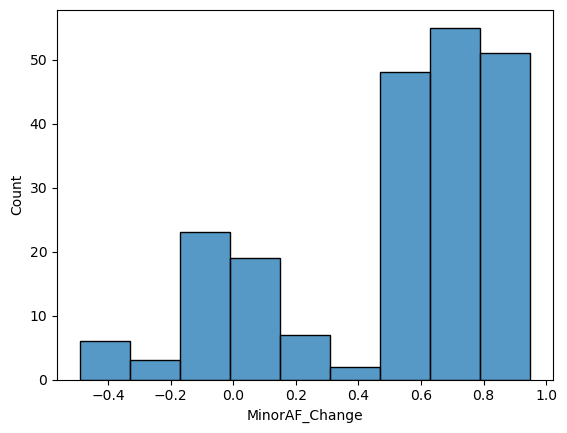

In [30]:
sns.histplot(data=df_plot,
             x='MinorAF_Change'
            )

In [255]:
pids_lots_of_changes = df_plot.query("prop_high_change_of_pid_total >= 0.5").pid.unique()

st.ttest_rel(df_plot.query("pid not in @pids_lots_of_changes")[col_1], 
              df_plot.query("pid not in @pids_lots_of_changes")[col_2], 
              alternative='less'
             ).pvalue

4.110616303006495e-34

In [259]:
df_plot.query("prop_high_change_of_pid_total >= 0.5").Lineage.value_counts()

Lineage
2    24
4    22
Name: count, dtype: int64

In [252]:
regions_high_changes = df_plot.query("prop_high_change_of_Region_total >= 0.5 & Region_total >= 0").Region.unique()

st.ttest_rel(df_plot.query("Region not in @regions_high_changes")[col_1], 
              df_plot.query("Region not in @regions_high_changes")[col_2], 
              alternative='less'
             ).pvalue

4.834018672242572e-09

In [246]:
df_plot.query("pid in ['T0200', 'T0220', 'T0428', 'T0249']")

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,...,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change,Region_total,MinorAF_Change_Norm,pid_total,pid_high_total,prop_high_change_of_pid_total,Region_high_total,prop_high_change_of_Region_total
15,T0249,852833_T_G,-0.852000,0.852000,0.000000,0.852000,852833,T,G,phoR,...,0.148000,1.000000,0.852000,11,0.077455,12,4,0.333333,3,0.272727
55,T0200,3717108_C_A,-0.718147,0.718147,0.000000,0.718147,3717108,C,A,sugI,...,0.281853,1.000000,0.718147,42,0.017099,2,1,0.500000,12,0.285714
56,T0220,3717108_C_A,-0.702341,0.702341,0.000000,0.702341,3717108,C,A,sugI,...,0.297659,1.000000,0.702341,42,0.016722,12,5,0.416667,12,0.285714
57,T0220,3717127_G_GC,-0.108000,0.108000,0.000000,0.108000,3717127,G,GC,sugI,...,0.108000,0.000000,-0.108000,42,-0.002571,12,5,0.416667,12,0.285714
60,T0249,3717219_C_T,-0.771357,0.771357,0.000000,0.771357,3717219,C,T,sugI,...,0.228643,1.000000,0.771357,42,0.018366,12,4,0.333333,12,0.285714
61,T0428,3717219_C_T,-0.854406,0.854406,0.000000,0.854406,3717219,C,T,sugI,...,0.145594,1.000000,0.854406,42,0.020343,6,2,0.333333,12,0.285714
109,T0220,1066251_C_T,-0.684211,0.684211,0.000000,0.684211,1066251,C,T,Rv0955,...,0.315789,1.000000,0.684211,2,0.342105,12,5,0.416667,1,0.500000
110,T0220,1860116_A_G,0.654596,0.000000,0.654596,0.654596,1860116,A,G,pheT,...,0.000000,0.654596,0.654596,1,0.654596,12,5,0.416667,1,1.000000
111,T0220,2588836_C_T,0.700280,0.000000,0.700280,0.700280,2588836,C,T,NC_1799,...,0.000000,0.700280,0.700280,1,0.700280,12,5,0.416667,1,1.000000
112,T0220,565681_A_AT,0.585499,0.097561,0.683060,0.585499,565681,A,AT,NC_380,...,0.097561,0.683060,0.585499,1,0.585499,12,5,0.416667,1,1.000000


In [248]:
df_trust_patients.query("pid=='T0220'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week,Paired_Sample_Num
713,T0220,S0220-01,MFS-129,MFS-129_lib47308,NaN,NaN,1.0,347.31,0.99,0.9883,...,NaN,0.009631,2.2.1.1,2.2.1.1.1,2,0.48,347.0,98.335794,1,1
714,T0220,S0220-08,MFS-130,MFS-130_lib47309,NaN,NaN,1.0,461.22,0.99,0.9862,...,NaN,0.011702,2.2.1.1,2.2.1.1.1,2,0.56,456.0,98.419415,8,2


In [241]:
df_plot.query("prop_high_change_of_Region_total >= 0.5").drop_duplicates(subset='Region').sort_values('prop_high_change_of_Region_total', ascending=False)

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,...,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change,Region_total,MinorAF_Change_Norm,pid_total,pid_high_total,prop_high_change_of_pid_total,Region_high_total,prop_high_change_of_Region_total
156,T0395,3436025_G_A,-0.701342,0.701342,0.000000,0.701342,3436025,G,A,Rv3072c,...,0.298658,1.000000,0.701342,1,0.701342,12,4,0.333333,1,1.0
166,T0447,562579_C_T,-0.531429,0.531429,0.000000,0.531429,562579,C,T,Rv0471c,...,0.468571,1.000000,0.531429,1,0.531429,13,6,0.461538,1,1.0
179,T0067,328743_C_G,-0.830460,0.830460,0.000000,0.830460,328743,C,G,Rv0272c,...,0.169540,1.000000,0.830460,1,0.830460,19,8,0.421053,1,1.0
178,T0067,295718_C_T,-0.940860,0.940860,0.000000,0.940860,295718,C,T,NC_196,...,0.059140,1.000000,0.940860,1,0.940860,19,8,0.421053,1,1.0
177,T0067,2605512_G_GC,-0.816901,0.816901,0.000000,0.816901,2605512,G,GC,mez,...,0.183099,1.000000,0.816901,1,0.816901,19,8,0.421053,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,T0447,4160566_CGGCATACCT_C,-0.166090,0.166090,0.000000,0.166090,4160566,CGGCATACCT,C,Rv3716c,...,0.166090,0.000000,-0.166090,2,-0.083045,13,6,0.461538,1,0.5
180,T0067,4339993_A_C,-0.804217,0.804217,0.000000,0.804217,4339993,A,C,Rv3863,...,0.195783,1.000000,0.804217,2,0.402108,19,8,0.421053,1,0.5
175,T0115,4265593_G_T,0.777409,0.222591,1.000000,0.777409,4265593,G,T,NC_2934,...,0.222591,1.000000,0.777409,2,0.388704,3,2,0.666667,1,0.5
174,T0115,1301452_C_T,-0.778571,0.778571,0.000000,0.778571,1301452,C,T,Rv1171,...,0.221429,1.000000,0.778571,2,0.389286,3,2,0.666667,1,0.5


In [207]:
df_plot.merge(df_trust_patients[['pid', 'Coll2014']].drop_duplicates()).to_csv("~/df_test_upload.csv", index=False)

In [265]:
# import statsmodels.formula.api as smf

# df must have:
# ΔAF, baseline_AF, region (categorical)

model = smf.ols(
    "MinorAF_Change ~ Sample1_MinorAF + C(pid)",
    data=df_plot
).fit()#cov_type="HC3")

# print(model.summary())

In [266]:
effects = model.params.filter(like="C(pid)")
ci = model.conf_int().loc[effects.index]

region_df = pd.DataFrame({
    "effect": effects,
    "lower": ci[0],
    "upper": ci[1],
    
}).sort_values("effect")

region_df = region_df.merge(pd.DataFrame(model.pvalues).rename(columns={0: 'pval'}), left_index=True, right_index=True)

region_df['Bonferroni_pval'] = region_df['pval'] * len(region_df)

In [268]:
region_df.sort_values('effect', ascending=False)

,effect,lower,upper,pval,Bonferroni_pval
C(pid)[T.T0257],0.246093,-0.798764,1.290951,0.642249,45.599657
C(pid)[T.T0018],0.231676,-0.813181,1.276534,0.661850,46.991367
C(pid)[T.T0428],0.223186,-0.676294,1.122667,0.624566,44.344208
C(pid)[T.T0280],0.211216,-0.820988,1.243420,0.686475,48.739757
C(pid)[T.T0368],0.199929,-0.830901,1.230760,0.702021,49.843490
...,...,...,...,...,...
C(pid)[T.T0052],-0.566760,-1.376506,0.242986,0.168668,11.975412
C(pid)[T.T0332],-0.585339,-1.434784,0.264107,0.175317,12.447502
C(pid)[T.T0402],-0.608578,-1.453231,0.236075,0.156571,11.116526
C(pid)[T.T0380],-0.609594,-1.430577,0.211390,0.144383,10.251188


In [262]:
region_df.query("Bonferroni_pval <= 0.1")

,effect,lower,upper,pval,Bonferroni_pval


In [189]:
test_genes = ['Rv2749', 'NC_196', 'Rv3604c', 'Rv3169', 'bacA']

df_plot.query("Region in @test_genes").MinorAF_Change.values

array([0.94387755, 0.92165899, 0.94086022, 0.91666667, 0.92405063])

In [286]:
# minor variants at baseline that rise to fixation
sweep_variants = df_plot.query("MinorAF_Change > 0.5 & Sample1_MinorAF == 0 | Sample2_MinorAF > 0.95")
nonsweep_variants = df_plot.query("~(MinorAF_Change > 0.5 & (Sample1_MinorAF == 0 | Sample2_MinorAF > 0.95))")

len(sweep_variants), len(nonsweep_variants), len(df_plot)

(137, 80, 217)

<Axes: xlabel='MinorAF_Change', ylabel='Count'>

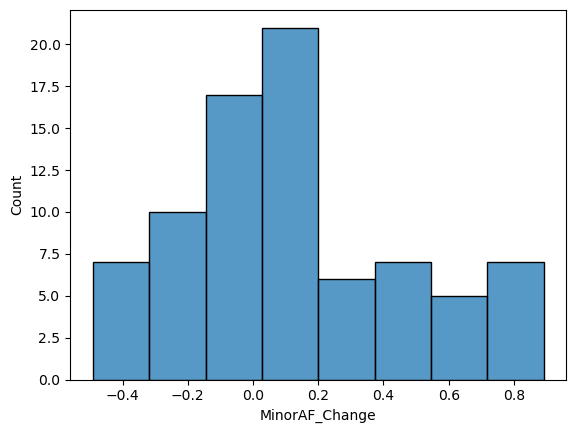

In [287]:
sns.histplot(data=nonsweep_variants,
             x='MinorAF_Change'
            )

In [288]:
st.ttest_rel(sweep_variants[col_1], 
              sweep_variants[col_2], 
              alternative='less'
             ).pvalue

3.1729532376532838e-105

In [289]:
st.ttest_rel(nonsweep_variants[col_1], 
              nonsweep_variants[col_2], 
              alternative='less'
             ).pvalue

0.001108136589688165

In [192]:
df_trust_patients.query("pid=='T0330'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week,Paired_Sample_Num
422,T0330,S0330-m5,MFS-660,MFS-660_lib66341,NaN,NaN,1.0,328.60,0.99,0.983,...,1.0,0.006470,4.1.1.1,4.1.i1.2.1,4,0.45,325.0,98.814856,20,3
423,T0330,S0330-08,MFS-396,MFS-396_lib59211,NaN,NaN,1.0,241.47,0.99,0.984,...,1.0,0.007382,4.1.1.1,4.1.i1.2.1,4,0.66,328.0,98.812929,8,2
424,T0330,S0330-01,MFS-395,MFS-395_lib59210,NaN,NaN,1.0,213.37,0.99,0.986,...,1.0,0.006105,4.1.1.1,4.1.i1.2.1,4,0.77,289.0,98.793934,1,1


In [190]:
df_plot.MinorAF_Change.max()

0.95

In [185]:
region_df.sort_values('effect', ascending=False)

,effect,lower,upper,pval,Bonferroni_pval
C(Region)[T.Rv2749],0.062422,-0.739533,0.864376,0.878443,770.394945
C(Region)[T.NC_196],0.061645,-0.740263,0.863553,0.879938,771.705792
C(Region)[T.Rv3604c],0.057316,-0.744343,0.858975,0.888278,779.019372
C(Region)[T.Rv3169],0.056700,-0.744925,0.858325,0.889466,780.061389
C(Region)[T.bacA],0.055414,-0.746142,0.856970,0.891947,782.237618
...,...,...,...,...,...
C(Region)[T.Rv3784],-1.035694,-1.836381,-0.235006,0.011376,9.976602
C(Region)[T.Rv0584],-1.038507,-1.839295,-0.237718,0.011167,9.793281
C(Region)[T.panC],-1.038828,-1.839628,-0.238027,0.011143,9.772593
C(Region)[T.vapB23],-1.041429,-1.842330,-0.240527,0.010954,9.606768


In [133]:
df_plot.query("MinorAF_Change > 0.5").groupby('Region')['MinorAF_Change_Norm'].mean().sort_values(ascending=False).head()

Region
Rv2749          0.943878
Rv3559c         0.943182
NC_196          0.940860
Rv2067c,cobI    0.935583
Rv3604c         0.924051
Name: MinorAF_Change_Norm, dtype: float64

In [137]:
df_plot.query("MinorAF_Change > 0.5 & Region=='NC_196'")

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,Lineage,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change,Total,MinorAF_Change_Norm
928,T0067,295718_C_T,-0.94086,0.94086,0.0,0.94086,295718,C,T,NC_196,2,0.05914,1.0,0.94086,1,0.94086


In [127]:
df_plot.query("MinorAF_Change > 0.5").sort_values('MinorAF_Change_Norm', ascending=False)

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,Lineage,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change,Total,MinorAF_Change_Norm
712,T0330,3062615_G_A,-0.943878,0.943878,0.000000,0.943878,3062615,G,A,Rv2749,4,0.056122,1.000000,0.943878,1,0.943878
714,T0330,4000199_C_T,0.943182,0.000000,0.943182,0.943182,4000199,C,T,Rv3559c,4,0.000000,0.943182,0.943182,1,0.943182
928,T0067,295718_C_T,-0.940860,0.940860,0.000000,0.940860,295718,C,T,NC_196,2,0.059140,1.000000,0.940860,1,0.940860
1095,T0018,2324661_G_A,0.935583,0.000000,0.935583,0.935583,2324661,G,A,"Rv2067c,cobI",2,0.000000,0.935583,0.935583,1,0.935583
1113,T0447,4046309_A_G,0.924051,0.075949,1.000000,0.924051,4046309,A,G,Rv3604c,2,0.075949,1.000000,0.924051,1,0.924051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,T0396,3717105_C_T,0.635689,0.126844,0.762533,0.635689,3717105,C,T,sugI,2,0.126844,0.762533,0.635689,42,0.015135
129,T0324,3717109_C_A,-0.612403,0.612403,0.000000,0.612403,3717109,C,A,sugI,2,0.387597,1.000000,0.612403,42,0.014581
109,T0214,3717219_C_A,-0.577982,0.577982,0.000000,0.577982,3717219,C,A,sugI,2,0.422018,1.000000,0.577982,42,0.013761
138,T0343,3717128_CCCTAT_C,0.531250,0.000000,0.531250,0.531250,3717128,CCCTAT,C,sugI,2,0.000000,0.531250,0.531250,42,0.012649


In [101]:
df_plot.query("pid=='T0245'")

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,Lineage,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change


In [97]:
st.ttest_rel(df_plot[col_1], 
                          df_plot[col_2], 
                          alternative='less'
                         ).pvalue

1.0402309692735258e-35

In [105]:
st.ttest_rel(df_plot.query("REF.str.len() == ALT.str.len()")[col_1],
             df_plot.query("REF.str.len() == ALT.str.len()")[col_2],
             alternative='less'
            ).pvalue

3.953902926013683e-31

In [ ]:
enriched_genes = 

# this means that the differences aren't driven by just the enriched genes. All genes are implicated
st.ttest_rel(df_plot.query("Region not in @enriched_genes")[col_1], 
                          df_plot.query("Region not in @enriched_genes")[col_2], 
                          alternative='less'
                         ).pvalue

1.3190432031050969e-34

In [491]:
df_plot.query("Region=='PE_PGRS62'")

,pid,Variant,Change,Sample1,Sample2,Abs_Change,POS,REF,ALT,Region,Lineage,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change
1061,T0338,4277184_C_T,0.740407,0.168067,0.908475,0.740407,4277184,C,T,PE_PGRS62,4,0.168067,0.908475,0.740407
1768,T0459,4277509_G_GC,-0.722814,0.722814,0.000000,0.722814,4277509,G,GC,PE_PGRS62,4,0.277186,1.000000,0.722814


<Axes: xlabel='MinorAF_Change', ylabel='Count'>

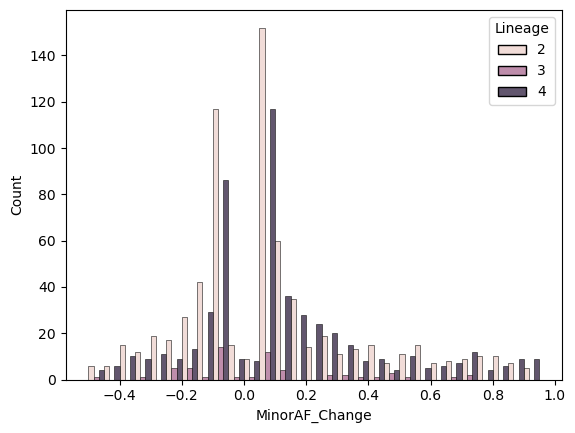

In [493]:
sns.histplot(data=df_plot,
             x='MinorAF_Change',
             hue='Lineage',
             multiple='dodge',
             common_norm=False
            )

In [37]:
AF_min = 0.05
AF_max = 0.95

# require at least one of the variants to be unfixed (BL or FU)
unfixed_variant_differences_long = variant_differences_long.query("(Sample1 >= @AF_min & Sample1 <= @AF_max) | (Sample2 >= @AF_min & Sample2 <= @AF_max)")

num_unfixed_to_fixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 > @AF_max"))

num_stay_unfixed = len(unfixed_variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_fixed_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 > @AF_max & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_absent_to_unfixed = len(unfixed_variant_differences_long.query("Sample1 <= @AF_min & Sample2 >= @AF_min & Sample2 <= @AF_max"))

num_unfixed_to_absent = len(unfixed_variant_differences_long.query("Sample2 <= @AF_min & Sample1 >= @AF_min & Sample1 <= @AF_max"))

num_absent_to_fixed = len(unfixed_variant_differences_long.query("Sample1 < @AF_min & Sample2 > @AF_max"))

print(f"{len(unfixed_variant_differences_long)} total")
print(f"    {num_absent_to_fixed} ({np.round(num_absent_to_fixed/len(unfixed_variant_differences_long), 4)}) absent to fixed")
print(f"    {num_absent_to_unfixed} ({np.round(num_absent_to_unfixed/len(unfixed_variant_differences_long), 4)}) absent to unfixed")
print(f"    {num_unfixed_to_fixed} ({np.round(num_unfixed_to_fixed/len(unfixed_variant_differences_long), 4)}) unfixed to fixed")
print(f"    {num_stay_unfixed} ({np.round(num_stay_unfixed/len(unfixed_variant_differences_long), 4)}) remain unfixed")
print(f"    {num_fixed_to_unfixed} ({np.round(num_fixed_to_unfixed/len(unfixed_variant_differences_long), 4)}) fixed to unfixed")
print(f"    {num_unfixed_to_absent} ({np.round(num_unfixed_to_absent/len(unfixed_variant_differences_long), 4)}) unfixed to absent")

1250 total
    0 (0.0) absent to fixed
    575 (0.46) absent to unfixed
    38 (0.0304) unfixed to fixed
    141 (0.1128) remain unfixed
    22 (0.0176) fixed to unfixed
    474 (0.3792) unfixed to absent


In [39]:
(575 + 474), (575 + 474)/len(unfixed_variant_differences_long)

(1049, 0.8392)

In [278]:
st.ttest_rel(df_LAF.query("pid != 'T0245'")['SASE1'],
             df_LAF.query("pid != 'T0245'")['SASE2'],
             alternative='less'
            )

TtestResult(statistic=-1.569940764871306, pvalue=0.05877313298734433, df=283)

In [134]:
variant_differences_long['Sample1_midpoint_norm'] = np.abs(variant_differences_long['Sample1'] - 0.5)
variant_differences_long['Sample2_midpoint_norm'] = np.abs(variant_differences_long['Sample2'] - 0.5)

variant_differences_long['Change_midpoint_norm'] = variant_differences_long['Sample2_midpoint_norm'] - variant_differences_long['Sample1_midpoint_norm']

In [145]:
st.ttest_rel(variant_differences_long['Sample1_midpoint_norm'],
             variant_differences_long['Sample2_midpoint_norm'],
             alternative='greater'
            )

TtestResult(statistic=1.8395984271727297, pvalue=0.03303043281285631, df=1268)

In [143]:
variant_differences_long['Change_midpoint_norm'].mean()

-0.010546121885403494

In [152]:
st.ttest_rel(variant_differences_long.query("Sample1 != 0 & Sample2 != 0")['Sample1_midpoint_norm'],
             variant_differences_long.query("Sample1 != 0 & Sample2 != 0")['Sample2_midpoint_norm'],
             alternative='greater'
            )

TtestResult(statistic=0.45362121233732094, pvalue=0.3252991310825559, df=198)

In [119]:
df_longitudinal_pids.query("pid=='T0009'")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,...,p_val_wsrst,abs_diff,mix_index,mix_node,mix_phylotype,mix_prop,failed,mix_phylotypes,mix_props,Sampling_Interval
10,T0009,S0009-01,MFS-334,1,NaN,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,...,-1.0,inf,1,157,4.1.2.1,1.0,False,4.1.2.1,1.0,7
11,T0009,S0009-08,MFS-335,8,NaN,4.1.2.1,4.1.i1.1.1.1,haarlem,NaN,4.1.2/Haarlem,...,-1.0,inf,1,157,4.1.2.1,1.0,False,4.1.2.1,1.0,7


In [296]:
num_sites_thresh = 0

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

284 pids have ≥ 0 unfixed sites at both timepoints
SASE change: 0.05877313298734433
SE change: 0.06778301940798238
Number of sites change: 0.04307788471538511


In [301]:
df_check.NumVar1.mean(), df_check.NumVar2.mean(), df_check.NumVarDiff.mean()

(2.306338028169014, 2.630281690140845, 0.323943661971831)

In [298]:
# diff_min = 0.05
# diff_max = 0.95

# col_1 = 'NumVar1'
# col_2 = 'NumVar2'

# df_plot = df_check.copy()

# # df = unfixed_SNVs_wide.query("Abs_Diff >= @diff_min & Abs_Diff <= @diff_max").query("Region in @enriched_genes")
# stat, pval = st.ttest_rel(df_plot[col_1], 
#                           df_plot[col_2], 
#                           alternative='less'
#                          )
# print(pval)

# plt.figure(figsize=(6, 5))

# # --- 1. Plot all individual paired lines (light gray) ---
# for _, row in df_plot.iterrows():
#     plt.plot([0, 1], [row[col_1], row[col_2]],
#              color="lightgray",
#              alpha=0.4,
#              linewidth=1
#             )

# # --- 2. Compute mean and 95% CI ---
# means = [df_plot[col_1].mean(), df_plot[col_2].mean()]

# # 95% CI using t distribution
# ci_bl = st.sem(df_plot[col_1]) * st.t.ppf(0.975, len(df_plot)-1)
# ci_fu = st.sem(df_plot[col_2]) * st.t.ppf(0.975, len(df_plot)-1)

# cis = [ci_bl, ci_fu]

# # --- 3. Overlay mean line in blue ---
# plt.plot([0, 1], means, linewidth=2)

# # --- 4. Add 95% CI error bars ---
# plt.errorbar([0, 1], means, yerr=cis,
#              fmt='none',
#              capsize=4,
#              linewidth=2)

# # --- 5. Format axes ---
# plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
# plt.xticks([0, 1], ["Baseline", "Follow-Up"])
# plt.ylabel("Allele Frequency")
# plt.tight_layout()
# sns.despine()
# # plt.savefig("../results/figures/AF_changes_in_enriched_genes.svg")


In [304]:
num_sites_thresh = 1

alt = 'two-sided'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

164 pids have ≥ 1 unfixed sites at both timepoints
SASE change: 0.9044406960654924
SE change: 0.10246768641039197
Number of sites change: 0.08178106871644408


In [288]:
num_sites_thresh = 2

alt = 'less'

df_check = df_LAF.query("NumVar1 >= @num_sites_thresh & NumVar2 >= @num_sites_thresh & pid != 'T0245'")

num_keep = len(df_check)

sase_pval = st.ttest_rel(df_check['SASE1'],
                         df_check['SASE2'],
                        alternative=alt
                       ).pvalue

se_pval = st.ttest_rel(df_check['SE1'],
                       df_check['SE2'],
                      alternative=alt
                      ).pvalue

num_sites_pval = st.ttest_rel(df_check['NumVar1'],
                              df_check['NumVar2'],
                             alternative=alt
                            ).pvalue

print(f"{num_keep} pids have ≥ {num_sites_thresh} unfixed sites at both timepoints")
print(f"SASE change: {sase_pval}")
print(f"SE change: {se_pval}")
print(f"Number of sites change: {num_sites_pval}")

90 pids have ≥ 2 unfixed sites at both timepoints
SASE change: 0.6324769018346516
SE change: 0.11580978035211321
Number of sites change: 0.10154961504258302


# Analyze Site Turnover

In [223]:
df_compare_variants_timepoints = df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==1")[['pid', 'POS']].merge(df_lowAF_variants.query("pid != 'T0245'").query("Paired_Sample_Num==2")[['pid', 'POS']], how='outer', on=['pid', 'POS'], indicator=True)

sample_1_only = df_compare_variants_timepoints.query("_merge=='left_only'")
sample_2_only = df_compare_variants_timepoints.query("_merge=='right_only'")
overlap = df_compare_variants_timepoints.query("_merge=='both'")
union = df_compare_variants_timepoints.copy()
              
# print(f"Sample 1: {len(sample_1_sites)}")
# print(f"Sample 2: {len(sample_2_sites)}")
print(f"Overlap: {len(overlap)} ({len(overlap) / len(union)})")
print(f"Sample 1 ONLY: {len(sample_1_only)} ({len(sample_1_only) / len(union)})")
print(f"Sample 2 ONLY: {len(sample_2_only)} ({len(sample_2_only) / len(union)})")

Overlap: 121 (0.11172668513388735)
Sample 1 ONLY: 434 (0.4007386888273315)
Sample 2 ONLY: 528 (0.48753462603878117)


In [227]:
df_longitudinal_pids.query("pid != 'T0245' & pid in @pids_with_same_lineage_and_low_F2").drop_duplicates(subset='pid').Sampling_Interval.mean()

5.496478873239437

In [116]:
# lineage_col = 'Coll2014'

# for lineage in df_LAF[lineage_col].unique():
    
#     num_isolates = len(df_LAF.query(f"{lineage_col}==@lineage & ~(SASE1 == 0 & SASE2 == 0)"))
    
#     if num_isolates > 1:
    
#         increase_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='greater'
#                                    ).pvalue
        
#         decrease_pval = st.wilcoxon(df_LAF.query(f"{lineage_col}==@lineage")['SASE2'],
#                                     df_LAF.query(f"{lineage_col}==@lineage")['SASE1'],
#                                     alternative='less'
#                                    ).pvalue

#         if increase_pval <= 0.05:
#             print(f"L{lineage} increase: p = {np.round(increase_pval, 2)}, N = {num_isolates}")
            
#         if decrease_pval <= 0.05:
#             print(f"L{lineage} decrease: p = {np.round(decrease_pval, 2)}, N = {num_isolates}")

In [117]:
# lineage_order = df_LAF.groupby('Coll2014')['SASE_Diff'].mean().sort_values().index.values

# fig, ax = plt.subplots(figsize=(10, 6))

# sns.stripplot(data=df_LAF,
#                 x='SASE_Diff',
#              y='Coll2014',
#              # multiple='dodge',
#              # common_norm=False,
#              palette='tab20',
#               order=lineage_order,
#               edgecolor='black',
#               linewidth=0.5,
#               ax=ax
#                )

# # plt.title('Difference in SASE between Follow-Up and Baseline')
# plt.xlabel('Difference in SASE')

# sns.despine()
# # plt.savefig("../results/figures/SASE_diff_by_lineage.svg", bbox_inches='tight')

# Nucleotide Diversity and Estimated Population Size Calculations

In [ ]:
# df_exclude = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/references/BED_files/exclude_regions_50bp.EBRlessThan95Percent.bed", sep='\t', header=None)

# excluded_sites = []

# for i, row in df_exclude.iterrows():
#     excluded_sites += list(np.arange(row[1] + 1, row[2] + 1))
    
# # also excluded [2337869, 2340874], inclusive
# excluded_sites += list(np.arange(2337869, 2340874 + 1))

# excluded_sites = np.unique(excluded_sites)

# num_total_sites = len(h37Rv_seq) - len(excluded_sites)

In [153]:
# def compute_nucleotide_diversity_Ne(pid, mutation_rate=5e-8):
    
#     # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
#     df_sample_1 = pd.DataFrame(sample_1_SNVs.loc[pid]).rename(columns={pid: 'Sample1'})
#     df_sample_2 = pd.DataFrame(sample_2_SNVs.loc[pid]).rename(columns={pid: 'Sample2'})

#     df_sample_1['Sample1_Inv'] = 1 - df_sample_1['Sample1']
#     df_sample_2['Sample2_Inv'] = 1 - df_sample_2['Sample2']

#     ND_1 = np.sum(2 * df_sample_1.product(axis=1)) / len(df_sample_1)
#     ND_2 = np.sum(2 * df_sample_2.product(axis=1)) / len(df_sample_2)

#     Ne_1 = ND_1 / (2 * mutation_rate)
#     Ne_2 = ND_2 / (2 * mutation_rate)

#     return pd.DataFrame({'pid': pid, 'ND_1': ND_1, 'ND_2': ND_2, 'Ne_1': Ne_1, 'Ne_2': Ne_2}, index=[0])

In [154]:
# df_population_sizes = []

# for pid in df_longitudinal_pids.pid.unique():
#     df_population_sizes.append(compute_nucleotide_diversity_Ne(pid))
    
# df_population_sizes = pd.concat(df_population_sizes)

# print(np.round(df_population_sizes[['Ne_1', 'Ne_2']].max().max()))

# df_population_sizes = df_population_sizes.merge(df_longitudinal_pids[['pid', 'Paired_Sample_Num', 'F2']].pivot(index='pid', columns='Paired_Sample_Num', values='F2').rename(columns={1: 'F2_1', 2: 'F2_2'}).reset_index())

In [155]:
# sns.scatterplot(data=df_population_sizes.query("pid in @pids_with_low_F2"),
#                 x='Ne_1',
#                 y='Ne_2'
#                )

# plt.xscale('log')
# plt.yscale('log')

# sns.despine()

# Associate diversity metrics with outcomes

In [22]:
import sys
sys.path.append(os.path.join(os.getcwd(), "scripts"))
from epi_utils import *


In [25]:
def read_combine_all_TRUST_data(df_trust_patients, drug_lineage_inclusion_dict, CNN_results_dir=None, F2_thresh=0.03, baseline_only=True):
    '''
    This function keeps only measured MICs and WGS samples taken in the first two weeks of treatment because we are interested in associating baseline characteristics with outcome.
    '''

    ############################################# STEP 1: READ IN THE COMBINED PATIENT-WGS DATAFRAME #############################################


#     # remove reenrollments. They were already removed from the outcomes table, but do it here to get accurate counts of included/excluded participants
#     df_trust_patients = df_trust_patients.loc[pd.isnull(df_trust_patients['screen_prevpid'])]
    
#     print(f"{df_trust_patients.pid.nunique()} patients with any WGS samples")

    # fix lineages. Sometimes the names got converted to integers for the single number lineages
    for i, row in df_trust_patients.iterrows():
        if not pd.isnull(row['Lineage']):
            if type(row['Lineage']) != str:
                df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
    
    df_trust_patients['Lineage'] = df_trust_patients['Lineage'].astype(str)
    df_trust_patients['Lineage'] = df_trust_patients['Lineage'].replace('nan', np.nan)

    # keep only WGS samples that were not contaminated. Low sequencing depth isn't an issue here, they were all sequenced to very high depths
    df_trust_patients = df_trust_patients.dropna(subset='F2').reset_index(drop=True)
    
    print(f"{df_trust_patients.pid.nunique()} patients with uncontaminated WGS samples")

    
    ######################################### STEP 2: KEEP ONLY SEQUENCES COLLECTED IN THE FIRST 2 WEEKS ##############################################


    # get the sample week
    df_trust_patients['Sampling_Week'] = df_trust_patients['Original_ID'].str.split('-').str[1]
    
    # replace month 5 with 20 for weeks
    df_trust_patients['Sampling_Week'] = df_trust_patients['Sampling_Week'].replace('01A', '01').replace('m5', '20').replace('M5', '20').replace('PM12', '72')
    
    df_trust_patients['Sampling_Week'] = df_trust_patients['Sampling_Week'].astype(int)
    
    # keep only WGS samples collected in the first 2 weeks
    if baseline_only:
        df_trust_patients = df_trust_patients.query("Sampling_Week <= 2").reset_index(drop=True)
    
        print(f"{df_trust_patients.pid.nunique()} patients with uncontaminated WGS samples taken in the first 2 weeks\n")

    
    ###################################################### STEP 3: ADD LINEAGE ANNOTATIONS ######################################################

    
    # add additional lineage information on mixed infections and primary lineage group
    df_trust_patients['mixed_infect'] = (df_trust_patients['F2'] > F2_thresh).astype(int)

    df_trust_patients.loc[pd.isnull(df_trust_patients['F2']), 'mixed_infect'] = np.nan
    
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['1', '3', '1,3']), 'L1_L3'] = 1
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['2', '4', '2,4']), 'L1_L3'] = 0
    df_trust_patients.loc[df_trust_patients['Lineage'].isin(['1,2', '2,3', '3,4']), 'L1_L3'] = 0.5
    
    df_trust_patients.loc[pd.isnull(df_trust_patients['Lineage']), 'L1_L3'] = np.nan

    
    ###################################################### STEP 4: REMOVE PATIENTS WITH SEQUENCING AT THE SAME TIMEPOINT WITH DIFFERENT LINEAGES ###########################
    

    pids_multiple_sequences_same_timepoint = df_trust_patients.iloc[df_trust_patients.index.values[df_trust_patients.duplicated('Original_ID', keep=False)]].pid.unique()

    pids_multiple_sequences_same_timepoint_discordant_lineages = pd.DataFrame(df_trust_patients.groupby(['pid', 'Original_ID'])['Coll2014'].nunique()).query("Coll2014 > 1").reset_index().pid.values
    
    print(f"{len(pids_multiple_sequences_same_timepoint)} patients: {pids_multiple_sequences_same_timepoint} have multiple sequences at the same timepoint")
    
    # print(f"Removing {len(pids_multiple_sequences_same_timepoint_discordant_lineages)} patients: {pids_multiple_sequences_same_timepoint_discordant_lineages} because there are multiple WGS samples at the same timepoint with different lineages")

    # df_trust_patients = df_trust_patients.query("pid not in @pids_multiple_sequences_same_timepoint_discordant_lineages")
    
    
    ###################################################### STEP 5: READ IN ALL AVAILABLE MEASURED MICS ######################################################

    
    TRUST_phenos = []
    
    for drug in drugs_lst:
        
        # this contains all WGS runs, so keep only the unique pids for counting/plotting purposes
        # all MICs here were converted to MGIT. The only drug for which that makes any difference is INH, whose MGIT (0.1) and 7H10 (0.2) critical concentrations are different.
        df_single_drug = get_all_available_MICs_single_drug(df_trust_patients, drug, baseline_only=baseline_only)
        df_single_drug = df_single_drug[['pid', drug, f"{drug}_method"]]
        
        print(f"{len(df_single_drug)} patients have MICs for {drug}")
        TRUST_phenos.append(df_single_drug)
    
    TRUST_phenos = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), TRUST_phenos).drop_duplicates()
    
    for drug in drugs_lst:
        if drug in TRUST_phenos.columns:
            TRUST_phenos = convert_categorical_to_actual_MICs(TRUST_phenos, drug, MIC_encoding_dicts[drug])

    if baseline_only:
        print(f"{TRUST_phenos.pid.nunique()} patients have measured MICs in the first 2 weeks\n")
    else:
        print(f"{TRUST_phenos.pid.nunique()} patients have measured MICs\n")

    
    #################################################### STEP 6: READ IN ALL AVAILABLE PREDICTED MICS #########################################################

    
    if CNN_results_dir is not None:
        
        TRUST_phenos = []

        for drug in drugs_lst:

            # which models to use for each drug
            assert drug_lineage_inclusion_dict[drug] in ['lineage_amino_acid', 'amino_acid']
            df_pred = pd.read_csv(os.path.join(CNN_results_dir, f"{drug}_{drug_lineage_inclusion_dict[drug]}", "TRUST", "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'SampleID', 'pred_MIC': f'{drug}_pred_MIC'})

            # drop patient duplicates (because multiple WGS samples per pid)
            df_pred = df_pred.merge(df_trust_patients[['SampleID', 'Original_ID', 'pid']]).sort_values(['pid', 'Original_ID']).drop_duplicates('pid', keep='first').reset_index(drop=True)

            print(f"Found predicted {drug} MICs for {len(df_pred)} pids")

            TRUST_phenos.append(df_pred[['pid', f'{drug}_pred_MIC']])

        TRUST_phenos = reduce(lambda left, right: pd.merge(left, right, on='pid', how='outer'), TRUST_phenos)
        print(f"{TRUST_phenos.pid.nunique()} patients have predicted MICs")

        # these should have all the same patients because the predicted MICs come from the high-quality WGS samples 
        assert len(set(df_trust_patients.pid).symmetric_difference(TRUST_phenos.pid)) == 0

        # categorical variable for this, interesting to look at by plotting
        df_trust_patients.loc[(df_trust_patients['bl_hiv']==0), 'HIV_CD4'] = 0
        df_trust_patients.loc[(df_trust_patients['bl_hiv']==1) & (df_trust_patients['bl_cd4'] >= 200), 'HIV_CD4'] = 1
        df_trust_patients.loc[(df_trust_patients['bl_hiv']==1) & (df_trust_patients['bl_cd4'] < 200), 'HIV_CD4'] = 2

    if CNN_results_dir is not None:
        return df_trust_patients, TRUST_phenos, TRUST_phenos
    else:
        return df_trust_patients, TRUST_phenos

In [26]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            'high_lung_involvement',
            # 'human_PLI',
            # 'high_lung_involvement',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]

PLI_thresh = 20

stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'screen_sex', 'underweight']#, 'high_lung_involvement'
# stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'smoked_substance_use', 'screen_sex', 'underweight']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

df_TCC = df_imputed_TCC.query("imp_num==0").reset_index(drop=True)
df_imputed_TCC = df_imputed_TCC.query("imp_num > 0").reset_index(drop=True)

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

# this includes TTP, PK AUC, and CXR data merged in
df_processed_patients = pd.read_csv(f"{TRUST_data_dir}/20251126_cleaned_patient_outcomes_data.csv")

df_pids_for_outcomes_model, TRUST_phenos = read_combine_all_TRUST_data(df_processed_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir=None,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_longitudinal_pids.pid").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid").drop_duplicates(subset='pid').reset_index(drop=True)

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @pids_with_same_lineage_and_low_F2").drop_duplicates(subset='pid').reset_index(drop=True)
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.drop_duplicates(subset='pid').reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_baseline_samples.pid & Sampling_Week <= 2")
df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)
df_pids_for_outcomes_model['MixedInfect'] = (df_pids_for_outcomes_model['F2'] > F2_max).astype(int)
df_pids_for_outcomes_model['High_TTP'] = (df_pids_for_outcomes_model['TTP_baseline'] > 300).astype(int)

age_thresh = 50
df_pids_for_outcomes_model['advanced_age'] = (df_pids_for_outcomes_model['screen_years'] > age_thresh).astype(int)
df_pids_for_outcomes_model['Age_Squared'] = df_pids_for_outcomes_model['screen_years']**2

del df_pids_for_outcomes_model['predicted_PLI']
# df_PLI = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")
df_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/CXR_predictions.csv").query("Status=='Normal' & Time=='BL' & View=='PA'").sort_values(['pid', 'predicted_PLI']).drop_duplicates('pid', keep='first')
df_human_PLI = pd.read_csv("~/TRUST_data_processing/processed_data/20260421_human_PLI_reads.csv").query("Time=='BL'").reset_index(drop=True)

df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_PLI[['pid', 'predicted_PLI']], on='pid', how='left')
# df_pids_for_outcomes_model = df_pids_for_outcomes_model.merge(df_human_PLI[['pid', 'human_PLI']].rename(columns={'human_PLI': 'predicted_PLI'}), on='pid', how='left')

df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'] = df_pids_for_outcomes_model['cxr_cavity_chest_radiograph_1'].replace(2, np.nan)

# df_pids_for_outcomes_model['inv_adherence_rate_by_observed'] = 1 - df_pids_for_outcomes_model['adherence_rate_by_observed']

# df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("Sampling_Week <= 2")
df_pids_for_outcomes_model = df_pids_for_outcomes_model.sort_values(['pid', 'Original_ID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True)

if 'high_lung_involvement' in cols_lst:
    df_pids_for_outcomes_model = df_pids_for_outcomes_model.dropna(subset='predicted_PLI')
    df_pids_for_outcomes_model['high_lung_involvement'] = (df_pids_for_outcomes_model['predicted_PLI'] > PLI_thresh).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

8 patients: ['T0402' 'T0206' 'T0128' 'T0042' 'T0404' 'T0032' 'T0403' 'T0170'] have multiple sequences at the same timepoint
403 patients have MICs for RIF
403 patients have MICs for INH
403 patients have MICs for EMB
282 patients have MICs for PZA
398 patients have measured MICs in the first 2 weeks



(342, 342)

In [158]:
df_imputed_TCC.query("pid in @df_pids_for_outcomes_model.pid").pid.nunique()

302

<Axes: xlabel='human_PLI', ylabel='Count'>

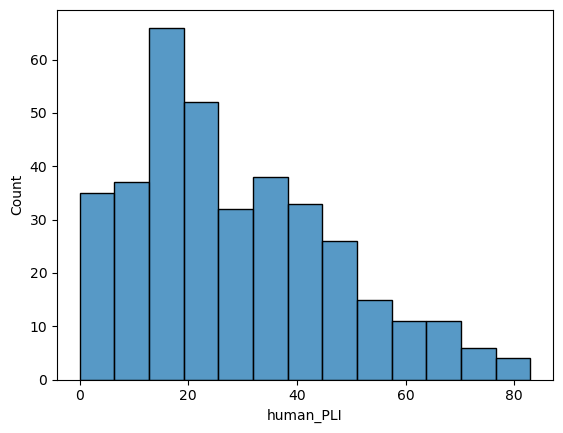

In [87]:
sns.histplot(data=df_pids_for_outcomes_model,
             x='human_PLI',
            )

<Axes: xlabel='predicted_PLI', ylabel='Count'>

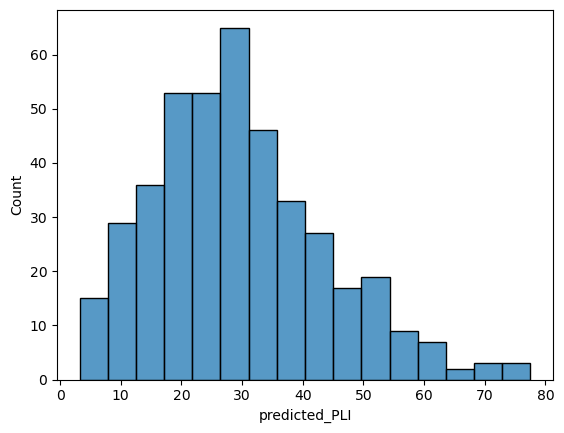

In [159]:
sns.histplot(data=df_PLI,
             x='predicted_PLI',
            )

In [43]:
df_PLI_old = pd.read_csv("~/MtbQuantCNN/analysis/TRUST/processed_data/PLI_Timika_predictions.csv")

<Axes: xlabel='predicted_PLI', ylabel='Count'>

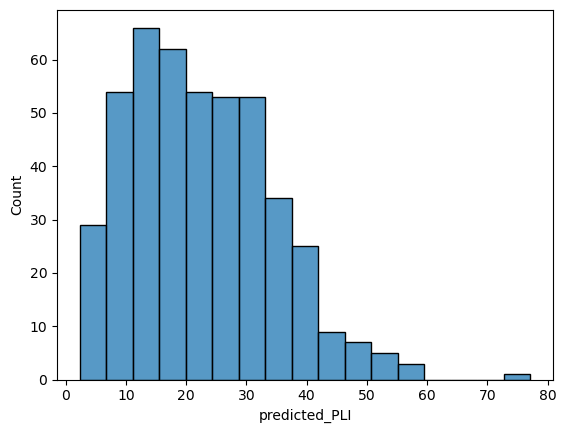

In [44]:
sns.histplot(data=df_PLI_old,
             x='predicted_PLI',
            )

In [160]:
df_pids_for_outcomes_model['predicted_PLI'].median(), np.percentile(df_pids_for_outcomes_model['predicted_PLI'].dropna(), 75)

(28.952775, 37.228258749999995)

In [88]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Predicted % Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               'human_PLI': 'Human-Read PLI'
             }

In [38]:
df_pids_for_outcomes_model['adherence_rate_by_observed'].mean(), df_pids_for_outcomes_model['adherence_rate_by_observed'].median()

(0.7341972046627192, 0.837722337722338)

In [39]:
# df_processed_patients = pd.read_csv(f"/home/sak0914/TRUST_data_processing/processed_data/.snapshot/o2_home_2025-11-24_17_15_04_UTC/20251111_cleaned_patient_outcomes_data.csv")
# df_processed_patients['screen_sex'] = df_processed_patients['screen_sex'].replace(2, 0)
# df_processed_patients.to_csv(f"/home/sak0914/TRUST_data_processing/processed_data/20251111_cleaned_patient_outcomes_data.csv", index=False)

In [41]:
cols_lst

['screen_sex',
 'screen_years',
 'underweight',
 'fstrom1_baseline',
 'HIV_CD4',
 'bl_prevtb',
 'TTP_baseline',
 'smear_pos_no_contam_sputum_specimen_1',
 'diabetes',
 'human_PLI']

In [172]:
df_test_results, df_model_processed, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  TRUST_phenos,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True,
                                                                                             PLI_thresh=PLI_thresh
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

print(len(df_violating_covariates.query("p <= 0.05")))

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# df_test_results.to_csv("../results/TCC/Cox_model_results.csv", index=False)

    323 total pids
4


In [176]:
PLI_thresh

25

In [177]:
df_test_results[['covariate', 'pval', 'HR_TCC_assoc', 'HR_TCC_assoc_lower', 'HR_TCC_assoc_upper']].sort_values('pval')

,covariate,pval,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
0,TTP_baseline,0.000063,0.268417,0.142835,0.504413
5,screen_years,0.000715,1.296810,1.118008,1.504206
4,high_lung_involvement,0.122510,1.303535,0.930432,1.826253
2,diabetes,0.163753,0.599277,0.290926,1.234447
3,fstrom1_baseline,0.273625,0.815968,0.566203,1.175910
1,bl_prevtb,0.992472,1.001696,0.703087,1.427128


In [178]:
df_violating_covariates.query("p <= 0.05")

,covariate,p,imp_num
1,bl_prevtb,0.033608,3
1,bl_prevtb,0.034805,7
1,bl_prevtb,0.033092,12
5,screen_years,0.045078,29


In [433]:
len(df_tx_outcomes.query("esp_reason_end_of_study_parti==7"))

31

In [434]:
len(df_tx_outcomes.loc[pd.isnull(df_tx_outcomes['esp_reason_end_of_study_parti'])])

11

In [233]:
df_tx_outcomes.query("event==1 & TB_death==0")

,pid,date,event_type,to_studyto_treatment_outcome,esp_reason_end_of_study_parti,esp_reasonoth_end_of_study_parti,esp_date_end_of_study_parti,waiver_reason_end_of_study_parti,esp_cod_end_of_study_parti,waiver_deathcause_end_of_study_parti,TB_death,event,screen_date,event_date,censor_date,time_in_trial,weeks,months,imp_num
3,T0046,304.0,death,1.0,8.0,NaN,2018-12-05,4.0,Probably cancer of oesophagus. (According to f...,Esophageal cancer,0.0,1,2018-01-16,2018-11-16,NaN,323.0,43.428571,10.133333,1
5,T0051,481.0,death,1.0,8.0,NaN,2019-06-13,4.0,Cancer,Cancer,0.0,1,2018-02-09,2019-06-05,NaN,489.0,68.714286,16.033333,1
20,T0182,53.0,death,6.0,8.0,NaN,2019-10-09,4.0,Car accident,Car accident,0.0,1,2019-08-14,2019-10-06,NaN,56.0,7.571429,1.766667,1
22,T0197,350.0,death,1.0,8.0,NaN,2020-10-22,4.0,Cardiovascular Accident,Heart attack,0.0,1,2019-10-03,2020-09-17,NaN,385.0,50.000000,11.666667,1
43,T0399,217.0,death,1.0,8.0,NaN,2023-09-29,4.0,"Unknown, participant was referred for psycholo...",Lung cancer,0.0,1,2023-02-17,2023-09-22,NaN,224.0,31.000000,7.233333,1


In [236]:
len(df_tx_outcomes.query("pid in @df_model_processed.pid"))

340

In [237]:
df_tx_outcomes.query("pid in @df_model_processed.pid").time_in_trial.median(), df_tx_outcomes.query("pid in @df_model_processed.pid").time_in_trial.max()

(546.0, 835.0)

In [435]:
df_TCC.query("pid in @df_pids_for_outcomes_model.pid").culture_convert.sum(), df_TCC.query("pid in @df_pids_for_outcomes_model.pid").culture_convert.mean()

(214, 0.6504559270516718)

In [437]:
OR_col = 'HR_TCC_assoc'
df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
0,0.000112,TTP_baseline,0.132990,0.260196,0.509073
4,0.001396,screen_years,1.100702,1.276638,1.480696


In [48]:
covariates_order = list(df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values)

forest_plot(df_test_results, 
            df_test_results.sort_values(['pval', OR_col], ascending=[True, False]).covariate.values,
            labels_dict, 
            val_col='HR_TCC_assoc',
            alpha=0.05, 
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot.svg"
           )

In [53]:
diversity_metric = 'NumVar1'
binarize = False
thresh = 0.1

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric, 'grouped_variant']])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)
    
    median_val = df_add_metric_for_model[diversity_metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                           cols_lst + [diversity_metric],
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True,
                                                                 PLI_thresh=PLI_thresh
                                                             )

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'

df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

# convert to HR per 5 variants
df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results_diversity.loc[df_test_results_diversity['covariate']=='NumVar1', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**5

    323 total pids


In [54]:
df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
1,0.000094,TTP_baseline,0.147444,0.277312,0.521567
6,0.000273,screen_years,1.139047,1.319115,1.527649


In [57]:
df_test_results_diversity.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,HR_TCC_assoc_lower,HR_TCC_assoc,HR_TCC_assoc_upper
1,0.000199,TTP_baseline,0.156798,0.295615,0.557332
5,0.002874,screen_years,1.085352,1.265649,1.475897


In [56]:
forest_plot(df_test_results_diversity, 
            ['NumVar1'] + covariates_order,
            labels_dict,
            val_col='HR_TCC_assoc', 
            alpha=0.05,
            log=False, 
            pval_offset=1.05, 
            df_stratify_variables_results=None, 
            saveName="../results/figures/TCC/forest_plot_with_diversity.svg"
           )

df_test_results_diversity.to_csv("../results/TCC/Cox_model_results_with_diversity.csv", index=False)

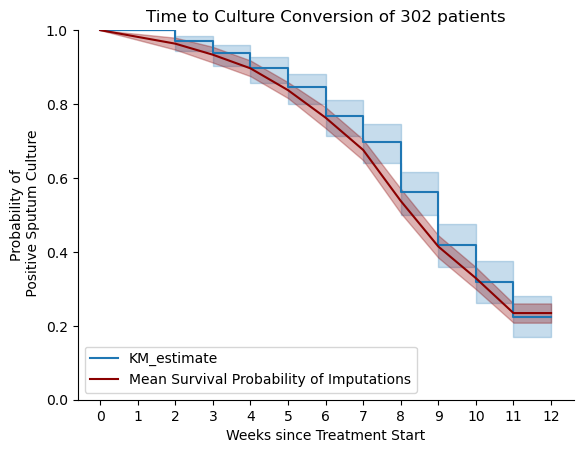

In [59]:
pids_with_TCC = df_model_processed[0].pid.unique()
df_imputed_TCC = df_imputed_TCC.query("pid in @pids_with_TCC")

median_survival_imputations = {}

# Prepare a list to collect survival functions from each imputation
survival_curves = []

# Fit Kaplan-Meier for each imputation and store survival function
for imp in df_imputed_TCC['imp_num'].unique():
    
    if imp > 0:
        imputed_data = df_imputed_TCC.query("imp_num==@imp")

        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(durations=imputed_data['TCC'], event_observed=imputed_data['culture_convert'])

        survival_curves.append(kmf.survival_function_.rename(columns={"KM_estimate": f"imp_{imp}"}))

        median_survival_imputations[imp] = kmf.median_survival_time_

# Combine all imputed survival functions into one DataFrame
df_survival = pd.concat(survival_curves, axis=1)

kmf_full_dataset = lifelines.KaplanMeierFitter()
kmf_full_dataset.fit(df_TCC.query("pid in @pids_with_TCC")['TCC'], event_observed=df_TCC.query("pid in @pids_with_TCC")['culture_convert'])

fig, ax = plt.subplots()

kmf_full_dataset.plot_survival_function()#show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, df_imputed_TCC.TCC.max() + 1))

mean_survival = df_survival.mean(axis=1)
sd_survival = df_survival.std(axis=1)

# plot the mean survival probability at each week across the imputations
# plt.step(df_survival.index, mean_survival, label='KM Estimate of Imputed Datasets', where='post')
plt.plot(df_survival.index, mean_survival, label='Mean Survival Probability of Imputations', color='darkred')#, where='post')

# Calculate and plot the confidence interval using 1.96 * std for ~95% CI
ci_upper = mean_survival + 1.96 * sd_survival
ci_lower = mean_survival - 1.96 * sd_survival

# 'tab:blue'
plt.fill_between(df_survival.index, ci_lower, ci_upper, alpha=0.3, color='darkred')#, label='95% CI')

plt.title(f"Time to Culture Conversion of {df_imputed_TCC.pid.nunique()} patients")
plt.ylabel("Probability of\n Positive Sputum Culture") #
plt.xlabel("Weeks since Treatment Start")

plt.gca().get_legend().remove()
plt.legend()

sns.despine()
plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate.svg", bbox_inches='tight')

In [60]:
df_TCC.query("pid in @df_pids_for_outcomes_model.pid").TCC.median()

8.0

In [61]:
kmf_full_dataset.median_survival_time_

9.0

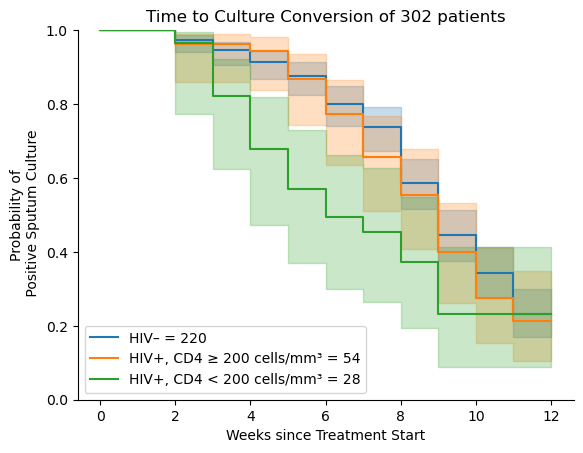

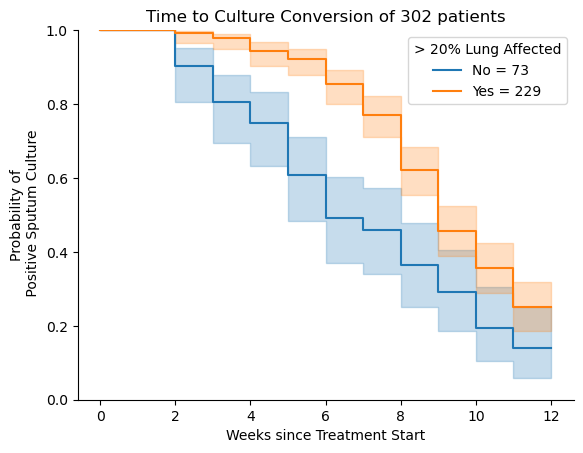

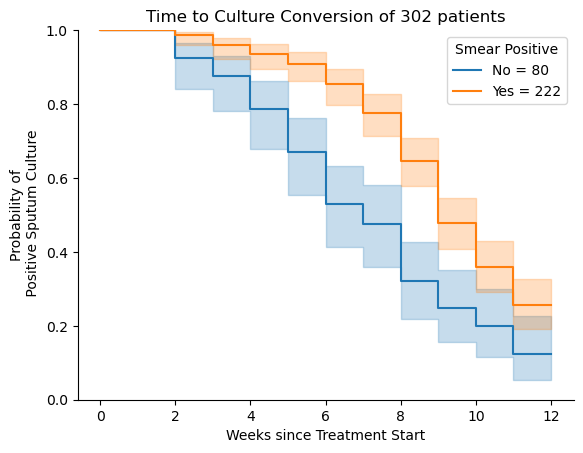

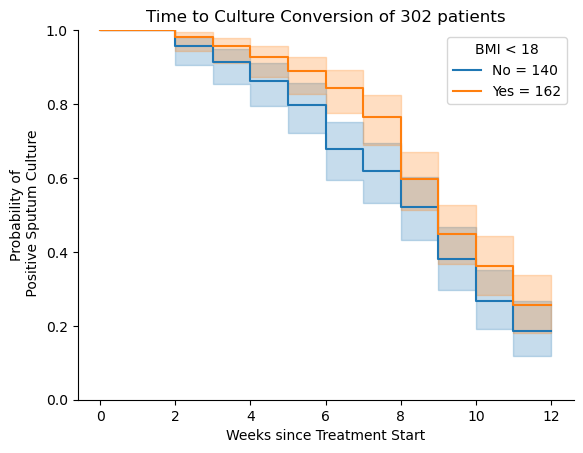

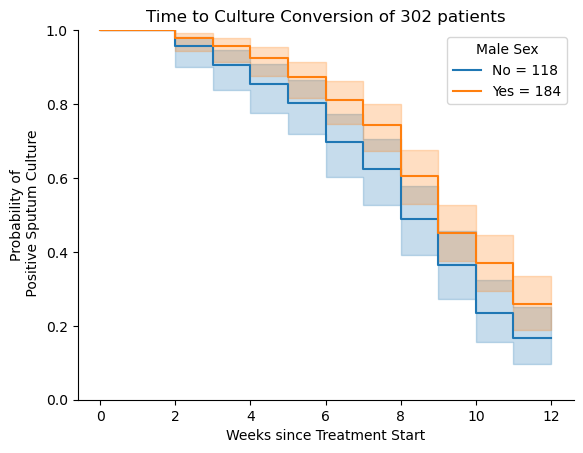

In [298]:
df_check_stratify_vars = df_pids_for_outcomes_model.query("pid in @pids_with_TCC").merge(df_TCC, on='pid')

categorical_cols = ['HIV_CD4', 'high_lung_involvement', 'smear_pos_no_contam_sputum_specimen_1', 'underweight', 'screen_sex']#, 'smoked_substance_use']
labels_lst = ['HIV_CD4', f'> {PLI_thresh}% Lung Affected', 'Smear Positive', 'BMI < 18', 'Male Sex']#, 'Smoked Substance']

legend_name_dict = dict(zip(categorical_cols, labels_lst))

df_logrank_pvalues = pd.DataFrame(columns = ['covariate', 'pval', 'TCC_ratio']).set_index('covariate')

for variable in categorical_cols:
    
    fig, ax = plt.subplots()
    
    df_single_variable = df_check_stratify_vars.dropna(subset=variable)
    df_single_variable[variable] = df_single_variable[variable].astype(int)
    
    if variable == 'HIV_CD4':
        legend_marker_dict = {0: 'HIV–', 1: 'HIV+, CD4 ≥ 200 cells/mm\u00B3', 2: 'HIV+, CD4 < 200 cells/mm\u00B3'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))
    # elif variable == 'Lineage 2':
    #     legend_marker_dict = {1: 'L1', 2: 'L2', 3: 'L3', 4: 'L4'}
    #     color_dict = {1: "#DF83AC", 2: "#7098CB", 3: "#815D9F", 4: "#E76956"}
    else:
        legend_marker_dict = {0: 'No', 1: 'Yes'}
        color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

    # sort so that 0 is plotted before 1
    for group in np.sort(df_single_variable[variable].unique()):
        
        df_single_group = df_single_variable.query(f"{variable}==@group")
            
        kmf = lifelines.KaplanMeierFitter()
        kmf.fit(df_single_group['TCC'], event_observed=df_single_group['culture_convert'], label=group)
            
        kmf.plot_survival_function(ax=ax, show_censors=False, color=color_dict[group], censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{legend_marker_dict[group]} = {len(df_single_group)}")

        if variable != 'HIV_CD4':
            plt.legend(title=legend_name_dict[variable])

    # HIV with high CD4 and HIV-negative are not significantly different, so just compare HIV with low CD4 to the other 2 groups
    if variable == 'HIV_CD4':
        
        # do them separately for each of the two HIV groups relative to the no HIV group
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_High_CD4', :] = [logRank_test_results.p_value,
                                                     df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                    ]
        
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==2")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==2")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc['HIV_Low_CD4', :] = [logRank_test_results.p_value, 
                                                    df_single_variable.query(f"{variable}==2")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                                   ]
        
    else:
        logRank_test_results = lifelines.statistics.logrank_test(durations_A=df_single_variable.query(f"{variable}==1")['TCC'], 
                                                                  durations_B=df_single_variable.query(f"{variable}==0")['TCC'], 
                                                                  event_observed_A=df_single_variable.query(f"{variable}==1")['culture_convert'], 
                                                                  event_observed_B=df_single_variable.query(f"{variable}==0")['culture_convert'],
                                                                 p = 0,
                                                                 q = 0,
                                                                 )
        
        df_logrank_pvalues.loc[variable, :] = [logRank_test_results.p_value, 
                                               df_single_variable.query(f"{variable}==1")['TCC'].mean() / df_single_variable.query(f"{variable}==0")['TCC'].mean()
                                              ]

    # print(f"{legend_name_dict[variable]}: χ^2 = {logRank_test_results.test_statistic}, p = {logRank_test_results.p_value}")
    plt.ylim(0, 1)

    sns.despine()
    plt.title(f"Time to Culture Conversion of {df_single_variable.pid.nunique()} patients")
    plt.ylabel("Probability of\n Positive Sputum Culture") #
    plt.xlabel("Weeks since Treatment Start")
    sns.despine()
            
    if variable in stratify_covariates:
        #plt.show()
        plt.savefig(f"/home/sak0914/MtbLongitudinalDiversity/results/figures/TCC/KM_estimate_stratified_{legend_name_dict[variable]}.svg", bbox_inches='tight')
    else:
        plt.close()
    
df_logrank_pvalues.sort_values('pval').to_csv("/home/sak0914/MtbLongitudinalDiversity/results/TCC/KM_logRank_test_pvalues.csv")

In [300]:
df_logrank_pvalues.sort_values('pval')

,pval,TCC_ratio
covariate,,
smear_pos_no_contam_sputum_specimen_1,0.000001,1.258572
high_lung_involvement,0.000005,1.321427
HIV_Low_CD4,0.005603,0.773909
screen_sex,0.015888,1.103623
underweight,0.037916,1.089781
HIV_High_CD4,0.4989,0.983944


## Composite Poor Outcomes

In [27]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

cols_lst = [
            'screen_sex',
            'screen_years',
            # 'advanced_age',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            # 'smoked_substance_use',
            # 'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'adherence_rate_by_observed',
            'high_lung_involvement',
            # 'human_PLI',
            # 'predicted_PLI',
            # 'cxr_cavity_chest_radiograph_1',
            # 'Lineage', # Lineage_3 is so rare and causes instabilities / needs to be stratified by
            # 'F2',
            # 'MixedInfect'
           ]

tb_deaths_only = True

# try these first, as they were required for the full TCC model
stratify_covariates = []
# non_linear_term_variables = ['screen_years']
non_linear_term_variables = []

MIC_type = 'none'

df_tx_outcomes_full = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv")
df_tx_outcomes = pd.read_csv(f"{TRUST_data_dir}/tx_outcomes.csv").query("pid in @df_pids_for_outcomes_model.pid")

df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'event'] = 0
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'censor_date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['esp_date_end_of_study_parti']
df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti'], 'date'] = df_tx_outcomes.loc[df_tx_outcomes['event_date'] > df_tx_outcomes['esp_date_end_of_study_parti']]['time_in_trial']

df_tx_outcomes['weeks'] = df_tx_outcomes['date'] / 7
df_tx_outcomes['months'] = df_tx_outcomes['date'] / 30

print(f"Maximum event date: {df_tx_outcomes.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [37]:
df_PLI.pid.nunique()

417

In [39]:
df_pids_for_outcomes_model

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,mixed_infect,L1_L3,inh_resistant,underweight,MixedInfect,High_TTP,advanced_age,Age_Squared,predicted_PLI,high_lung_involvement
0,T0001,S0001-01,MFS-331,MFS-331_lib58943,NaN,NaN,1.0,437.07,1.00,0.9887,...,0.0,0.0,0,0,0,1,1,2601,23.755040,1
1,T0002,S0002-01,MFS-509,MFS-509_lib64061,NaN,NaN,1.0,373.24,1.00,0.9901,...,0.0,0.0,0,1,0,0,0,324,27.663921,1
2,T0003,S0003-01,MFS-511,MFS-511_lib64063,NaN,NaN,1.0,339.17,0.99,0.9892,...,0.0,0.0,0,0,0,1,0,2500,8.343956,0
4,T0005,S0005-01,MFS-332,MFS-332_lib58944,NaN,NaN,1.0,348.59,0.99,0.9890,...,0.0,0.0,0,1,0,0,0,729,19.653946,0
5,T0007,S0007-01,MFS-3,MFS-3_lib45533,NaN,NaN,1.0,323.70,0.99,0.9895,...,0.0,0.0,1,0,0,0,0,1024,6.469509,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,T0471,S0471-01,MFS-860,MFS-860_lib73356,NaN,NaN,1.0,371.19,0.99,0.9841,...,0.0,0.0,0,1,0,1,0,289,77.533170,1
375,T0474,S0474-01,MFS-864,MFS-864_lib73360,NaN,NaN,1.0,570.01,0.99,0.9870,...,0.0,0.0,0,0,0,0,0,324,20.778086,1
376,T0475,S0475-01,MFS-866,MFS-866_lib73362,NaN,NaN,1.0,478.76,0.99,0.9863,...,0.0,0.0,0,0,0,1,0,1600,13.490097,0
377,T0476,S0476-01,MFS-894,MFS-894_lib83849,NaN,NaN,1.0,299.05,1.00,0.9848,...,0.0,1.0,0,1,0,0,0,676,40.826385,1


In [516]:
# df_lowAF_variants_baseline.query("GENE in ['sugI', 'dacB1-sugI']")

In [517]:
df_tx_outcomes.query("pid in @df_baseline_samples.pid").query("TB_death != 0 & event == 1").event_type.value_counts()

event_type
relapse       9
tx_failure    8
death         2
Name: count, dtype: int64

In [443]:
27 / len(df_tx_outcomes.query("pid in @df_baseline_samples.pid"))

0.07258064516129033

In [444]:
binary_cols = ['diabetes', 'bl_prevtb', 'underweight', 'fstrom1_baseline']

for col in binary_cols:
    print(col, df_pids_for_outcomes_model[col].sum(), df_pids_for_outcomes_model[col].mean())

diabetes 17 0.0456989247311828
bl_prevtb 142 0.3817204301075269
underweight 202 0.543010752688172
fstrom1_baseline 252.0 0.6774193548387096


In [445]:
df_pids_for_outcomes_model['screen_years'].min(), df_pids_for_outcomes_model['screen_years'].max(), df_pids_for_outcomes_model['screen_years'].median()

(15, 77, 37.0)

In [446]:
df_pids_for_outcomes_model['HIV_CD4'].value_counts()

HIV_CD4
0.0    268
1.0     63
2.0     36
Name: count, dtype: int64

In [447]:
df_pids_for_outcomes_model['screen_sex'].value_counts()

screen_sex
1    226
0    146
Name: count, dtype: int64

In [448]:
214 / len(df_pids_for_outcomes_model), len(df_pids_for_outcomes_model)

(0.5752688172043011, 372)

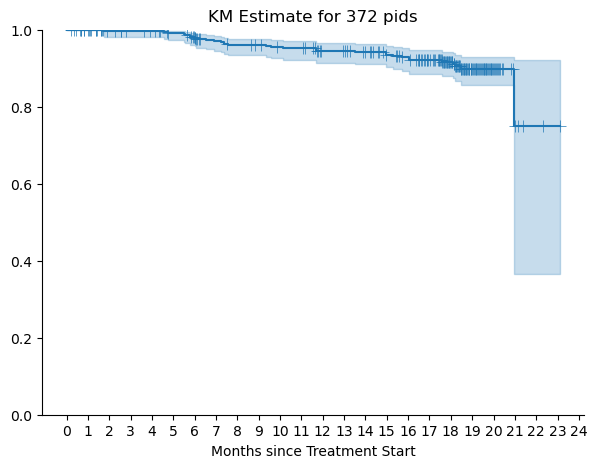

In [449]:
fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_tx_outcomes.months.max()))

kmf = lifelines.KaplanMeierFitter()

kmf.fit(df_tx_outcomes['months'], event_observed=df_tx_outcomes['event'],)# label=group_name)

kmf.plot_survival_function(ax=ax, 
                           show_censors=True, 
                           censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                           # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                          )

# Original event table (indexed by actual event/censor times)
event_table = kmf.event_table

# Define integer time points of interest
integer_times = np.arange(0, max_val + 1)

# Reindex to integer times
event_table_int = (
    event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
)

# Now you can extract at-risk and censored at integer times
at_risk_int = event_table_int["at_risk"]
censored_int = event_table_int["censored"]

every_other_month = np.linspace(0, max_val, 13)

sns.despine()
ax.get_legend().remove()
plt.xlabel('Months since Treatment Start')
ax.set_xticks(range(0, max_val + 1))

plt.ylim(0, 1)
plt.title(f"KM Estimate for {df_tx_outcomes.pid.nunique()} pids")
plt.savefig("../results/figures/outcomes/KM_estimate.svg", bbox_inches='tight')

In [450]:
event_table_int[['at_risk', 'censored']].loc[every_other_month].T

event_at,0,2,4,6,8,10,12,14,16,18,20,22,24
at_risk,372,349,342,326,312,306,295,287,271,195,22,3,1
censored,0,1,1,1,0,1,1,1,1,4,1,1,1


In [451]:
df_pids_for_outcomes_model.shape, df_pids_for_outcomes_model.pid.nunique()

((372, 7904), 372)

In [452]:
df_pids_for_outcomes_model.pid.nunique()

372

In [453]:
df_pids_for_outcomes_model.F2.max()

0.0253793307962239

In [454]:
df_pids_for_outcomes_model.pid.nunique()

372

In [455]:
# df_age_knots = pd.DataFrame(columns = ['dof', 'AIC', 'LL', 'CI'])

# # age_spline_lb = np.percentile(df_model_processed['screen_years'], 25)
# # age_spline_ub = np.percentile(df_model_processed['screen_years'], 75)

# age_spline_lb = -0.8
# age_spline_ub = 0.8

# for i, dof in enumerate(np.arange(2, 9)):

#     df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
#                                                                                       TRUST_phenos,
#                                                                                        TRUST_phenos,
#                                                                                       df_tx_outcomes,
#                                                                                       cols_lst,# + ['RIF_AUC'],
#                                                                                       event_col = 'event',
#                                                                                       time_col = 'date',
#                                                                                     MIC_type = 'none',
#                                                                                     binarize_drugs=['RIF'],
#                                                                                       tb_deaths_only=tb_deaths_only,
#                                                                                       invert_OR=False,
#                                                                                       stratify_variables=stratify_covariates,
#                                                                                     non_linear_term_variables=non_linear_term_variables,
#                                                                                     knots_tup=(age_spline_lb, age_spline_ub),
#                                                                                     number_nonlinear_knots=dof,
#                                                                                      binary_lineage=True,
#                                                                                     PLI_thresh=PLI_thresh
#                                                                                      )


#     # convert to HR per 10 years
#     OR_col = 'OR'
#     df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

#     df_violating_covariates = []

#     for model_idx in range(len(cph_model)):

#         df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

#         # diabetes has a p-value of like 0.0105
#         violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

#         violating_covariates['imp_num'] = model_idx + 1

#         df_violating_covariates.append(violating_covariates)

#     df_violating_covariates = pd.concat(df_violating_covariates)
#     print(len(df_violating_covariates.query("p <= 0.05")))

#     df_model_processed = df_model_processed[0]
#     cph_model = cph_model[0]

#     cph_model.check_assumptions(df_model_processed)
    
#     df_age_knots.loc[i, :] = [dof, cph_model.AIC_partial_, cph_model.log_likelihood_, cph_model.concordance_index_]

In [28]:
labels_dict = {'RIF_AUC': 'Rifampicin PK AUC',
              'INH_AUC': 'Isoniazid PK AUC',
              'EMB_AUC': 'Ethambutol PK AUC',
              'PZA_AUC': 'Pyrazinamide PK AUC',
              'screen_sex': 'Male Sex',
              'screen_years': 'Age',
              'bl_bmi': 'Body Mass Index',
              'smoked_substance_use': 'Smoked Substance Use',
              'HIV_High_CD4': 'HIV, CD4 ≥ 200 cells/$\mathregular{mm^3}$',
              'HIV_Low_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$',
              'bl_prevtb': 'Previous TB Disease',
              'smear_pos_no_contam_sputum_specimen_1': 'Smear Positivity at Baseline',
              'diabetes': 'Diabetes',
              'Lineage_1': 'Lineage 1',
              'Lineage_2': 'Lineage 2',
              'Lineage_3': 'Lineage 3',
              'Lineage_4': 'Lineage 4',
              'total_adherence': 'Adherence Rate',
              'F2': 'F2 Strain Mixing Metric',
              'inh_resistant': 'INH Resistance',
              'high_lung_involvement': '>20% Lung Affected',
              'RIF_pred_MIC': 'Predicted RIF MIC',
              'INH_pred_MIC': 'Predicted INH MIC',
              'EMB_pred_MIC': 'Predicted EMB MIC',
              'PZA_pred_MIC': 'Predicted PZA MIC',
              'RIF_midpoint': 'Measured RIF MIC',
              'INH_midpoint': 'Measured INH MIC',
              'EMB_midpoint': 'Measured EMB MIC',
              'PZA_midpoint': 'Measured PZA MIC',
               'delayed_TCC': 'TCC > 8 Weeks',
               'TTP_baseline': 'TTP at Baseline',
               'peth_value_baseline': 'PEth',
               'fstrom1_baseline': 'Smoking',
               'RIF_pred_MIC_high': 'Predicted RIF MIC > 0.06 µg/mL',
               # 'INH_pred_MIC_high': 'Predicted Isoniazid MIC',
               'PZA_pred_MIC_high': 'Predicted Pyrazinamide MIC > 24.6 µg/mL',
               'HIV_CD4': 'HIV, CD4 < 200 cells/$\mathregular{mm^3}$', # when we computed the relative risk, it was this group vs. the other two groups,
               'high_lung_involvement': f'PLI > {PLI_thresh}%',
               'Not_Lineage_2': 'Not Lineage 2',
               # 'NumVar': '# of low-AF Segregating Sites',
               # 'NumVar1': '# of low-AF Sites at Baseline',
               # 'NumVar2': '# of low-AF Sites at Follow-Up',
               'NumVar1': 'Unfixed Variants at Baseline',
               'NumVar2': 'Unfixed Variants at Follow-Up',
               'ChangeSites': '# of low-AF Sites with a Change',
               'underweight': 'BMI < 18',
               'adherence_rate_by_observed': 'Tx Adherence',
               'SASE1': 'Site-Averaged Shannon Entropy at Baseline',
               'cxr_cavity_chest_radiograph_1': 'Cavitation',
               'predicted_PLI': 'Predicted % Lung Involvement',
               'advanced_age': f'> {age_thresh} years',
               'NumSNVs': 'Unfixed SNVs at Baseline',
               'NumIndels': 'Unfixed Indels at Baseline',
               'NumPhaseVariants': 'Unfixed Phase Variants at Baseline',
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[1]': 'Age < 25th Percentile',
               # f'bs(screen_years, knots=({age_spline_lb}, 0.8), lower_bound=-2, upper_bound=4, degree=0)[2]': 'Age > 75th Percentile'
             }

# Univariate Patient Associations

In [30]:
df_univariate_associations = []

for col in cols_lst:# + list(df_pids_for_outcomes_model.columns[df_pids_for_outcomes_model.columns.str.contains('AUC')]):
    
    df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @pids_with_low_F2"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                    [col],
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                MIC_type = 'none',
                                                                                  # MIC_type=MIC_type,
                                                                                 # include_drugs=['RIF'],
                                                                                 # binarize_drugs=['RIF'],
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                 binary_lineage=True,
                                                                                    PLI_thresh=PLI_thresh,
                                                                                 )


    # convert to HR per 10 years
    OR_col = 'OR'
    df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    df_violating_covariates = []

    for model_idx in range(len(cph_model)):

        df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

        # diabetes has a p-value of like 0.0105
        violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})

        violating_covariates['imp_num'] = model_idx + 1

        df_violating_covariates.append(violating_covariates)

    df_violating_covariates = pd.concat(df_violating_covariates)
    print(len(df_violating_covariates.query("p <= 0.05")))

    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    cph_model.check_assumptions(df_model_processed)
    
#     if col == 'screen_years':
#         df_test_results[['OR', 'OR_lower', 'OR_upper']] = df_test_results[['OR', 'OR_lower', 'OR_upper']]**10
    
    df_univariate_associations.append(df_test_results)
    # print(f"    AIC: {cph_model.AIC_partial_}")
    # print(f"    Concordance Index: {cph_model.concordance_index_}")
    # print(f"    Log Likelihood: {cph_model.log_likelihood_}")

    # base_model_LL = cph_model.log_likelihood_
    
df_univariate_associations = pd.concat(df_univariate_associations)

    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    340 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.
    Censored 6 patients with non-TB deaths
    342 total pids
0
Proportional hazard assumption looks okay.


In [34]:
df_univariate_associations.query("pval <= 0.05")

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
0,HIV_Low_CD4,0.472322,1.603714,0.170748,1.556057,0.562528,1,0.005672,4.740093,1.573847,14.276152


posx and posy should be finite values
posx and posy should be finite values


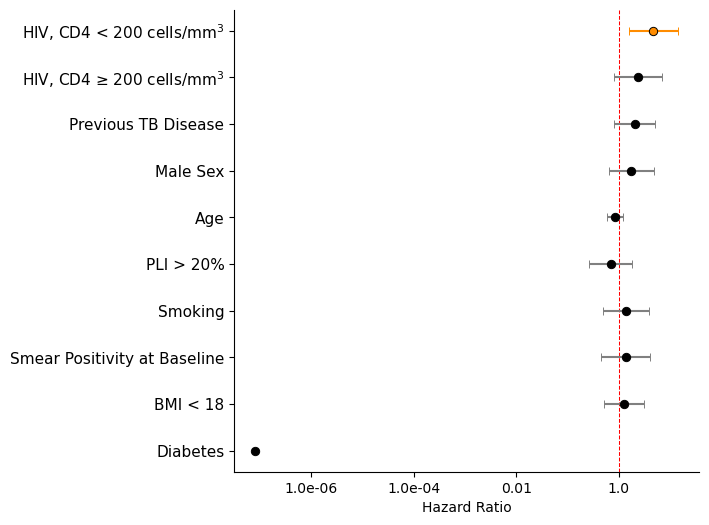

In [35]:
outcomes_covariates_lst = list(df_univariate_associations.sort_values(['pval', 'OR'], ascending=[True, False]).covariate.values)

forest_plot(df_univariate_associations, 
            outcomes_covariates_lst,
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            # saveName="../results/figures/outcomes/forest_plot_univariate_assoc.svg"
           )


In [31]:
df_test_results, df_model_processed, cph_model = fit_cox_models_all_imputations(df_pids_for_outcomes_model,#.query("pid in @df_LAF.pid"),
                                                                                  TRUST_phenos,
                                                                                   TRUST_phenos,
                                                                                  df_tx_outcomes,
                                                                                  cols_lst,# + ['RIF_AUC'],
                                                                                  event_col = 'event',
                                                                                  time_col = 'date',
                                                                                MIC_type = 'none',
                                                                                binarize_drugs=['RIF'],
                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                  invert_OR=False,
                                                                                  stratify_variables=stratify_covariates,
                                                                                non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                                                 binary_lineage=True,
                                                                                PLI_thresh=PLI_thresh
                                                                                 )


# convert to HR per 10 years
OR_col = 'OR'
df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate'].isin(['screen_years', 'human_PLI', 'predicted_PLI']), [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

df_violating_covariates = []

for model_idx in range(len(cph_model)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_model[model_idx], df_model_processed[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)
print(len(df_violating_covariates.query("p <= 0.05")))

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

base_model_LL = cph_model.log_likelihood_

    Censored 6 patients with non-TB deaths
    340 total pids
0
Proportional hazard assumption looks okay.
    AIC: 206.920154419626
    Concordance Index: 0.7273491696447341
    Log Likelihood: -93.460077209813


In [32]:
OR_col = 'OR'

df_test_results.query("pval <= 0.05").sort_values('pval')[['pval', 'covariate', f"{OR_col}_lower", OR_col, f"{OR_col}_upper"]]

,pval,covariate,OR_lower,OR,OR_upper
6,0.011768,HIV_Low_CD4,1.402926,4.597454,15.06607


In [33]:
forest_plot(df_test_results,#.query("pval <= 0.5"), 
            list(outcomes_covariates_lst),
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            # x_lim=[0.01, 20],
            # saveName="../results/figures/outcomes/forest_plot.svg"
           )


NameError: name 'outcomes_covariates_lst' is not defined

In [504]:
# diversity_metric = 'ChangeSites'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(8, color='red', label="8")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/change_sites.svg", bbox_inches='tight')

In [505]:
# diversity_metric = 'NumVar'

# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid', diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

# sns.histplot(df_add_metric_for_model,
#              x=diversity_metric,
#              hue='Lineage',
#              multiple='dodge',
#              # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2), discrete=True
#             )

# plt.axvline(9, color='red', label="9")
# plt.legend()

# plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")

# sns.despine()
# plt.savefig(f"../results/figures/segregating_sites.svg", bbox_inches='tight')

In [120]:
def find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, df_LAF_baseline, thresh, diversity_metric='NumVar1'):

    binarize = True

    df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + [diversity_metric]])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
    # df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + diversity_metrics])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

    if binarize:
        df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > thresh).astype(int)

        median_val = df_add_metric_for_model[diversity_metric].median()
        # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

    df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                                  TRUST_phenos, 
                                                                    TRUST_phenos,
                                                                  df_tx_outcomes,
                                                               cols_lst + [diversity_metric],# + ['RIF_AUC'],
                                                                                        # cols_lst + ['grouped_variant'] + ['RIF_AUC'],
                                                                  event_col = 'event',
                                                                  time_col = 'date',
                                                                                              MIC_type='none',
                                                               # MIC_type=MIC_type,
                                                                 # include_drugs=['RIF'],
                                                                 # binarize_drugs=['RIF'],
                                                                  tb_deaths_only=True,
                                                                  invert_OR=False,
                                                                  stratify_variables=stratify_covariates,
                                                                                              non_linear_term_variables=non_linear_term_variables,
                                                                                    # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                    number_nonlinear_knots=2,
                                                                 binary_lineage=True,
                                                                                              PLI_thresh=PLI_thresh
                                                                 )

    df_model_processed = df_model_processed[0]
    cph_model = cph_model[0]

    cph_model.check_assumptions(df_model_processed)

    print(f"Final: {df_model_processed.pid.nunique()} pids")
    
    return cph_model.AIC_partial_, cph_model.concordance_index_

In [144]:
df_AIC_NumVar1_binarized = pd.DataFrame(columns = ['Thresh', 'AIC', 'CI'])

for i, thresh in enumerate(np.arange(df_LAF_baseline.NumVar1.min(), df_LAF_baseline.NumVar1.max())):
        
    AIC, CI = find_best_variant_burden_binarization_threshold(df_pids_for_outcomes_model, df_LAF_baseline, thresh)
    
    df_AIC_NumVar1_binarized.loc[i, :] = [thresh, AIC, CI]

    Censored 6 patients with non-TB deaths
    364 total pids
Proportional hazard assumption looks okay.
Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 364 total observations, 339 right-censored observations>
         test_name = proportional_hazard_test

---
                                            test_statistic    p  -log2(p)
HIV_High_CD4                          km              0.07 0.79      0.33
                                      rank            0.15 0.70      0.51
HIV_Low_CD4                           km              0.10 0.75      0.42
                                      rank            0.00 0.99      0.02
NumVar1                               km              3.53 0.06      4.05
                                      rank            7.13 0.01      7.04
bl_prevtb                             km              0.05 0.83      0.28
                                      rank            0.16 0.69      0.53
diabetes                              km              0.35 0.55      0.86
                                      rank            0.41 0.52      0.93
fstrom1_baseline                      km              0.98 0.32      1.64
                                      rank            0.05 0.82      0.28
human_PLI                             km              0.18 0.67      0.57
                                      rank            0.51 0.48      1.07
screen_sex                            km              0.02 0.89      0.16
                                      rank            0.00 0.96      0.06
screen_years                          km              1.57 0.21      2.25
                                      rank            0.84 0.36      1.47
smear_pos_no_contam_sputum_specimen_1 km              0.27 0.60      0.73
                                      rank            1.48 0.22      2.16
underweight                           km              0.23 0.63      0.66
                                      rank            0.80 0.37      1.43



1. Variable 'NumVar1' failed the non-proportional test: p-value is 0.0076.

   Advice: with so few unique values (only 2), you can include `strata=['NumVar1', ...]` in the call
in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification

Final: 364 pids
    Censored 6 patients with non-TB deaths
    364 total pids
Proportional hazard assumption looks okay.
Final: 3

In [145]:
df_AIC_NumVar1_binarized.sort_values('AIC', ascending=True)

,Thresh,AIC,CI
8,8,275.563126,0.703183
13,13,276.508597,0.69855
12,12,276.508597,0.69855
5,5,276.978315,0.705724
9,9,277.246709,0.700493
16,16,277.496938,0.696906
17,17,277.496938,0.696906
18,18,277.496938,0.696906
11,11,277.584929,0.699746
7,7,277.800591,0.703482


In [146]:
df_AIC_NumVar1_binarized.Thresh.max()

18

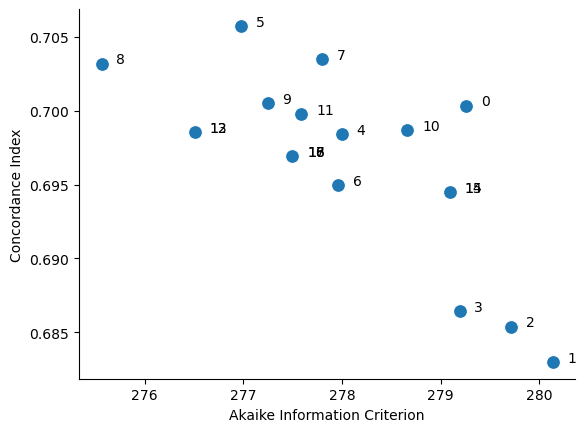

In [147]:
fig, ax = plt.subplots()

sns.scatterplot(data=df_AIC_NumVar1_binarized,#.melt(id_vars=['Thresh'], value_vars=['AIC', 'CI']),
            x='AIC',
            y='CI',
            # hue='Thresh',
              s=100,
              ax=ax
           )

for i, row in df_AIC_NumVar1_binarized.iterrows():
    ax.text(row['AIC'] + 0.15, row['CI'], row['Thresh'])
    
plt.xlabel('Akaike Information Criterion')
plt.ylabel('Concordance Index')
    
sns.despine()
# plt.show()
# plt.savefig("../results/figures/outcomes/binarized_NumVar1_AIC_CI.svg", bbox_inches='tight')

In [187]:
diversity_metrics = ['NumVar1']
# diversity_metrics = ['NumVar2']
# diversity_metrics = ['NumVar1', 'NumVar2']
binarize = False
thresh = 8

# grouped_variant_genes = ['Rv2690c'] #['phoR'] #['sugI'] #['devS', 'devR']

# df_LAF['grouped_variant'] = df_LAF['pid'].isin(df_lowAF_variants.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)
# df_LAF_baseline['grouped_variant'] = df_LAF_baseline['pid'].isin(df_lowAF_variants_baseline.query("GENE in @grouped_variant_genes").pid.unique()).astype(int)

# print(df_LAF_baseline.grouped_variant.value_counts())

# diversity_metric = 'ChangeSites'
# binarize = True
# thresh = 8

# diversity_metric = 'NumVar'
# binarize = True
# thresh = 9

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid'] + diversity_metrics])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])
# df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF[['pid'] + diversity_metrics])#.query("pid in @pids_with_low_F2").merge(df_LAF[['pid', col_to_binarize]])

if binarize:
    
    for metric in diversity_metrics:
        df_add_metric_for_model[metric] = (df_add_metric_for_model[metric] > thresh).astype(int)
        median_val = df_add_metric_for_model[metric].median()
    # df_add_metric_for_model[diversity_metric] = (df_add_metric_for_model[diversity_metric] > median_val).astype(int)

df_test_results_diversity, df_model_processed, cph_model = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              TRUST_phenos, 
                                                                TRUST_phenos,
                                                              df_tx_outcomes,
                                                           cols_lst + diversity_metrics,# + ['RIF_AUC'],
                                                                                    # cols_lst + ['grouped_variant'] + ['RIF_AUC'],
                                                              event_col = 'event',
                                                              time_col = 'date',
                                                                                          MIC_type='none',
                                                           # MIC_type=MIC_type,
                                                             # include_drugs=['RIF'],
                                                             # binarize_drugs=['RIF'],
                                                              tb_deaths_only=True,
                                                              invert_OR=False,
                                                              stratify_variables=stratify_covariates,
                                                                                          non_linear_term_variables=non_linear_term_variables,
                                                                                # knots_tup=(age_spline_lb, age_spline_ub),
                                                                                number_nonlinear_knots=2,
                                                             binary_lineage=True,
                                                                                          PLI_thresh=PLI_thresh
                                                             )

df_model_processed = df_model_processed[0]
cph_model = cph_model[0]

OR_col = 'OR'

cph_model.check_assumptions(df_model_processed)
print(f"    AIC: {cph_model.AIC_partial_}")
print(f"    Concordance Index: {cph_model.concordance_index_}")
print(f"    Log Likelihood: {cph_model.log_likelihood_}")

diversity_metric_continuous_LL = cph_model.log_likelihood_

# scale age
if not binarize:
    scale_factor = 10
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'peth_value_baseline', 'human_PLI']), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(['screen_years', 'peth_value_baseline', 'human_PLI']), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

    scale_factor = 5
    df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(diversity_metrics), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]] = df_test_results_diversity.loc[df_test_results_diversity['covariate'].isin(diversity_metrics), [OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]**scale_factor

print(f"Final: {df_model_processed.pid.nunique()} pids")

    Censored 6 patients with non-TB deaths
    364 total pids
Proportional hazard assumption looks okay.
    AIC: 281.7466018911746
    Concordance Index: 0.6651472126737409
    Log Likelihood: -129.8733009455873
Final: 364 pids


In [188]:
df_test_results_diversity.query("pval <= 0.05").sort_values(['pval'])

,covariate,coef,exp(coef),se(coef),coef_transformed,se_transformed,imp_num,pval,OR,OR_lower,OR_upper
6,HIV_Low_CD4,0.365866,1.441762,0.164968,1.223877,0.551843,1,0.026569,3.400346,1.152904,10.028896
8,NumVar1,0.293400,1.340980,0.146130,0.101248,0.050427,1,0.044665,1.659041,1.012134,2.719419


In [189]:
# Cox Snell Pseudo R^2.
# There is not a good consensus on how to compute R^2 for survival regression models, so I picked this one
1 - np.exp(2/len(df_model_processed) * (base_model_LL - diversity_metric_continuous_LL))

0.009005317121530854

In [190]:
df_test_results_diversity.OR_upper.max()

12.959331285856496

In [153]:
def LRT(LL_1, LL_2):
    
    test_stat = np.abs(2 * (LL_1 - LL_2))

    # p-value from the chi-squared distribution
    return 1 - st.chi2.cdf(test_stat, 1)

In [154]:
LRT(diversity_metric_continuous_LL, base_model_LL)

0.032513041065506454

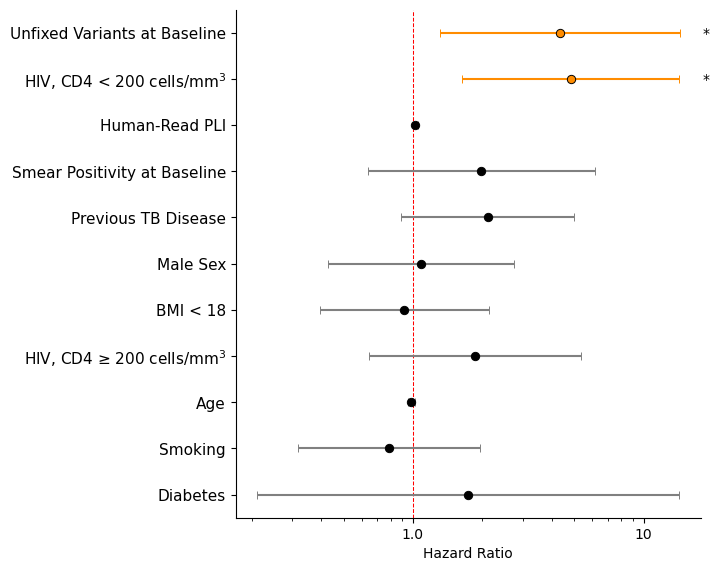

In [155]:
forest_plot(df_test_results_diversity,#.query("pval <= 0.5"), 
            diversity_metrics + list(outcomes_covariates_lst),
            labels_dict, 
            val_col='OR', 
            alpha=0.05, 
            log=True, 
            pval_offset=1.25, 
            df_stratify_variables_results=None, 
            # x_lim=[0.01, 20],
             # saveName=f"../results/figures/outcomes/forest_plot_with_diversity.svg"
            # saveName=f"../results/figures/outcomes/forest_plot_with_diversity_binarized_{thresh}.svg"
           )


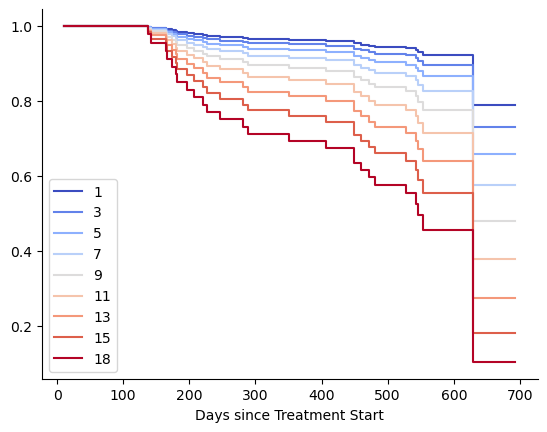

In [99]:
scaler = StandardScaler()

raw_values = df_add_metric_for_model.query("pid in @df_model_processed.pid")[diversity_metric].values

raw_mean = raw_values.mean()
raw_sd = raw_values.std()

scaled_values = (raw_values - raw_mean) / raw_sd

def unscale_val(scaled_val, raw_mean, raw_sd):
    # it should be an integer, so return it as such. If it's not, it's a float precision problem
    return int(scaled_val * raw_sd + raw_mean)

# percentiles_lst = [25, 50, 75, 87.5, 100]

# if binarize:
#     test_vals = df_model_processed[diversity_metric].unique()
# else:
#     test_vals = np.percentile(scaled_values, percentiles_lst)
    
# percentile_dict = dict(zip(test_vals, percentiles_lst))

test_vals = np.linspace(1, df_add_metric_for_model.NumVar1.max(), int(df_add_metric_for_model.NumVar1.max() / 2))
test_vals = (test_vals - raw_mean) / raw_sd

ax = cph_model.plot_partial_effects_on_outcome(covariates=diversity_metric, values=test_vals, plot_baseline=False, cmap='coolwarm')

# Update legend labels
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, [f"{perc}th perc. = {str(unscale_val(val, raw_mean, raw_sd))}" for val, perc in percentile_dict.items()])
ax.legend(handles, [f"{str(unscale_val(val, raw_mean, raw_sd))}" for val in test_vals])
ax.set_xlabel('Days since Treatment Start')

sns.despine()
plt.savefig("../results/figures/outcomes/NumVar1_varying_hazard.svg", bbox_inches='tight')

# Binarized NumVar1

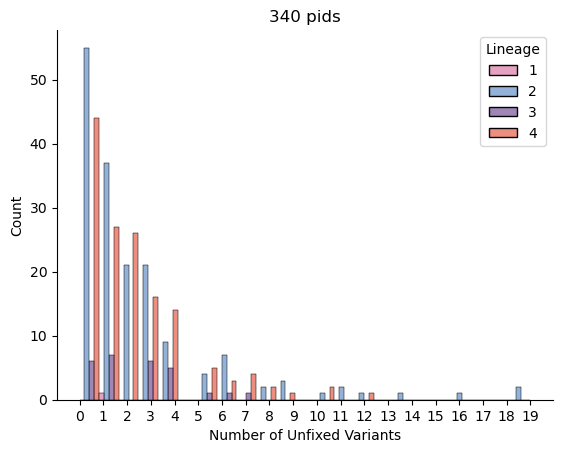

In [80]:
diversity_metric = 'NumVar1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_LAF_baseline[['pid', diversity_metric]]).query("pid in @df_model_processed.pid")#.query("pid in @pids_with_same_lineage_and_low_F2")#.merge(df_LAF[['pid', col_to_binarize]])

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

    
sns.histplot(df_add_metric_for_model,
             x=diversity_metric,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_add_metric_for_model[diversity_metric].min()),
        int(df_add_metric_for_model[diversity_metric].max()) + 1
    )
)

plt.title(f"{df_add_metric_for_model.pid.nunique()} pids")
plt.xlabel('Number of Unfixed Variants')

sns.despine()
plt.savefig(f"../results/figures/variable_sites_sample1.svg", bbox_inches='tight')

In [84]:
df_LAF_baseline['Lineage'] = df_LAF_baseline['Lineage'].astype(float).astype(int).astype(str)

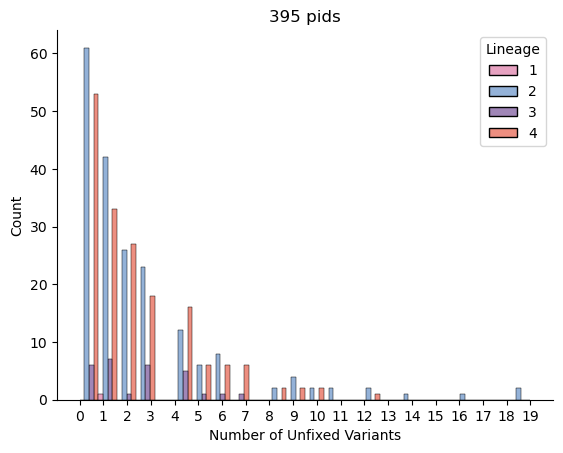

In [93]:
fig, ax = plt.subplots()

plot_var = 'NumVar1'

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

    
sns.histplot(df_LAF_baseline,
             x=plot_var,
             hue='Lineage',
             multiple='dodge',
             # bins=range(int(df_add_metric_for_model[diversity_metric].min()), int(df_add_metric_for_model[diversity_metric].max()) + 2),
             hue_order=['1', '2', '3', '4'],
             palette=LinToColor_Dict,
             ax=ax
            )

# Force integer x-axis ticks
plt.xticks(
    np.arange(
        int(df_LAF_baseline[plot_var].min()),
        int(df_LAF_baseline[plot_var].max()) + 1
    )
)
plt.title(f"{df_LAF_baseline.pid.nunique()} pids")
plt.xlabel('Number of Unfixed Variants')

sns.despine()

plt.savefig(f"../results/figures/{plot_var}.svg", bbox_inches='tight')

In [94]:
# df_combined_counts = df_LAF_baseline.query("pid in @df_model_processed.pid")[['pid', 'Lineage', 'NumVar1']]
df_combined_counts = df_LAF_baseline[['pid', 'Lineage', 'NumVar1']]
df_combined_counts['Lineage'] = df_combined_counts['Lineage'].astype(int).astype(str)

lambda_params_dict = exponential_LRT(df_combined_counts, 'NumVar1', min_count=5)

print(f"Min: {df_combined_counts.NumVar1.min()}")
print(f"Median: {df_combined_counts.NumVar1.median()}")
print(f"Mean: {df_combined_counts.NumVar1.mean()}")
print(f"Max: {df_combined_counts.NumVar1.max()}")

λ for lineage 2 = 0.4084210526315789
λ for lineage 3 = 0.43076923076923074
λ for lineage 4 = 0.45382585751978893
λ for full = 0.4287268770402612

Likelihood ratio test statistic: 1.011
P-value: 0.6031
Min: 0
Median: 1.0
Mean: 2.329113924050633
Max: 19


In [79]:
df_LAF_baseline.NumVar1.sum()

920

In [666]:
df_LAF_baseline.query("NumVar1 != NumIndels + NumSNVs")

,pid,SE1,SASE1,NumVar1,Coll2014,Freschi2020,Lineage,F2,s_ttp_sputum_specimen_1,NumIndels,NumSNVs,NumPhaseVariants


In [626]:
def bin_by_min_count(values, min_count):
    """
    Group sorted values into bins with at least `min_count` elements.
    
    Parameters
    ----------
    values : array-like
        The input values.
    min_count : int
        Minimum number of elements per bin.
        
    Returns
    -------
    bins : list of arrays
        A list of arrays, each containing the values in that bin.
    edges : list of tuples
        (min, max) range for each bin.
    """
    values = np.sort(values)
    n = len(values)
    
    # Determine split indices
    splits = np.arange(min_count, n, min_count)
    bins = np.split(values, splits)
    
    # Merge last bin if it's too small
    if len(bins[-1]) < min_count and len(bins) > 1:
        bins[-2] = np.concatenate([bins[-2], bins[-1]])
        bins = bins[:-1]
    
    edges = [(b[0], b[-1]) for b in bins]
    return bins, edges

<Axes: xlabel='screen_years', ylabel='Proportion'>

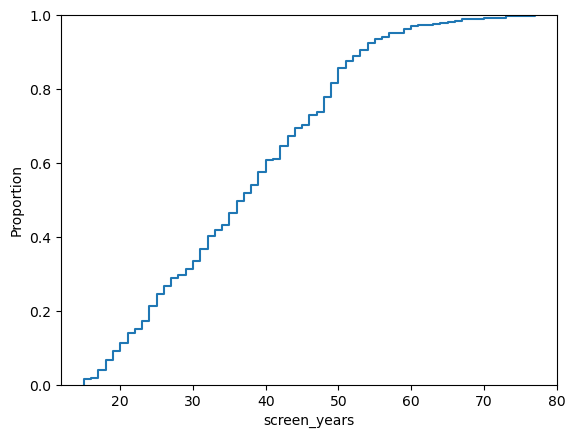

In [636]:
sns.ecdfplot(data=df_KM_plot,
             x='screen_years'
            )

91
85
89
75
Balanced: p = 0.0143
Early: p = 0.0159
Late: p = 0.0035


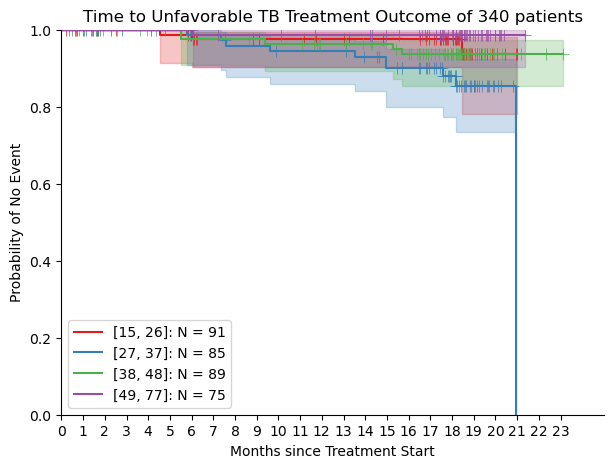

In [228]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['screen_years'] = df_KM_plot['screen_years'].astype(int)

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["screen_years"],
    q=[0, 0.25, 0.50, 0.75, 1.0],       # quantile cutpoints
    labels=["Q1", "Q2", "Q3", "Q4"]     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metrics[0]]

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

value_dict = {var: [df_KM_plot.query(f"var_group==@var").screen_years.min(), df_KM_plot.query(f"var_group==@var").screen_years.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

<Axes: xlabel='screen_years', ylabel='Count'>

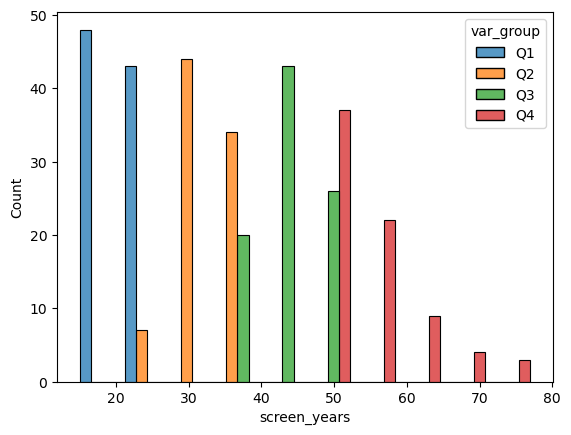

In [322]:
sns.histplot(data=df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot),#[['pid', 'screen_years', 'screen_years_scaled']],
             x='screen_years',#_scaled',
             hue='var_group',
             multiple='dodge'
            )

In [326]:
df_KM_plot.query("var_group=='Q4'").screen_years.min()

49

In [246]:
df_model_processed[['pid', 'screen_years']].rename(columns={'screen_years': 'screen_years_scaled'}).merge(df_KM_plot).groupby('var_group')['screen_years_scaled'].agg(['min', 'max'])

,min,max
var_group,,
Q1,-1.716589,-0.860355
Q2,-0.782515,-0.004121
Q3,0.073719,0.852113
Q4,0.929953,3.109457


In [645]:
df_KM_plot.var_group.value_counts()

var_group
0    305
1     35
Name: count, dtype: int64

347
17
Balanced: p = 0.0046
Early: p = 0.0054
Late: p = 0.0003


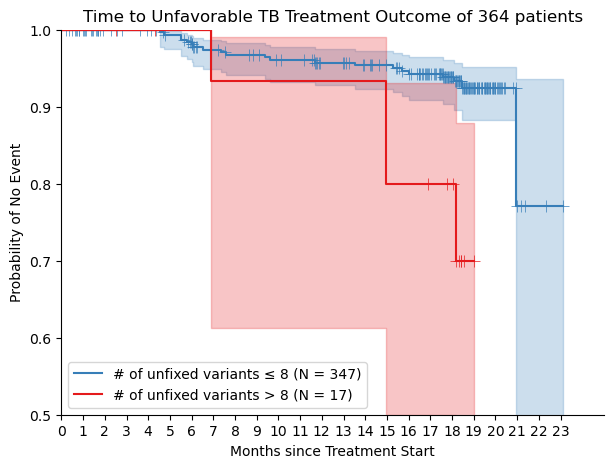

In [157]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

# get raw values
del df_KM_plot['NumVar1']
df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)
df_KM_plot['var_group'] = (df_KM_plot['NumVar1'] > thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

color_dict = {0: sns.color_palette('Set1').as_hex()[1], 1: sns.color_palette('Set1').as_hex()[0]}
label_dict = {0: f"≤ {thresh}", 1: f"> {thresh}"}

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'])
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"# of unfixed variants {label_dict[group]} (N = {len(df_single_group)})",
                              )

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')

In [158]:
df_KM_plot.groupby('var_group').event.agg(['sum', 'mean'])

,sum,mean
var_group,,
0,21,0.060519
1,4,0.235294


In [159]:
df_KM_plot.query("var_group==1")[['event', 'event_type']].query("event_type != 'cure'")

,event,event_type
25,1,relapse
42,1,relapse
55,1,death
255,1,tx_failure


177
90
73
Balanced: p = 0.3578
Early: p = 0.3639
Late: p = 0.1031


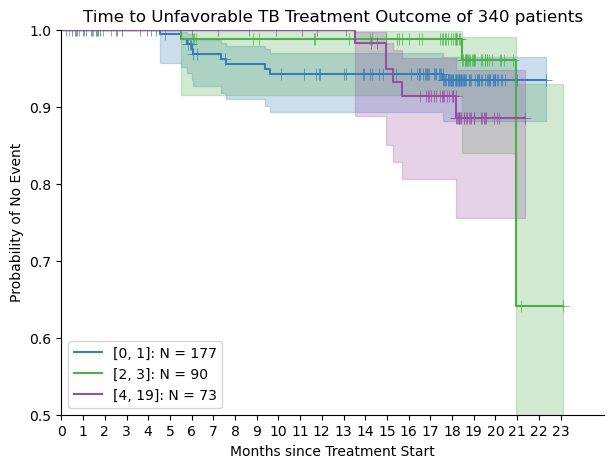

In [597]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])

df_KM_plot['NumVar1'] = df_KM_plot['NumVar1'].astype(int)

df_KM_plot["var_group"] = pd.qcut(
    df_KM_plot["NumVar1"],
    q=[0, 0.50, 0.75, 1.0],       # quantile cutpoints
    labels=["Q2", "Q3", "Q4"]     # group names
)

# percentiles = [0, 25, 50, 75]

# # for i, perc in enumerate(percentiles):
#     # perc_value = np.percentile(df_KM_plot['NumVar1'], perc)
#     # print(perc, perc_value)
# for i, perc_value in enumerate([0, 1, 3, 4]):
#     df_KM_plot.loc[df_KM_plot['NumVar1'] >= perc_value, "var_group"] = f"Q{i+1}"
    
# it's the binarized one here, not raw values
del df_KM_plot[diversity_metrics[0]]

# get raw values
df_KM_plot = df_KM_plot.merge(df_LAF_baseline[['pid', 'NumVar1']])

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'var_group'

label_dict = {
    "Q1": r"$25^{\mathrm{th}}$",
    "Q2": r"$50^{\mathrm{th}}$",
    "Q3": r"$75^{\mathrm{th}}$",
    "Q4": r"$100^{\mathrm{th}}$"
}

value_dict = {var: [df_KM_plot.query(f"var_group==@var").NumVar1.min(), df_KM_plot.query(f"var_group==@var").NumVar1.max()] for var in label_dict.keys()}

color_dict = dict(zip(list(label_dict.keys()), sns.color_palette('Set1', n_colors=len(label_dict)).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))
    group_name = label_dict[group]

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
print(f"Early: p = {np.round(logRank_early_pval, 4)}")
print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# plt.legend(title='Percentiles')

sns.despine()
# plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')

88
252


(0.5, 1.0)

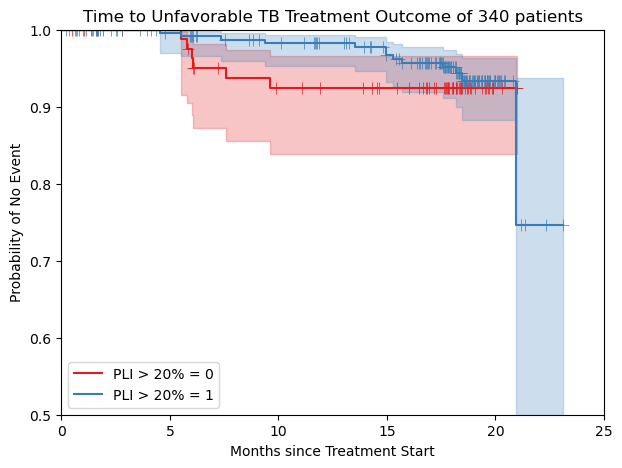

In [628]:
df_KM_plot = df_add_metric_for_model.query("pid in @df_model_processed.pid").merge(df_tx_outcomes[['pid', 'event_type', 'TB_death', 'date', 'event', 'weeks', 'months']])
df_KM_plot['high_lung_involvement'] = (df_KM_plot['predicted_PLI'] > PLI_thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 5))

max_val = int(np.ceil(df_KM_plot.months.max()))

kmf = lifelines.KaplanMeierFitter()

# stratify_col = f'{diversity_metric}_Binary'
# df_KM_plot[stratify_col] = (df_KM_plot[diversity_metric] > thresh).astype(int)
# label_dict = {0: f'# Low-AF Sites ≤ {thresh}', 1: f'# Low-AF Sites > {thresh}'}
# color_dict = dict(zip(np.arange(len(sns.color_palette().as_hex())), sns.color_palette().as_hex()))

stratify_col = 'high_lung_involvement'

color_dict = dict(zip([0, 1], sns.color_palette('Set1', n_colors=2).as_hex()))

kmf_tables = []

if tb_deaths_only:
    df_KM_plot.loc[df_KM_plot['TB_death']==0, 'event'] = 0

for group in np.sort(df_KM_plot[stratify_col].unique()):
    
    df_single_group = df_KM_plot.query(f"{stratify_col}==@group")
    print(len(df_single_group))

    kmf.fit(df_single_group['months'], event_observed=df_single_group['event'],)# label=group_name)
    
    kmf.plot_survival_function(ax=ax, 
                               show_censors=True, 
                               color=color_dict[group], 
                               censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, 
                               label=f"PLI > 20% = {group}"
                               # label=f"# Sites ≥ {int(group)} = {len(df_single_group)}",
                               # label=f"{group_name} = [{int(value_dict[group][0])}, {int(value_dict[group][1])}]: (N = {len(df_single_group)})"
                               # label=f"[{int(value_dict[group][0])}, {int(value_dict[group][1])}]: N = {len(df_single_group)}"
                              )
    
    # Original event table (indexed by actual event/censor times)
    event_table = kmf.event_table

    # Define integer time points of interest
    integer_times = np.arange(0, max_val + 1)

    # Reindex to integer times
    event_table_int = (
        event_table.reindex(integer_times, method="ffill").fillna(method="bfill")
    )

    # Now you can extract at-risk and censored at integer times
    at_risk_int = event_table_int["at_risk"]
    censored_int = event_table_int["censored"]

    every_other_month = np.linspace(0, max_val, 13)
    
    # event_table_int['Group'] = group_name
    # kmf_tables.append(event_table_int[['Group', 'at_risk', 'censored']].loc[every_other_month])
    
# kmf_tables = pd.concat(kmf_tables, axis=1)

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_KM_plot.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")

plt.xlim(0, max_val + 1)
plt.ylim(0.5, 1)

# logRank_balanced_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=0, weightings="fleming-harrington").p_value
# logRank_early_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=1, q=0, weightings="fleming-harrington").p_value
# logRank_late_pval = lifelines.statistics.multivariate_logrank_test(df_KM_plot['date'], df_KM_plot[stratify_col], df_KM_plot['event'], p=0, q=1, weightings="fleming-harrington").p_value

# print(f"Balanced: p = {np.round(logRank_balanced_pval, 4)}")
# print(f"Early: p = {np.round(logRank_early_pval, 4)}")
# print(f"Late: p = {np.round(logRank_late_pval, 4)}")

# # Set x-axis ticks to show all integers
# ax.set_xticks(range(0, int(df_KM_plot['months'].max()) + 1))

# # plt.legend(title='Percentiles')

# sns.despine()
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_binarized_{thresh}.svg", bbox_inches='tight')
# plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles.svg", bbox_inches='tight')
# # plt.savefig(f"../results/figures/outcomes/KM_estimate_percentiles_for_defense.svg", bbox_inches='tight')